In [ ]:
!pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 49.2 MB/s eta 0:00:00


In [ ]:
import gc
import time
import math

import matplotlib.pyplot as plt
import numpy as np
#import ot
import pandas as pd
import pickle
import torch

from google.colab import files
from numpy.linalg import inv
from scipy.linalg import sqrtm
from scipy.sparse.linalg import LinearOperator, eigs
from scipy.spatial import cKDTree
from scipy.special import logsumexp
from sklearn.datasets import make_circles, make_moons, make_swiss_roll
from tqdm.auto import tqdm
from torchvision import datasets, transforms

# (1) Verifying GS--Jacobi relationship

## (i) Computing $\varrho(G)$ and $\varrho(J)$ for Example 1

In [ ]:
n = 10000
m = 2
a = 0.7
s = np.where(np.arange(n) % 2 == 0, 1.0, -1.0)
a2 = a**2
d = 1.0 - (1.0 + a2) / n

one = np.ones(n)
A = np.eye(n) - (np.outer(one, one) + a**2 * np.outer(s, s)) / n

D = np.diag(np.diag(A))
L = np.tril(A, k=-1)
U = np.triu(A, k=1)

In [ ]:
#Basic Gauss-Seidel, for small scale matrices only
'''
G = -np.linalg.solve(D + L, U)

eigenvalues = eigvals(G)
eigenvalues = sorted(eigenvalues, key=lambda z: abs(z), reverse=True)

rho_Ghat = abs(eigenvalues[1])
print(f'GS contraction: {rho_Ghat}')
'''

In [ ]:
#Efficient Gauss-Seidel, without constructing the full matrix (with help from AI)
def G_matvec(x):
    x = np.asarray(x)

    # suffix sums:
    # suffix_x[j]  = sum_{l >= j} x_l
    # suffix_sx[j] = sum_{l >= j} s_l x_l
    suffix_x = np.cumsum(x[::-1])[::-1]
    suffix_sx = np.cumsum((s * x)[::-1])[::-1]

    y = np.empty_like(x)

    # running sums involving already-computed y_l, l < j
    prefix_y = 0.0
    prefix_sy = 0.0

    for j in range(n):

        if j + 1 < n:
            upper_x = suffix_x[j + 1]
            upper_sx = suffix_sx[j + 1]
        else:
            upper_x = 0.0
            upper_sx = 0.0

        # -U x contribution
        rhs = (upper_x + a2 * s[j] * upper_sx) / n

        # forward substitution through D + L
        y[j] = (
            rhs
            + (prefix_y + a2 * s[j] * prefix_sy) / n
        ) / d

        prefix_y += y[j]
        prefix_sy += s[j] * y[j]

    return y


# Treat G as a matrix-free linear operator
Gop = LinearOperator(
    shape=(n, n),
    matvec=G_matvec,
    dtype=float
)

# Compute a few eigenvalues of largest magnitude
vals = eigs(
    Gop,
    k=8,
    which="LM",
    tol=1e-11,
    maxiter=10000,
    return_eigenvectors=False
)

# Sort by magnitude
vals = sorted(vals, key=lambda z: abs(z), reverse=True)

for lam in vals:
    print(lam, r"   |λ| =", abs(lam))

(0.9999999999999991+0j)    |λ| = 0.9999999999999991
(0.2752045627285625+0j)    |λ| = 0.2752045627285625
(0.04729318376608593+0.11442260453869944j)    |λ| = 0.12381105629204678
(0.04729318376608593-0.11442260453869944j)    |λ| = 0.12381105629204678
(0.01770893259229843+0.0673615256567581j)    |λ| = 0.06965042305948076
(0.01770893259229843-0.0673615256567581j)    |λ| = 0.06965042305948076
(0.024353438427993528+0.0550531161322192j)    |λ| = 0.06019913254469441
(0.024353438427993528-0.0550531161322192j)    |λ| = 0.06019913254469441


In [ ]:
#Jacobi
lambda_s = 1.0 - (1.0 - a2) / d
lambda_perp = 1.0 - 1.0 / d

rho_Jhat = max(abs(lambda_s), abs(lambda_perp))
print(f'Jacobi contraction: {rho_Jhat}')


Jacobi contraction: 0.4899239986758027


In [ ]:
from scipy.sparse.linalg import eigsh

# Run directly after the Example 1 spectral-radius cells,
# before later experiments overwrite n, s, a2, or d.

def project_Q(x):
    x = np.asarray(x).reshape(-1)
    return x - x.mean()


def GT_matvec(x):
    x = np.asarray(x).reshape(-1)
    t = np.empty_like(x, dtype=np.result_type(x.dtype, float))

    tail = 0.0
    signed_tail = 0.0

    for j in range(n - 1, -1, -1):
        t[j] = (x[j] + (tail + a2 * s[j] * signed_tail) / n) / d
        tail += t[j]
        signed_tail += s[j] * t[j]

    prefix_t = np.cumsum(t) - t
    prefix_st = np.cumsum(s * t) - s * t

    return (prefix_t + a2 * s * prefix_st) / n


def B_matvec(x):
    """B = Q G Q."""
    return project_Q(G_matvec(project_Q(x)))


def BT_matvec(x):
    """B.T = Q G.T Q."""
    return project_Q(GT_matvec(project_Q(x)))


#largest singualar value of B
H = LinearOperator(
    shape=(n, n),
    matvec=lambda x: BT_matvec(B_matvec(x)),
    dtype=np.float64,
)

rng = np.random.default_rng(0)
v0 = project_Q(rng.standard_normal(n))

eigenvalues, eigenvectors = eigsh(H, k=1, which="LA", v0=v0,
                                  tol=1e-11,  maxiter=10_000,)

sigma_squared = float(eigenvalues[0])
sigma_G = np.sqrt(max(0.0, sigma_squared))
margin = rho_Jhat**2 - sigma_squared

v = eigenvectors[:, 0]
residual = np.linalg.norm(H @ v - sigma_squared * v)

x = project_Q(rng.standard_normal(n))
y = project_Q(rng.standard_normal(n))
adjoint_error = abs(np.dot(B_matvec(x), y) - np.dot(x, BT_matvec(y)))

print(f"Jacobi spectral radius:       {rho_Jhat:.10f}")
print(f"GS quotient operator norm:    {sigma_G:.10f}")
print(f"Squared-condition margin:    {margin:.10f}")
print(f"Eigenpair residual:           {residual:.3e}")
print(f"Adjoint check error:          {adjoint_error:.3e}")
print(
    "Numerical sufficient-condition check:",
    "satisfied" if margin > 0 else "not satisfied",
)

## (ii) Testing the effect of $n/m$ on SSS progress relative to GS (Graph 1)

In [ ]:
################################
#          functions           #
################################

#constructing the local linear system
def example1_local_system(n, alpha=1.0, tau=1.0, a=0.7):
    assert n % 2 == 0, "Use even n so that sum_j s_j = 0."

    #beta corresponding to desired a
    beta = (tau / (2 * alpha)) * np.arctanh(a)

    #balance signs
    s = np.concatenate([np.ones(n // 2), -np.ones(n // 2)])

    P = (np.ones((n, n)) + (a ** 2) * np.outer(s, s)) / n
    A = np.eye(n) - P

    return A, P, s, beta

#comparing SSS and GS sweep
def measure_sss_gs_gap_one_sweep(A, seed=0, tol=1e-14):
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    z = rng.standard_normal(n)

    #removing invariant direction
    z = z - z.mean()
    z = z / np.linalg.norm(z)

    residual = A @ z

    gaps = []

    for j in range(n):
        rj = residual[j]
        Ajj = A[j, j]

        #ignore stationary coordinates
        if abs(rj) > tol:
            #SSS local coordinate upate (similar to Eq. (34) in the main text)
            deltaV_sss = (2.0 - Ajj) * (rj ** 2)

            #exact GS update
            deltaV_gs = (rj ** 2) / Ajj

            #compute gap
            gap = 1.0 - deltaV_sss / deltaV_gs
            gaps.append(gap)

        step = -rj
        z[j] += step
        residual += step * A[:, j]

    return np.array(gaps)

In [ ]:
################################
#          experiment          #
################################
m = 2

ratios = np.array([2, 3, 4, 5, 6, 7, 8, 9, 10, 16, 32, 64, 128, 256, 512, 1024])
n_values = m * ratios
n_repeats = 5

mean_gaps = []
std_gaps = []

for n, ratio in tqdm(zip(n_values, ratios), total=len(ratios), desc='Varying n/m'):
    trial_gaps = []

    for seed in tqdm(range(n_repeats), desc=f"n/m = {ratio}", leave=False):
        A, P, s, beta = example1_local_system(n=n, alpha=1.0, tau=1.0, a=0.7)

        gaps = measure_sss_gs_gap_one_sweep(A, seed=seed)

        #average over coordinates during this sweep
        trial_gaps.append(np.mean(gaps))

    mean_gaps.append(np.mean(trial_gaps))
    std_gaps.append(np.std(trial_gaps))

mean_gaps = np.array(mean_gaps)
std_gaps = np.array(std_gaps)

In [ ]:
################################
#          plotting            #
################################

sss_progress = 1.0 - mean_gaps
sss_progress_std = std_gaps
gs_progress = np.ones_like(ratios, dtype=float)

#lemma 3.10 theoretical line
lemma_bound = 1.0 - 1.0 / ratios.astype(float)**2

#theoretical line for example 1
a = 0.7
example1_theory = (1.0- ((1.0 + a**2)**2) / (4.0 * ratios.astype(float)**2))

#plot graph
fig, ax = plt.subplots(figsize=(6.2, 4.5))

ax.plot(ratios, gs_progress, linestyle='--', color='red', linewidth=2,
        label='Exact GS')

ax.plot(ratios, sss_progress, linewidth=2, markersize=6, color='orange',
        label='SSS')

ax.fill_between(ratios, sss_progress - sss_progress_std,
                sss_progress + sss_progress_std,alpha=0.15)

#shade the gap
ax.fill_between(ratios, sss_progress, gs_progress, alpha=0.08)

#Example 1 theoretical line
ax.plot(ratios, example1_theory, linestyle=':', linewidth=2.2, color='blue',
        label='Example 1 theoretical line', zorder=2)

#Lemma 3.10 theoretical line
ax.plot(ratios, lemma_bound, linestyle=':', linewidth=2.2, color='black',
        label=r'Lemma 3.10 lower bound',zorder=2)

ax.set_xscale('log')
ax.set_xlabel(r'Support imbalance $n/m$')
ax.set_ylabel(
    r'SSS relative progress: '
    r'$\Delta V_{\mathrm{SSS}} / \Delta V_{\mathrm{GS}}$'
)

ax.set_title( "SSS approaches exact Gauss–Seidel as $n/m$ grows")

ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Extra Experiments (for Appendix)

In [ ]:
def solve_entropic_ot_log(C, mu, nu, tau, tol=1e-10, max_iter=10_000):

    log_mu = np.log(mu)
    log_nu = np.log(nu)

    log_u = np.zeros_like(mu)
    log_v = np.zeros_like(nu)

    K_log = -C / tau

    for it in range(max_iter):

        old_log_u = log_u.copy()
        old_log_v = log_v.copy()

        #row scaling
        log_u = (log_mu - logsumexp(K_log + log_v[None, :], axis=1))

        #column scaling
        log_v = (log_nu- logsumexp( K_log + log_u[:, None], axis=0))

        if it % 20 == 0:
            change = max(np.max(np.abs(log_u - old_log_u)), np.max(np.abs(log_v - old_log_v)))

            if change < tol:
                break

    log_pi = (log_u[:, None] + K_log + log_v[None, :])
    pi = np.exp(log_pi)

    return pi


def make_clustered_problem_bank(m=20, max_ratio=100, radius=2.0, sigma=0.03,
                                seed=123):
    """
    Create source points on a circle and a bank of target points
    tightly clustered around each source.

    Y_bank[i, k] is the k-th target associated with source i.
    """

    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # Source points: equally spaced around a circle
    # --------------------------------------------------
    angles = 2 * np.pi * np.arange(m) / m

    X = radius * np.column_stack([np.cos(angles), np.sin(angles)])

    # --------------------------------------------------
    # Target bank:
    # max_ratio targets around each source point
    # --------------------------------------------------
    noise = sigma * rng.standard_normal(size=(m, max_ratio, 2))
    Y_bank = X[:, None, :] + noise

    return X, Y_bank



def get_problem_at_ratio(X, Y_bank, ratio):
    """
    Take 'ratio' target points from every source cluster.

    Therefore:
        n = m * ratio
        n/m = ratio
    """

    m = X.shape[0]

    Y = Y_bank[:, :ratio, :].reshape(-1, 2)

    n = Y.shape[0]

    mu = np.ones(m) / m
    nu = np.ones(n) / n

    #squared Euclidean cost
    C = np.sum((X[:, None, :] - Y[None, :, :])**2,axis=2)

    return Y, C, mu, nu


def compute_sss_relative_progress(pi, mu, nu):
    """
    For every target coordinate j, compute

        DeltaV_SSS_j / DeltaV_GS_j
        = 1 - P_jj^2.

    Returns one value per target coordinate.
    """

    # P_jj = sum_i pi_ij^2 / (mu_i * nu_j)
    P_diag = np.sum(pi**2 / mu[:, None], axis=0) / nu

    relative_progress = 1.0 - P_diag**2

    return relative_progress, P_diag



# ============================================================
# Experimental setup
# ============================================================


m = 5

ratios = np.array([
    2,
    3,
    5,
    10,
    20,
    50,
    100
])

tau_values = [
    0.03,   #sharp / nearly deterministic coupling
    0.10,   #intermediate
    0.30    #more diffuse coupling
]

#build one
X, Y_bank = make_clustered_problem_bank(
    m=m,
    max_ratio=np.max(ratios),
    radius=2.0,
    sigma=0.03,
    seed=123
)

'''
results = {}

for tau in tqdm(tau_values, desc="Entropy settings"):

    mean_progress = []
    min_progress = []
    max_progress = []

    for ratio in tqdm(ratios, desc=f"tau = {tau}",leave=False):

        Y, C, mu, nu = get_problem_at_ratio(X, Y_bank, ratio)

        pi = solve_entropic_ot_log(C=C, mu=mu, nu=nu, tau=tau)

        relative_progress, P_diag = (compute_sss_relative_progress(pi, mu, nu))

        mean_progress.append(np.mean(relative_progress))
        min_progress.append(np.min(relative_progress))
        max_progress.append(np.max(relative_progress))

    results[tau] = {'mean': np.array(mean_progress),
                    'min': np.array(min_progress),
                    'max': np.array(max_progress)}


gs_reference = np.ones_like(ratios, dtype=float)

lemma_bound = (1.0 - 1.0 / ratios.astype(float)**2)
'''

fig, ax = plt.subplots(figsize=(7.0, 4.8))

# ============================================================
# SSS curves for different problem settings
# ============================================================

for tau in tau_values:

    mean = results[tau]['mean']
    lower = results[tau]['min']
    upper = results[tau]['max']

    line, = ax.plot(ratios, mean, marker='o', markersize=6, linewidth=2,
                    label=rf"SSS, $\tau={tau}$")

    #range across target j
    ax.fill_between(ratios, lower, upper, alpha=0.10, color=line.get_color())


# ============================================================
# Exact GS
# ============================================================

ax.axhline(y=1.0,linestyle="--", linewidth=2, color='red', label="Exact GS")


# ============================================================
# Lemma 3.10 lower bound
# ============================================================

ax.plot(ratios, lemma_bound, linestyle=':', linewidth=2.2, color='black',
        label=r"Lemma 3.10: $1-(m/n)^2$")


# ============================================================
# Axes
# ============================================================

ax.set_xscale('log')
ax.set_xlabel(r"Support imbalance $n/m$", fontsize=16)

ax.set_ylabel(r"Progress relative to "
r"$\Delta V_{\mathrm{SSS}}/"
r"\Delta V_{\mathrm{GS}}$"
, fontsize=16)

ax.set_title("SSS approaches exact GS as support imbalance increases", fontsize=18)
ax.set_ylim(0.72, 1.005)
ax.grid(True, which='both', alpha=0.25)
ax.legend(frameon=False, fontsize=15)

plt.tight_layout()
plt.show()


filename = 'gs_app_ratio.pdf'
fig.savefig(filename, format='pdf', bbox_inches='tight')
files.download(filename)


## (iii) Empirical verification of sufficient condition (Graph 2)

In [ ]:
################################
#          functions           #
################################

def make_example1(n=int(1e^5),alpha=1.0, tau=1.0, a=0.7):
    assert n % 2 == 0

    beta = (tau / (2 * alpha)) * np.arctanh(a)
    s = np.tile(np.array([1.0, -1.0]), n // 2)

    base = alpha**2 + beta**2
    C = np.vstack([base - 2 * alpha * beta * s, base + 2 * alpha * beta * s])
    K = np.exp(-C / tau)

    mu = np.array([0.5, 0.5])
    nu = np.full(n, 1.0 / n)

    return {'n': n, 'alpha': alpha, 'beta': beta, 'tau': tau, 'a': a, 's': s,
            'C': C, 'K': K, 'mu': mu, 'nu': nu}

#compute Az without constructing n x n matrix
def apply_A(z, s, a):
    n = len(z)
    return (z - np.sum(z) / n - a**2 * s * np.dot(s, z) / n)


def local_energy(z, s, a):
    n = len(z)
    V = (np.dot(z, z) - np.sum(z)**2 / n - a**2 * np.dot(s, z)**2 / n)
    return max(V, 0.0)

########################################################################
#exact Jacobi
def jacobi_one_iteration(z, s, a):
    n = len(z)
    d = 1.0 - (1.0 + a**2) / n
    residual = apply_A(z, s, a)
    z_new = z - residual / d
    return z_new

#exact GS
def gs_one_sweep(z, s, a):
    z = z.copy()
    n = len(z)
    d = 1.0 - (1.0 + a**2) / n

    #running quantities
    sum_z = np.sum(z)
    s_dot_z = np.dot(s, z)

    for j in range(n):
        residual_j = (z[j] - sum_z / n - a**2 * s[j] * s_dot_z / n)
        delta = -residual_j / d
        z[j] += delta

        #update running quantities
        sum_z += delta
        s_dot_z += s[j] * delta

    return z

#Sinkhorn one iteration
def sinkhorn_full_iteration(g, K, mu, nu):
    f = -np.log(K @ (nu * np.exp(g)))
    g_new = -np.log(K.T @ (mu * np.exp(f)))
    g_new -= np.mean(g_new) #subtracting constant does not change coupling
    return g_new

#SSS one iteration
def sss_cyclic_epoch(g, K, mu, nu):
    g = g.copy()
    n = len(g)

    exp_g = np.exp(g)
    s_x = K @ (nu * exp_g)
    f = -np.log(s_x)

    for j in range(n):
        new_g_j = -np.log(np.dot(K[:, j], mu * np.exp(f)))
        old_exp = exp_g[j]
        new_exp = np.exp(new_g_j)

        g[j] = new_g_j
        exp_g[j] = new_exp

        s_x += (nu[j] * K[:, j] * (new_exp - old_exp))
        f = -np.log(s_x)

    g -= np.mean(g)

    return g

In [ ]:
################################
#          experiment          #
################################

#constructing problem
problem = make_example1(n=10_000, alpha=1.0, tau=1.0, a=0.7)

n = problem["n"]
rng = np.random.default_rng(0)

delta = 1e-2
noise_level = 0.20

h = (s + noise_level * rng.standard_normal(n))

#remove invariant direction and normalize
h -= np.mean(h)
h /= np.sqrt(np.mean(h**2))

g0 = delta * h
z0 = g0 / np.sqrt(n)
###############################################################################

n_epochs = 10

g_sss = g0.copy()
g_sink = g0.copy()

z_gs = z0.copy()
z_jac = z0.copy()

V0 = local_energy(z0, s, a)

curve_sss = [1.0]
curve_gs = [1.0]
curve_sink = [1.0]
curve_jac = [1.0]


for epoch in tqdm(range(n_epochs), desc='Running Exp'):
    #OT methods
    g_sss = sss_cyclic_epoch(g_sss, K, mu, nu)
    g_sink = sinkhorn_full_iteration(g_sink, K, mu, nu)

    #exact methods
    z_gs = gs_one_sweep(z_gs, s, a)
    z_jac = jacobi_one_iteration(z_jac, s, a)

    #converting non-linear g to local z
    z_sss = g_sss / np.sqrt(n)
    z_sink = g_sink / np.sqrt(n)

    #normalized energy
    curve_sss.append(local_energy(z_sss, s, a) / V0)
    curve_sink.append(local_energy(z_sink, s, a) / V0)
    curve_gs.append(local_energy(z_gs, s, a) / V0)
    curve_jac.append(local_energy(z_jac, s, a) / V0)


In [ ]:
################################
#          plotting            #
################################
epochs = np.arange(n_epochs + 1)

fig, ax = plt.subplots(figsize=(7.0, 4.8))

#GS family
ax.semilogy(epochs, curve_sss, marker='o', linewidth=2.2, label='SSS',
            color='orange')
ax.semilogy(epochs, curve_gs, linestyle='--', linewidth=2.2, label='Exact GS',
            color='red')

# Jacobi family
ax.semilogy(epochs, curve_sink, marker='s', linewidth=2.2, label='Sinkhorn',
            color='magenta')
ax.semilogy(epochs, curve_jac,linestyle='--', linewidth=2.2, label='Exact Jacobi',
            color='blue')

ax.set_xlabel('Number of sweeps')
ax.set_ylabel(r'Normalized local error $V_k/V_0$')
ax.set_title("Local GS–Jacobi interpretation of SSS and Sinkhorn")

ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
epochs = np.arange(n_epochs + 1)

fig, ax = plt.subplots(figsize=(7.2, 5.0))


def plot_with_sd(
    x,
    mean,
    std,
    label,
    color,
    linestyle="-",
    marker=None
):
    ax.semilogy(
        x,
        mean,
        color=color,
        linestyle=linestyle,
        marker=marker,
        linewidth=2.2,
        markersize=5,
        label=label
    )

    # Necessary because log-axis cannot display <= 0
    lower = np.maximum(
        mean - std,
        1e-16
    )

    upper = mean + std

    ax.fill_between(
        x,
        lower,
        upper,
        color=color,
        alpha=0.12
    )


# SSS / GS family
plot_with_sd(
    epochs,
    means["SSS"],
    stds["SSS"],
    label="SSS",
    color="tab:blue",
    linestyle="-",
    marker="o"
)

plot_with_sd(
    epochs,
    means["GS"],
    stds["GS"],
    label="Exact GS",
    color="tab:blue",
    linestyle="--"
)

# Sinkhorn / Jacobi family
plot_with_sd(
    epochs,
    means["Sinkhorn"],
    stds["Sinkhorn"],
    label="Sinkhorn",
    color="tab:orange",
    linestyle="-",
    marker="s"
)

plot_with_sd(
    epochs,
    means["Jacobi"],
    stds["Jacobi"],
    label="Exact Jacobi",
    color="tab:orange",
    linestyle="--"
)


ax.set_xlabel("Full sweeps / iterations")

ax.set_ylabel(
    r"Normalized local error $V_k/V_0$"
)

ax.set_title(
    "SSS tracks Gauss–Seidel while Sinkhorn tracks Jacobi"
)

ax.grid(
    True,
    which="both",
    alpha=0.25
)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## (iv) Plotting graphs for paper

In [ ]:
################################
#      combined plotting       #
################################

fig, axes = plt.subplots(
    1, 2,
    figsize=(13.5, 4.8)
)

# ============================================================
# Left plot: Graph 1
# ============================================================

ax = axes[0]

sss_progress = 1.0 - mean_gaps
sss_progress_std = std_gaps
gs_progress = np.ones_like(ratios, dtype=float)

#lemma 3.10 theoretical line
lemma_bound = (
    1.0
    - 1.0 / ratios.astype(float)**2
)

#example 1 theoretical line
a = 0.7

example1_theory = (
    1.0
    - ((1.0 + a**2)**2)
      / (4.0 * ratios.astype(float)**2)
)

#exact GS
ax.plot(
    ratios,
    gs_progress,
    linestyle='--',
    color='red',
    linewidth=2,
    label='Exact GS'
)

#SSS
ax.plot(
    ratios,
    sss_progress,
    marker='o',
    linewidth=2,
    markersize=6,
    color='orange',
    label='SSS cyclic'
)

#sd
ax.fill_between(
    ratios,
    sss_progress - sss_progress_std,
    sss_progress + sss_progress_std,
    color='orange',
    alpha=0.15
)

#shade SSS-GS gap
ax.fill_between(
    ratios,
    sss_progress,
    gs_progress,
    color='orange',
    alpha=0.08
)

#example 1
ax.plot(
    ratios,
    example1_theory,
    linestyle=':',
    linewidth=2.2,
    color='blue',
    label='Example 1 theoretical bound',
    zorder=2
)

#lemma 3.10
ax.plot(
    ratios,
    lemma_bound,
    linestyle=':',
    linewidth=2.2,
    color='black',
    label='Lemma 3.10 lower bound',
    zorder=2
)

ax.set_xscale('log')
ax.set_xlabel(r'Support imbalance $n/m$', fontsize=18)
ax.set_ylabel(
    r'$\Delta V_{\mathrm{SSS}}/\Delta V_{\mathrm{GS}}$',
    fontsize=18
)
ax.set_title('(a) Progress gap for SSS and exact GS', fontsize=20)

ax.legend(frameon=False, fontsize=16)

ax.tick_params( axis='both', labelsize=16)

ax.grid(True,which='both',alpha=0.25)


# ============================================================
# Right plot: Graph 2
# ============================================================

ax = axes[1]

epochs = np.arange(n_epochs + 1)

# GS family
ax.semilogy(
    epochs,
    curve_sss,
    marker='o',
    linewidth=2.2,
    label='SSS cyclic',
    color='orange'
)

ax.semilogy(
    epochs,
    curve_gs,
    linestyle='--',
    linewidth=2.2,
    label='Exact GS',
    color='red'
)

# Jacobi family
ax.semilogy(
    epochs,
    curve_sink,
    marker='s',
    linewidth=2.2,
    label='Sinkhorn',
    color='magenta'
)

ax.semilogy(
    epochs,
    curve_jac,
    linestyle='--',
    linewidth=2.2,
    label='Exact Jacobi',
    color='blue'
)

ax.set_xlabel('Number of sweeps', fontsize=18)
ax.set_ylabel(r'$V_k/V_1$', fontsize=18)

ax.set_title('(b) GS-Jacobi local convergence', fontsize=20)

handles, labels = plt.gca().get_legend_handles_labels()
order = [1, 0, 3, 2]
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          frameon=False, fontsize=16)

ax.tick_params(axis='both', labelsize=16)

ax.grid(True,which='both', alpha=0.25)

# ============================================================
# Overall formatting
# ============================================================

plt.tight_layout()
#fig.subplots_adjust(wspace=0.35)
plt.show()

# Save as PDF
filename = "GS_SSS_comparison.pdf"

fig.savefig(
    filename,
    format='pdf',
    bbox_inches='tight'
)

In [ ]:
files.download(filename)

# (2) Comparisons with Sinkhorn baselines

## (a) 2D EOT data

### Functions

#### Data

In [ ]:
#generate 2d data
def generate_gaussian_gaussian(m, n, rng):
    source = rng.normal(loc=np.array([2.0, 2.0]), scale=0.5, size=(m, 2))
    target = rng.normal(loc=np.array([-2.0, -2.0]), scale=1.0, size=(n, 2))
    return source, target

def generate_gaussian_swiss_roll(m, n, rng):
    source = rng.normal(loc=0.0, scale=5.0, size=(m, 2))

    #target
    t = np.linspace(0, 4 * np.pi, n)
    t += rng.normal(0.0, 0.1, size=n)

    x = t * np.cos(t)
    x += rng.normal(0.0, 0.5, size=n)

    y = t * np.sin(t)
    y += rng.normal(0.0, 0.5, size=n)

    target = np.column_stack((x, y))

    return source, target

def generate_circles_checkerboard(m, n, rng):
    random_state = int(rng.integers(0, 2**31 - 1))

    #source
    source = make_circles(n_samples=m, factor=0.5, noise=0.08,
                          random_state=random_state)[0]
    source = source.astype(np.float64) * 3.0

    #target
    x1 = rng.random(n) * 4 - 2
    x2_ = (rng.random(n) - rng.integers(0, 2, size=n) * 2)
    x2 = x2_ + (np.floor(x1) % 2)
    target = (np.stack([x1, x2], axis=1)/ 0.45)

    return source, target

def generate_moons_gaussian_grid(m, n, rng):
    seed_source = int(rng.integers(0, 2**31 - 1))

    source, _ = make_moons(n_samples=m, noise=0.08, random_state=seed_source)
    source = source.astype(np.float64) * 3.0

    centers = np.array([
        [-2.5, -2.5],
        [ 0.0, -2.5],
        [ 2.5, -2.5],

        [-2.5,  0.0],
        [ 0.0,  0.0],
        [ 2.5,  0.0],

        [-2.5,  2.5],
        [ 0.0,  2.5],
        [ 2.5,  2.5],
    ])
    labels = rng.integers(0, len(centers), size=n)
    target = np.empty((n, 2))

    for k, center in enumerate(centers):
        mask = labels == k
        target[mask] = rng.normal(loc=center, scale=0.25, size=(mask.sum(), 2))

    return source, target

#wrapper function
def generate_2d_pairs(dataset, num_pairs, m, n, seed=1337):
    rng = np.random.default_rng(seed)

    generators = {'gaussian_gaussian': generate_gaussian_gaussian,
                  'gaussian_swiss_roll': generate_gaussian_swiss_roll,
                  'circles_checkerboard': generate_circles_checkerboard,
                  'moons_gaussian_grid':generate_moons_gaussian_grid}

    if dataset not in generators:
        raise ValueError(
            f"Unknown dataset '{dataset}'. "
            f"Choose from {list(generators.keys())}."
        )

    generator = generators[dataset]

    sources = []
    targets = []

    for _ in range(num_pairs):
        source, target = generator(m, n, rng)
        sources.append(source)
        targets.append(target)

    return (np.stack(sources), np.stack(targets))

#construct EOT problem from two point clouds
def prepare_ot_problem(source, target):
    m = source.shape[0]
    n = target.shape[0]

    #uniform marginals
    a = np.ones(m, dtype=np.float64) / m
    b = np.ones(n, dtype=np.float64) / n

    #squared Euclidean cost
    C = ot.dist(source, target, metric='sqeuclidean')
    C_max = C.max()

    if C_max > 0:
        C = C / C_max

    return a, b, C

#plot 2d example
def plot_2d_pair(source, target, title=None):
    plt.figure(figsize=(7, 7))

    plt.scatter(source[:, 0], source[:, 1], s=10, alpha=0.6, label="Source")
    plt.scatter(target[:, 0], target[:, 1], s=10, alpha=0.6, label="Target")

    if title is not None:
        plt.title(title)

    plt.axis("equal")
    plt.legend()
    plt.show()

#### Solvers

In [ ]:
#############################
#         SINKHORN          #
#############################
#sequential Sinkhorn
def sinkhorn_sequential(a, b, C, reg, max_updates=int(1e8), tol=None,
                        budget=None, check_every=250):

    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    C = np.asarray(C, dtype=np.float64)

    m, n = C.shape
    K = np.exp(-C / reg)

    #initialization
    v = b.copy()
    u = a / (K @ v)

    cost = 0
    error_history = []
    cost_history = []

    #initial_error
    err = marginal_error(a, b, K, u, v)
    error_history.append(float(err))
    cost_history.append(cost)

    cycle_length = n + m
    for update in range(max_updates):
        position = update % cycle_length

        #column update
        if position < n:
            j = position
            update_cost = m

            #check budget
            if (budget is not None and cost + update_cost > budget):
                break

            v[j] = b[j] / np.dot(K[:, j], u)

            cost += update_cost

        #row update
        else:
            i = position - n
            update_cost = n

            #check budget
            if (budget is not None and cost + update_cost > budget):
                break

            u[i] = a[i] / np.dot(K[i, :], v)

            cost += update_cost

        #error handling
        if (update + 1) % check_every == 0:
            err = float(marginal_error(a, b, K, u, v))

            error_history.append(err)
            cost_history.append(cost)

            if tol is not None and err <= tol:
                break

    if cost_history[-1] != cost:
        err = float(marginal_error(a, b, K, u, v))

        error_history.append(err)
        cost_history.append(cost)

    return u, v, error_history, cost_history


#############################
#             SSS           #
#############################

#vanilla SSS
def sss(a, b, C, reg, gamma=1.0, max_iter=int(1e8), tol=1e-9, sampling='random',
        check_every=250, budget=None, seed=None):

    rng = np.random.default_rng(seed)

    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    C = np.asarray(C, dtype=np.float64)

    m, n = C.shape
    K = np.exp(-C / reg)

    #initialization
    v = b.copy()
    Kv = K @ v
    u = a / Kv
    cost = 0
    error_history = []
    cost_history = []

    #initial error
    error = sss_marginal_error(a, b, K, u, v, Kv)
    error_history.append(float(error))
    cost_history.append(cost)

    #initialize permutation
    permutation = None

    if sampling == 'cyclic':
        permutation = rng.permutation(n)
    elif sampling not in ('random', 'shuffle'):
        raise ValueError("Sampling must be 'random', 'shuffle', or 'cyclic'")

    for iteration in range(max_iter):

        #check budget
        if budget is not None and cost + m > budget:
            break

        #handle coord selection
        if sampling == 'random':
            j = rng.integers(n)
        elif sampling == 'shuffle':
            if iteration % n == 0:
                permutation = rng.permutation(n)
            j = permutation[iteration % n]
        elif sampling == 'cyclic':
            j = permutation[iteration % n]

        #target marginal at coord j
        marginal_j = v[j] * np.dot(K[:, j], u)

        #SSS coordinate update
        old_v_j = v[j]
        v[j] = old_v_j * (b[j] / marginal_j) ** (gamma * n)
        Kv += K[:, j] * (v[j] - old_v_j)

        #source normalization
        u = a / Kv

        cost += m

        #track error
        if (iteration + 1) % check_every == 0:
            error = sss_marginal_error(a, b, K, u, v, Kv)
            error_history.append(float(error))
            cost_history.append(cost)

            if error <= tol:
                break

    if cost_history[-1] != cost:
        error = sss_marginal_error(a, b, K, u, v, Kv)
        error_history.append(float(error))
        cost_history.append(cost)

    return u, v, error_history, cost_history


#############################
#          Greenkhorn       #
#############################
def greenkhorn(a, b, C, reg, max_iter=int(1e8), tol=1e-9, check_every=250,
               budget=None):

    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    C = np.asarray(C, dtype=np.float64)

    m, n = C.shape
    K = np.exp(-C / reg)

    #initialization
    v = b.copy()
    u = a / (K @ v)

    #maringal violations
    row_violation = u * (K @ v) - a
    col_violation = v * (K.T @ u) - b

    error = marginal_error(a, b, K, u, v)
    error_history = [float(error)]
    cost_history = [0]
    cost = 0

    for iteration in range(max_iter):

        #finding coord to update
        i = np.argmax(np.abs(row_violation))
        j = np.argmax(np.abs(col_violation))
        row_max = np.abs(row_violation[i])
        col_max = np.abs(col_violation[j])

        #row update
        if row_max > col_max:
            update_cost = n

            if (budget is not None and cost + update_cost > budget):
                break

            old_u_i = u[i]
            new_u_i = a[i] / np.dot(K[i, :], v)

            #update violations
            delta_u = new_u_i - old_u_i
            row_violation[i] = (new_u_i * np.dot(K[i, :], v) - a[i])
            col_violation += (delta_u * K[i, :] * v)
            u[i] = new_u_i

            cost += update_cost

        #column upate
        else:
            update_cost = m

            if (budget is not None and cost + update_cost > budget):
                break

            old_v_j = v[j]
            new_v_j = b[j] / np.dot(K[:, j],u)

            #update violations
            delta_v = new_v_j - old_v_j
            row_violation += (delta_v * K[:, j] * u)
            col_violation[j] = (new_v_j * np.dot(K[:, j], u) - b[j])
            v[j] = new_v_j

            cost += update_cost

        #track error
        if (iteration + 1) % check_every == 0:
            error = marginal_error(a, b, K, u, v)
            error_history.append(float(error))
            cost_history.append(cost)

            if error <= tol:
                break

    #record final entry
    if cost_history[-1] != cost:
        error = marginal_error(a, b, K, u, v)
        error_history.append(float(error))
        cost_history.append(cost)

    return u, v, error_history, cost_history




#############################
#   Stochastic Sinkhorn     #
#############################
def stochastic_sinkhorn(a, b, C, reg, max_iter=int(1e8), tol=1e-9,
                        check_every=250, budget=None, seed=None):

    ng = np.random.default_rng(seed)

    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    C = np.asarray(C, dtype=np.float64)

    m, n = C.shape
    K = np.exp(-C / reg)

    #initialization
    v = b.copy()
    u = a / (K @ v)

    error = marginal_error(a, b, K, u, v)
    error_history = [float(error)]
    cost_history = [0]
    cost = 0

    for iteration in range(max_iter):
        index = rng.integers(m + n)

        #row update
        if index < m:
            i = index
            update_cost = n

            if (budget is not None and cost + update_cost > budget):
                break

            u[i] = a[i] / np.dot(K[i, :], v)
            cost += update_cost

        #column update
        else:
            j = index - m
            update_cost = m

            if (budget is not None and cost + update_cost > budget):
                break

            v[j] = b[j] / np.dot(K[:, j], u)
            cost += update_cost

        #track error
        if (iteration + 1) % check_every == 0:

            error = marginal_error(a, b, K, u, v)

            error_history.append(float(error))
            cost_history.append(cost)

            if error <= tol:
                break

    #record final entry
    if cost_history[-1] != cost:

        error = marginal_error(a, b, K, u, v)

        error_history.append(float(error))
        cost_history.append(cost)

    return u, v, error_history, cost_history

#### Helper functions

In [ ]:
#E_k convergence criteria
def marginal_error(a, b, K, u, v):
    row_marginal = u * (K @ v)
    col_marginal = v * (K.T @ u)
    return (np.sum(np.abs(row_marginal - a)) + np.sum(np.abs(col_marginal - b)))

def sss_marginal_error(a, b, K, u, v, Kv):
    row_marginal = u * Kv
    col_marginal = v * (K.T @ u)
    return (np.sum(np.abs(row_marginal - a)) + np.sum(np.abs(col_marginal - b)))


#trainer function
def run_solvers_2d(source, target, reg=1e-2, gamma0=1.0, budget=int(1e7),
                   tol=1e-9, max_iter=10_000_000, check_every=250, seed=1337):

    a, b, C = prepare_ot_problem(source, target)
    m = len(a)
    n = len(b)

    gamma = gamma0 / n
    results = {}

    #Sinkhorn
    u, v, error, cost = sinkhorn_sequential(a, b, C, reg, max_updates=max_iter,
                                            tol=tol, budget=budget,
                                            check_every=check_every)
    results["sinkhorn"] = {'u': u, 'v': v, 'error': error, 'cost': cost}

    #SSS uniform sampling
    u, v, error, cost = sss(a, b, C, reg, gamma=gamma, sampling='random',
                            max_iter=max_iter, tol=tol, check_every=check_every,
                            budget=budget, seed=seed)
    results['sss'] = {'u': u, 'v': v, 'error': error, 'cost': cost,}

    #SSS cyclic
    u, v, error, cost = sss(a, b, C, reg, gamma=gamma, sampling="cyclic",
                            max_iter=max_iter, tol=tol, check_every=check_every,
                            budget=budget, seed=seed)
    results['sss_cyclic'] = {'u': u, 'v': v, 'error': error,'cost': cost,}

    #Greenkhorn
    u, v, error, cost = greenkhorn(a, b, C, reg, max_iter=max_iter, tol=tol,
                                    check_every=check_every, budget=budget)
    results['greenkhorn'] = {'u': u, 'v': v, 'error': error, 'cost': cost}

    #Stochastic-Sinkhorn
    u, v, error, cost = stochastic_sinkhorn(a, b, C, reg, max_iter=max_iter,
                                            tol=tol, check_every=check_every,
                                            budget=budget, seed=seed)
    results['stochastic_sinkhorn'] = {'u': u, 'v': v, 'error': error, 'cost': cost}

    return results


#run experiment function
def run_2d_experiment(dataset, m, n, num_pairs=20, reg=1e-2, gamma0=1.0,
                      budget=int(1e7), tol=1e-9, max_iter=10_000_000,
                      check_every=250, seed=1337):

    sources, targets = generate_2d_pairs(dataset=dataset, num_pairs=num_pairs,
                                         m=m, n=n, seed=seed)

    experiment_results = {'dataset': dataset, 'm': m, 'n': n, 'reg': reg,
                          'gamma0': gamma0, 'budget': budget, 'pairs': {}}

    for pair_idx in tqdm(range(num_pairs), desc=f'Running {dataset}'):

        print(
            f"{dataset}: "
            f"pair {pair_idx + 1}/{num_pairs}"
        )

        source = sources[pair_idx]
        target = targets[pair_idx]

        solver_results = run_solvers_2d(source=source,target=target,reg=reg,
                                        gamma0=gamma0,budget=budget, tol=tol,
                                        max_iter=max_iter, check_every=check_every,
                                        seed=seed + pair_idx)

        experiment_results['pairs'][pair_idx] = {'source': source, 'target': target,
                                                 'solvers': solver_results}

    return experiment_results


#plotting single 2D example
def plot_convergence(results, pair_idx=0, title=None):

    solver_results = (results["pairs"][pair_idx]['solvers'])

    labels = {'sinkhorn': 'Sinkhorn', 'sss': 'SSS', 'sss_cyclic': 'SSS cyclic',
              'greenkhorn': 'Greenkhorn','stochastic_sinkhorn': 'Stochastic Sinkhorn'}

    plt.figure(figsize=(8, 5))

    for name, result in solver_results.items():
        cost = np.asarray(result['cost'])
        error = np.asarray(result['error'])

        plt.plot(cost, error, label=labels[name], linewidth=2)

    plt.yscale('log')
    plt.xlabel('Computational cost')
    plt.ylabel('Marginal error')

    if title is not None:
        plt.title(title)

    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


#plotting all graphs
def plot_three_datasets(all_results, pair_idx=0):
    '''
    datasets = [
        ('gaussian_gaussian', 'Gaussian → Gaussian'),
        ('gaussian_swiss_roll', 'Gaussian → Swiss roll'),
        ('circles_checkerboard', 'Circles → Checkerboard'),
    ]
    '''

    datasets = [
        ('moons_gaussian_grid', '(a) Moons → Gaussian grid'),
        ('gaussian_swiss_roll', '(b) Gaussian → Swiss roll'),
        ('circles_checkerboard', '(c) Circles → Checkerboard'),
    ]

    solver_labels = {
        'sss_cyclic': 'SSS cyclic',
        'sss': 'SSS',
        'sinkhorn': 'Sinkhorn',
        'stochastic_sinkhorn': 'Stochastic Sinkhorn',
        'greenkhorn': 'Greenkhorn'
    }

    colors = {
        'sinkhorn': 'magenta',
        'sss': 'green',
        'sss_cyclic': 'orange',
        'greenkhorn': 'red',
        'stochastic_sinkhorn': 'blue',
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True,)

    for ax, (dataset, title) in zip(axes, datasets):
        solver_results = (all_results[dataset]['pairs'][pair_idx]['solvers'])

        for solver_name, label in solver_labels.items():

            result = solver_results[solver_name]

            cost = np.asarray(result['cost'])
            error = np.asarray(result['error'])

            ax.plot(cost, error, label=label, color=colors[solver_name],
                    linewidth=2)

        ax.set_title(title, fontsize=24)
        ax.set_xlabel('Computational cost', fontsize=22)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.tick_params( axis='both', labelsize=20)
        ax.xaxis.get_offset_text().set_fontsize(18)

    #shared y-axis and legend
    axes[0].set_ylabel('Marginal error', fontsize=22)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=5,
               bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=20)

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    plt.show()

    filename = 'synthetic_comparison.pdf'
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    files.download(filename)

### Experiment

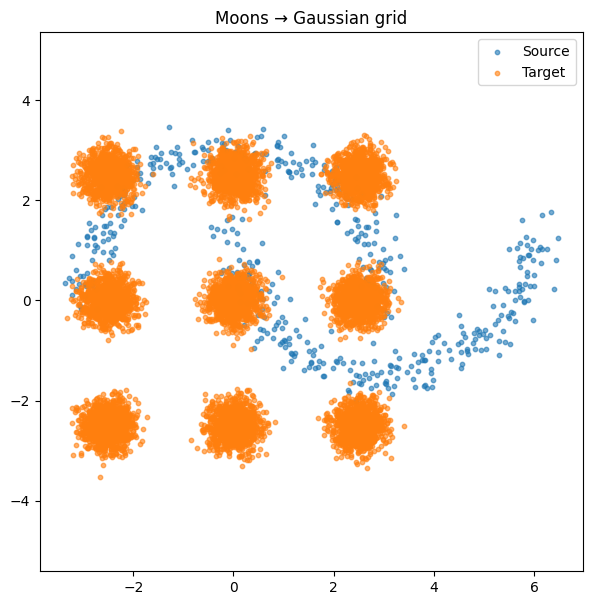

In [ ]:
#sanity check
sources, targets = generate_2d_pairs(dataset='moons_gaussian_grid', num_pairs=20,
                                     m=500, n=10000, seed=1337)

plot_2d_pair( sources[0], targets[0], title='Moons → Gaussian grid')

In [ ]:
datasets = {'moons_gaussian_grid': 'Moons → Gaussian grid',
            'gaussian_swiss_roll': 'Gaussian → Swiss roll',
            'circles_checkerboard': 'Circles → Checkerboard'}

m = 50
n = 10000

num_pairs = 1
reg = 1e-2
gamma0 = 1.0
budget = int(1e8)
tol = 1e-9
check_every = 250
seed = 1337

all_results = {}

for dataset, dataset_title in datasets.items():

    print('=' * 60)
    print(dataset_title)
    print(f'm = {m}, n = {n}')
    print('=' * 60)

    results = run_2d_experiment(
        dataset=dataset,
        m=m,
        n=n,
        num_pairs=num_pairs,
        reg=reg,
        gamma0=gamma0,
        budget=budget,
        tol=tol,
        check_every=check_every,
        seed=seed,
    )

    all_results[dataset] = results

In [ ]:
'''
with open('all_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)
'''

with open('all_results.pkl', 'rb') as f:
    all_results = pickle.load(f)

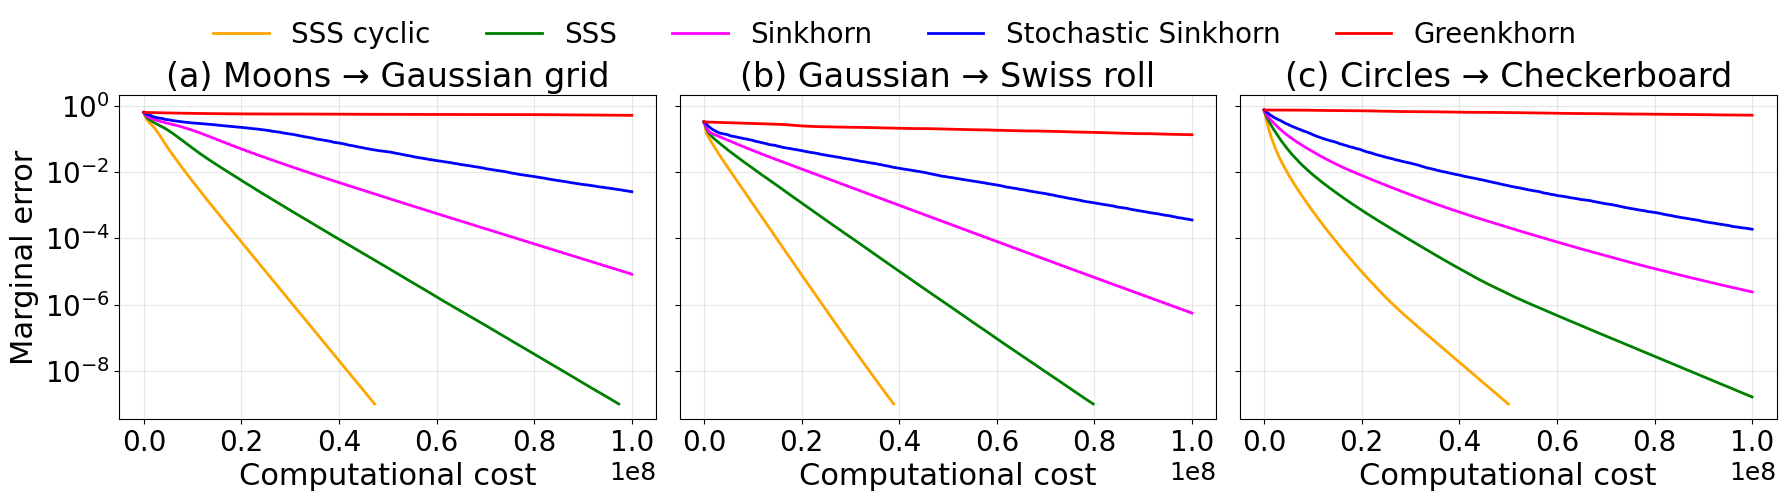

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plot_three_datasets(all_results, pair_idx=0)

### Additional experiments

#### Plot data visualization for Appendix

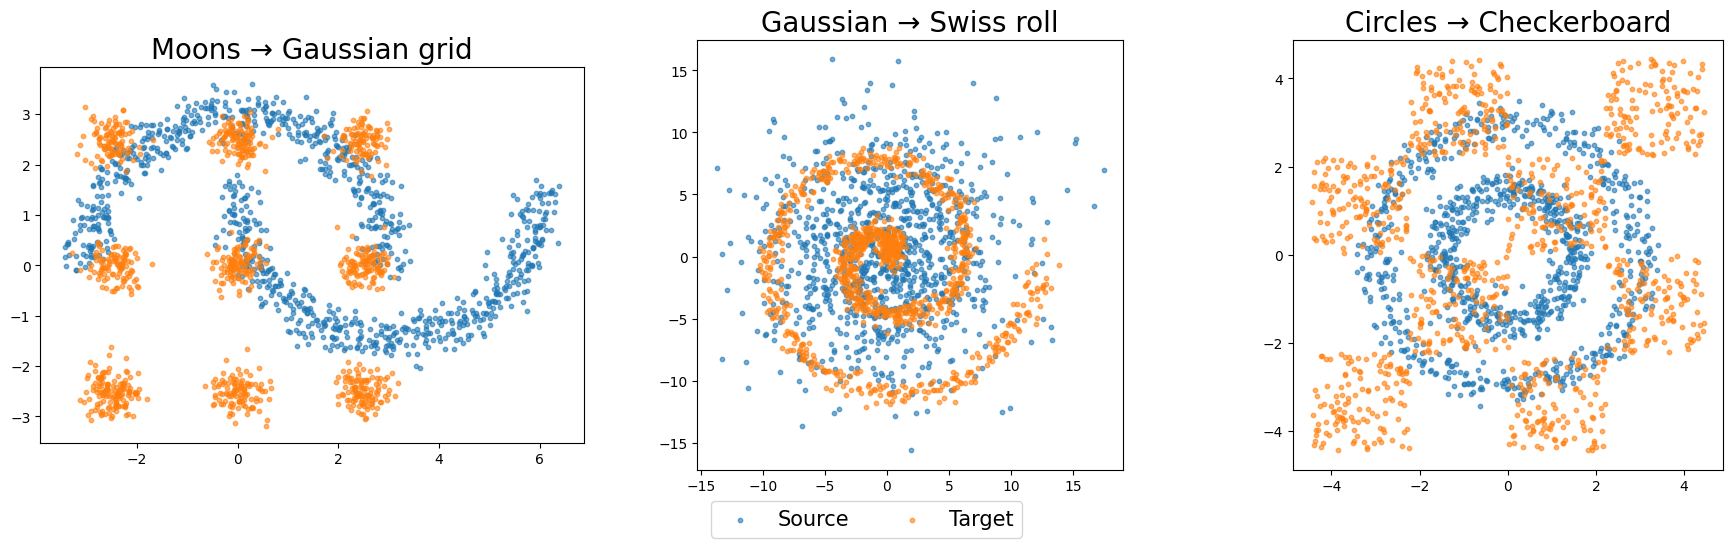

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def plot_all_2d_datasets(datasets, m, n, seed=1337):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    for i, (dataset_name, title) in enumerate(datasets.items()):
        sources, targets = generate_2d_pairs(dataset=dataset_name, num_pairs=1,
                                             m=m, n=n, seed=seed)

        source = sources[0]
        target = targets[0]

        ax = axes[i]
        ax.scatter(source[:, 0], source[:, 1], s=10, alpha=0.6, label='Source')
        ax.scatter(target[:, 0], target[:, 1], s=10, alpha=0.6, label='Target')

        ax.set_title(title, fontsize=20)
        ax.set_aspect('equal', adjustable='box')

    #common legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=15)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

    filename = 'app_2d_data_visualization.pdf'
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    files.download(filename)


datasets = {
    'moons_gaussian_grid': 'Moons → Gaussian grid',
    'gaussian_swiss_roll': 'Gaussian → Swiss roll',
    'circles_checkerboard': 'Circles → Checkerboard'
}

plot_all_2d_datasets(datasets, m=1000, n=1000, seed=1337)

#### Repeat experiment 5 more times

##### Functions

In [ ]:
################################
#       Timed solvers          #
################################

#exactly same implementation as before, just that now we also record the time
def _timing_result(u, v, error_history, cost_history, update_time_history,
                   iteration_history, update_time, num_iterations):

    return {'u': u, 'v': v, 'error': error_history, 'cost': cost_history,
            'update_time_history': update_time_history, 'iteration_history': iteration_history,
            'update_time': update_time, 'num_iterations': num_iterations}


################################
#          Sinkhorn            #
################################

def sinkhorn_sequential_timed(a, b, K, max_updates=int(1e8), tol=None,
                              budget=None, record_cost_every=int(1e5)):

    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    m, n = K.shape
    tiny = np.finfo(np.float64).tiny

    #initialization
    v = b.copy()
    u = a / np.maximum(K @ v, tiny)

    cost = 0
    num_iterations = 0

    error_history = [float(marginal_error(a, b, K, u, v))]
    cost_history = [0]
    update_time_history = [0.0]
    iteration_history = [0]

    update_time = 0.0
    next_record_cost = record_cost_every

    cycle_length = n + m

    #start timing solver updates
    chunk_start = time.perf_counter()

    for update in range(max_updates):

        position = update % cycle_length

        #column update
        if position < n:
            j = position
            update_cost = m

            if budget is not None and cost + update_cost > budget:
                break

            denom = max(np.dot(K[:, j], u), tiny)
            v[j] = b[j] / denom

        #row update
        else:
            i = position - n
            update_cost = n

            if budget is not None and cost + update_cost > budget:
                break

            denom = max(np.dot(K[i, :], v), tiny)
            u[i] = a[i] / denom

        cost += update_cost
        num_iterations += 1

        #diagnostic checkpoint
        if cost >= next_record_cost:

            #stop update timer BEFORE computing error
            update_time += time.perf_counter() - chunk_start

            err = float(marginal_error(a, b, K, u, v))

            error_history.append(err)
            cost_history.append(cost)
            update_time_history.append(update_time)
            iteration_history.append(num_iterations)

            while next_record_cost <= cost:
                next_record_cost += record_cost_every

            if tol is not None and err <= tol:
                break

            #restart update timer AFTER diagnostic
            chunk_start = time.perf_counter()

    else:
        #loop ended naturally
        update_time += time.perf_counter() - chunk_start

    #if loop broke between checkpoints, collect remaining update time
    if cost_history[-1] != cost:

        update_time += time.perf_counter() - chunk_start

        err = float(marginal_error(a, b, K, u, v))

        error_history.append(err)
        cost_history.append(cost)
        update_time_history.append(update_time)
        iteration_history.append(num_iterations)

    return _timing_result(u, v, error_history, cost_history, update_time_history,
                          iteration_history, update_time, num_iterations)


################################
#             SSS              #
################################

def sss_timed(a, b, K, gamma=1.0, sampling='random', max_iter=int(1e8),
              tol=None, budget=None, seed=None, record_cost_every=int(1e5)):

    rng = np.random.default_rng(seed)

    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    m, n = K.shape
    tiny = np.finfo(np.float64).tiny

    #initialization
    v = b.copy()
    Kv = K @ v
    u = a / np.maximum(Kv, tiny)

    cost = 0
    num_iterations = 0

    error = sss_marginal_error(a, b, K, u, v, Kv)

    error_history = [float(error)]
    cost_history = [0]
    update_time_history = [0.0]
    iteration_history = [0]

    update_time = 0.0
    next_record_cost = record_cost_every

    #coordinate ordering
    permutation = None

    if sampling == 'cyclic':
        permutation = rng.permutation(n)

    elif sampling not in ('random', 'shuffle'):
        raise ValueError('Sampling must be random, shuffle, or cyclic')

    chunk_start = time.perf_counter()

    for iteration in range(max_iter):

        if budget is not None and cost + m > budget:
            break

        #coordinate selection is part of the solver
        if sampling == 'random':
            j = rng.integers(n)

        elif sampling == 'shuffle':
            if iteration % n == 0:
                permutation = rng.permutation(n)

            j = permutation[iteration % n]

        else:
            j = permutation[iteration % n]

        #target marginal
        marginal_j = v[j] * np.dot(K[:, j], u)
        marginal_j = max(marginal_j, tiny)

        #SSS coordinate update
        old_v_j = v[j]

        v[j] = (old_v_j* (b[j] / marginal_j) ** (gamma * n))

        #rolling source marginal update
        Kv += K[:, j] * (v[j] - old_v_j)

        #source normalization
        u = a / np.maximum(Kv, tiny)

        cost += m
        num_iterations += 1

        #diagnostic checkpoint
        if cost >= next_record_cost:

            update_time += time.perf_counter() - chunk_start

            error = float(sss_marginal_error(a, b, K, u, v, Kv))

            error_history.append(error)
            cost_history.append(cost)
            update_time_history.append(update_time)
            iteration_history.append(num_iterations)

            while next_record_cost <= cost:
                next_record_cost += record_cost_every

            if tol is not None and error <= tol:
                break

            chunk_start = time.perf_counter()

    else:
        update_time += time.perf_counter() - chunk_start

    if cost_history[-1] != cost:
        update_time += time.perf_counter() - chunk_start
        error = float(sss_marginal_error(a, b, K, u, v, Kv))

        error_history.append(error)
        cost_history.append(cost)
        update_time_history.append(update_time)
        iteration_history.append(num_iterations)

    return _timing_result(u, v, error_history, cost_history, update_time_history,
                          iteration_history, update_time, num_iterations)


################################
#         Greenkhorn           #
################################

def greenkhorn_timed(a, b, K, max_iter=int(1e8), tol=None,
                     budget=None, record_cost_every=int(1e5)):

    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    m, n = K.shape
    tiny = np.finfo(np.float64).tiny

    #initialization
    v = b.copy()
    u = a / np.maximum(K @ v, tiny)

    row_violation = u * (K @ v) - a
    col_violation = v * (K.T @ u) - b

    error = marginal_error(a, b, K, u, v)

    error_history = [float(error)]
    cost_history = [0]
    update_time_history = [0.0]

    cost = 0
    num_iterations = 0
    update_time = 0.0
    iteration_history = [0]

    next_record_cost = record_cost_every

    chunk_start = time.perf_counter()

    for iteration in range(max_iter):

        #coordinate search is part of Greenkhorn
        i = np.argmax(np.abs(row_violation))
        j = np.argmax(np.abs(col_violation))

        row_max = np.abs(row_violation[i])
        col_max = np.abs(col_violation[j])

        #row update
        if row_max > col_max:
            update_cost = n

            if budget is not None and cost + update_cost > budget:
                break

            old_u_i = u[i]

            denom = max(np.dot(K[i, :], v), tiny)
            new_u_i = a[i] / denom

            delta_u = new_u_i - old_u_i

            row_violation[i] = (
                new_u_i * np.dot(K[i, :], v) - a[i]
            )

            col_violation += delta_u * K[i, :] * v

            u[i] = new_u_i

        #column update
        else:
            update_cost = m

            if budget is not None and cost + update_cost > budget:
                break

            old_v_j = v[j]

            denom = max(np.dot(K[:, j], u), tiny)
            new_v_j = b[j] / denom

            delta_v = new_v_j - old_v_j

            row_violation += delta_v * K[:, j] * u
            col_violation[j] = (new_v_j * np.dot(K[:, j], u) - b[j])

            v[j] = new_v_j

        cost += update_cost
        num_iterations += 1

        if cost >= next_record_cost:

            update_time += time.perf_counter() - chunk_start

            error = float(marginal_error(a, b, K, u, v))

            error_history.append(error)
            cost_history.append(cost)
            update_time_history.append(update_time)
            iteration_history.append(num_iterations)

            while next_record_cost <= cost:
                next_record_cost += record_cost_every

            if tol is not None and error <= tol:
                break

            chunk_start = time.perf_counter()

    else:
        update_time += time.perf_counter() - chunk_start

    if cost_history[-1] != cost:

        update_time += time.perf_counter() - chunk_start

        error = float(marginal_error(a, b, K, u, v))

        error_history.append(error)
        cost_history.append(cost)
        update_time_history.append(update_time)
        iteration_history.append(num_iterations)

    return _timing_result(u, v, error_history, cost_history, update_time_history,
                          iteration_history, update_time, num_iterations)


################################
#     Stochastic Sinkhorn      #
################################

def stochastic_sinkhorn_timed(a, b, K, max_iter=int(1e8), tol=None,
                              budget=None, seed=None,
                              record_cost_every=int(1e5)):

    rng = np.random.default_rng(seed)

    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    m, n = K.shape
    tiny = np.finfo(np.float64).tiny

    #initialization
    v = b.copy()
    u = a / np.maximum(K @ v, tiny)

    error = marginal_error(a, b, K, u, v)

    error_history = [float(error)]
    cost_history = [0]
    update_time_history = [0.0]
    iteration_history = [0]

    cost = 0
    num_iterations = 0
    update_time = 0.0

    next_record_cost = record_cost_every

    chunk_start = time.perf_counter()

    for iteration in range(max_iter):

        index = rng.integers(m + n)

        #row update
        if index < m:
            i = index
            update_cost = n

            if budget is not None and cost + update_cost > budget:
                break

            denom = max(np.dot(K[i, :], v), tiny)
            u[i] = a[i] / denom

        #column update
        else:
            j = index - m
            update_cost = m

            if budget is not None and cost + update_cost > budget:
                break

            denom = max(np.dot(K[:, j], u), tiny)
            v[j] = b[j] / denom

        cost += update_cost
        num_iterations += 1

        if cost >= next_record_cost:

            update_time += time.perf_counter() - chunk_start

            error = float(marginal_error(a, b, K, u, v))

            error_history.append(error)
            cost_history.append(cost)
            update_time_history.append(update_time)
            iteration_history.append(num_iterations)

            while next_record_cost <= cost:
                next_record_cost += record_cost_every

            if tol is not None and error <= tol:
                break

            chunk_start = time.perf_counter()

    else:
        update_time += time.perf_counter() - chunk_start

    if cost_history[-1] != cost:

        update_time += time.perf_counter() - chunk_start

        error = float(marginal_error(a, b, K, u, v))

        error_history.append(error)
        cost_history.append(cost)
        update_time_history.append(update_time)
        iteration_history.append(num_iterations)

    return _timing_result(u, v, error_history, cost_history, update_time_history,
                          iteration_history, update_time, num_iterations)



# trainer functions
def run_solvers_2d_timed(source, target, reg=1e-2, gamma0=1.0,
                         budget=int(1e7), tol=None, max_iter=10_000_000,
                         record_cost_every=None, seed=1337):

    a, b, C = prepare_ot_problem(source, target)

    m = len(a)
    n = len(b)

    K = np.exp(-C / reg)
    gamma = gamma0 / n

    if record_cost_every is None:
        record_cost_every = max(1, budget // 100)

    results = {}

    results['sinkhorn'] = sinkhorn_sequential_timed(a, b, K, max_updates=max_iter,
                                                    tol=tol, budget=budget,
                                                    record_cost_every=record_cost_every)

    results['sss'] = sss_timed(a, b, K, gamma=gamma, sampling='random', max_iter=max_iter,
                               tol=tol, budget=budget, seed=seed, record_cost_every=record_cost_every)

    results['sss_cyclic'] = sss_timed(a, b, K, gamma=gamma, sampling='cyclic', max_iter=max_iter,
                                      tol=tol, budget=budget, seed=seed,
                                      record_cost_every=record_cost_every)

    results['greenkhorn'] = greenkhorn_timed(a, b, K, max_iter=max_iter, tol=tol,
                                             budget=budget, record_cost_every=record_cost_every)

    results['stochastic_sinkhorn'] = stochastic_sinkhorn_timed(a, b, K, max_iter=max_iter,
                                                               tol=tol, budget=budget, seed=seed,
                                                               record_cost_every=record_cost_every)

    return results

##### Experiment

In [ ]:
#run experiment
datasets = {'moons_gaussian_grid': 'Moons → Gaussian grid',
            'gaussian_swiss_roll': 'Gaussian → Swiss roll',
            'circles_checkerboard': 'Circles → Checkerboard'}

seeds = [1337, 1338, 1339, 1340, 1341]

m = 50
n = 10000
reg = 1e-2
gamma0 = 1.0
budget = int(1e8)

#around 50 error measurements over the full budget
record_cost_every = int(2e6)

multiseed_results = {}

for dataset, dataset_title in datasets.items():

    multiseed_results[dataset] = {}

    for seed in tqdm(seeds, desc=dataset_title):

        sources, targets = generate_2d_pairs(dataset, 1, m, n, seed)

        source = sources[0]
        target = targets[0]

        solver_results = run_solvers_2d_timed(source, target, reg=reg, gamma0=gamma0,
                                              budget=budget, tol=None, record_cost_every=record_cost_every,
                                              seed=seed)

        multiseed_results[dataset][seed] = {'source': source, 'target': target, 'solvers': solver_results}

Moons → Gaussian grid:   0%|          | 0/5 [00:00<?, ?it/s]

Gaussian → Swiss roll:   0%|          | 0/5 [00:00<?, ?it/s]

Circles → Checkerboard:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
def plot_2d_multiseed(multiseed_results, datasets, seeds):

    solver_labels = {'sss_cyclic': 'SSS cyclic', 'sss': 'SSS', 'sinkhorn': 'Sinkhorn',
                     'stochastic_sinkhorn': 'Stochastic Sinkhorn', 'greenkhorn': 'Greenkhorn'}

    colors = {'sinkhorn': 'magenta','sss': 'green', 'sss_cyclic': 'orange',
              'greenkhorn': 'red', 'stochastic_sinkhorn': 'blue'}

    fig, axes = plt.subplots(len(datasets), len(seeds), figsize=(25, 13),
                             sharex=True, sharey='row')

    for row, (dataset, dataset_title) in enumerate(datasets.items()):
        for col, seed in enumerate(seeds):
            ax = axes[row, col]
            solver_results = multiseed_results[dataset][seed]['solvers']

            for solver_name, label in solver_labels.items():
                result = solver_results[solver_name]

                cost = np.asarray(result['cost'])
                error = np.asarray(result['error'])

                ax.plot(cost, error, color=colors[solver_name], linewidth=2,
                        label=label)

            ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=14)

            #column titles
            if row == 0:
                ax.set_title(f'Seed {seed}', fontsize=20)

            #row labels
            if col == 0:
                ax.set_ylabel(dataset_title + '\n' + r'$\ell_1$ error',fontsize=18)

            #x-axis labels only on bottom row
            if row == len(datasets) - 1:
                ax.set_xlabel('Computational cost', fontsize=18)

            ax.xaxis.get_offset_text().set_fontsize(14)

    #common legend
    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.995),
               frameon=False, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=1.5, w_pad=1.0)

    filename = 'app_2d_extra_graphs.pdf'
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    files.download(filename)

    return fig, axes

In [ ]:
#create plot
fig, axes = plot_2d_multiseed(multiseed_results, datasets, seeds)
plt.show()

#filename = 'app_2d_extra_graphs.pdf'
#fig.savefig(filename, format='pdf', bbox_inches='tight')
#files.download(filename)

In [ ]:
#extra plots
def plot_error_vs_updates(multiseed_results, datasets, seeds):

    solver_labels = {'sss_cyclic': 'SSS cyclic', 'sss': 'SSS', 'sinkhorn': 'Sinkhorn',
                     'stochastic_sinkhorn': 'Stochastic Sinkhorn', 'greenkhorn': 'Greenkhorn'}

    colors = {'sinkhorn': 'magenta','sss': 'green', 'sss_cyclic': 'orange',
              'greenkhorn': 'red', 'stochastic_sinkhorn': 'blue'}

    fig, axes = plt.subplots(len(datasets), len(seeds), figsize=(25, 13), sharey='row')

    for row, (dataset, dataset_title) in enumerate(datasets.items()):

        for col, seed in enumerate(seeds):

            ax = axes[row, col]
            solver_results = (multiseed_results[dataset][seed]['solvers'])

            for solver, label in solver_labels.items():

                result = solver_results[solver]

                updates = np.asarray(result['iteration_history'])
                error = np.asarray(result['error'])

                ax.plot(updates, error, color=colors[solver], linewidth=2,label=label)

            ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
            ax.ticklabel_format(axis='x',style='sci',scilimits=(0, 0))
            ax.tick_params(axis='both', labelsize=14)

            if row == 0:
                ax.set_title(f'Seed {seed}',fontsize=20)

            if col == 0:
                ax.set_ylabel(dataset_title + '\n' + r'$\ell_1$ error',fontsize=18)

            if row == len(datasets) - 1:
                ax.set_xlabel('Number of row/column updates',fontsize=18)

    handles, labels = (axes[0, 0].get_legend_handles_labels())

    fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.995),
               frameon=False, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=1.5, w_pad=1.0)

    filename = 'app_2d_extra_graphs_b.pdf'
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    files.download(filename)

    return fig, axes



def plot_cost_vs_updates(multiseed_results, datasets, seeds):

    solver_labels = {'sss_cyclic': 'SSS cyclic', 'sss': 'SSS', 'sinkhorn': 'Sinkhorn',
                     'stochastic_sinkhorn': 'Stochastic Sinkhorn', 'greenkhorn': 'Greenkhorn'}
    colors = {'sinkhorn': 'magenta','sss': 'green', 'sss_cyclic': 'orange',
              'greenkhorn': 'red', 'stochastic_sinkhorn': 'blue'}

    fig, axes = plt.subplots(len(datasets), len(seeds),figsize=(25, 13), sharey='row')

    for row, (dataset, dataset_title) in enumerate(datasets.items()):

        for col, seed in enumerate(seeds):

            ax = axes[row, col]

            solver_results = (multiseed_results[dataset][seed]['solvers'])

            for solver, label in solver_labels.items():

                result = solver_results[solver]

                updates = np.asarray(result['iteration_history'])

                cost = np.asarray(result['cost'])

                ax.plot(updates, cost, color=colors[solver], linewidth=2, label=label)

            ax.grid(True, alpha=0.3)

            ax.ticklabel_format(axis='both', style='sci', scilimits=(0, 0))

            if row == 0:
                ax.set_title(f'Seed {seed}', fontsize=20)

            if col == 0:
                ax.set_ylabel(dataset_title + '\nComputational cost', fontsize=18)

            if row == len(datasets) - 1:
                ax.set_xlabel('Number of row/column updates',fontsize=18)

    handles, labels = (axes[0, 0].get_legend_handles_labels())

    fig.legend(
        handles,
        labels,
        loc='upper center',
        ncol=5,
        bbox_to_anchor=(0.5, 0.995),
        frameon=False,
        fontsize=18
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95],
        h_pad=1.5,
        w_pad=1.0
    )

    filename = 'app_2d_extra_graphs_c.pdf'
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    files.download(filename)

    return fig, axes

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

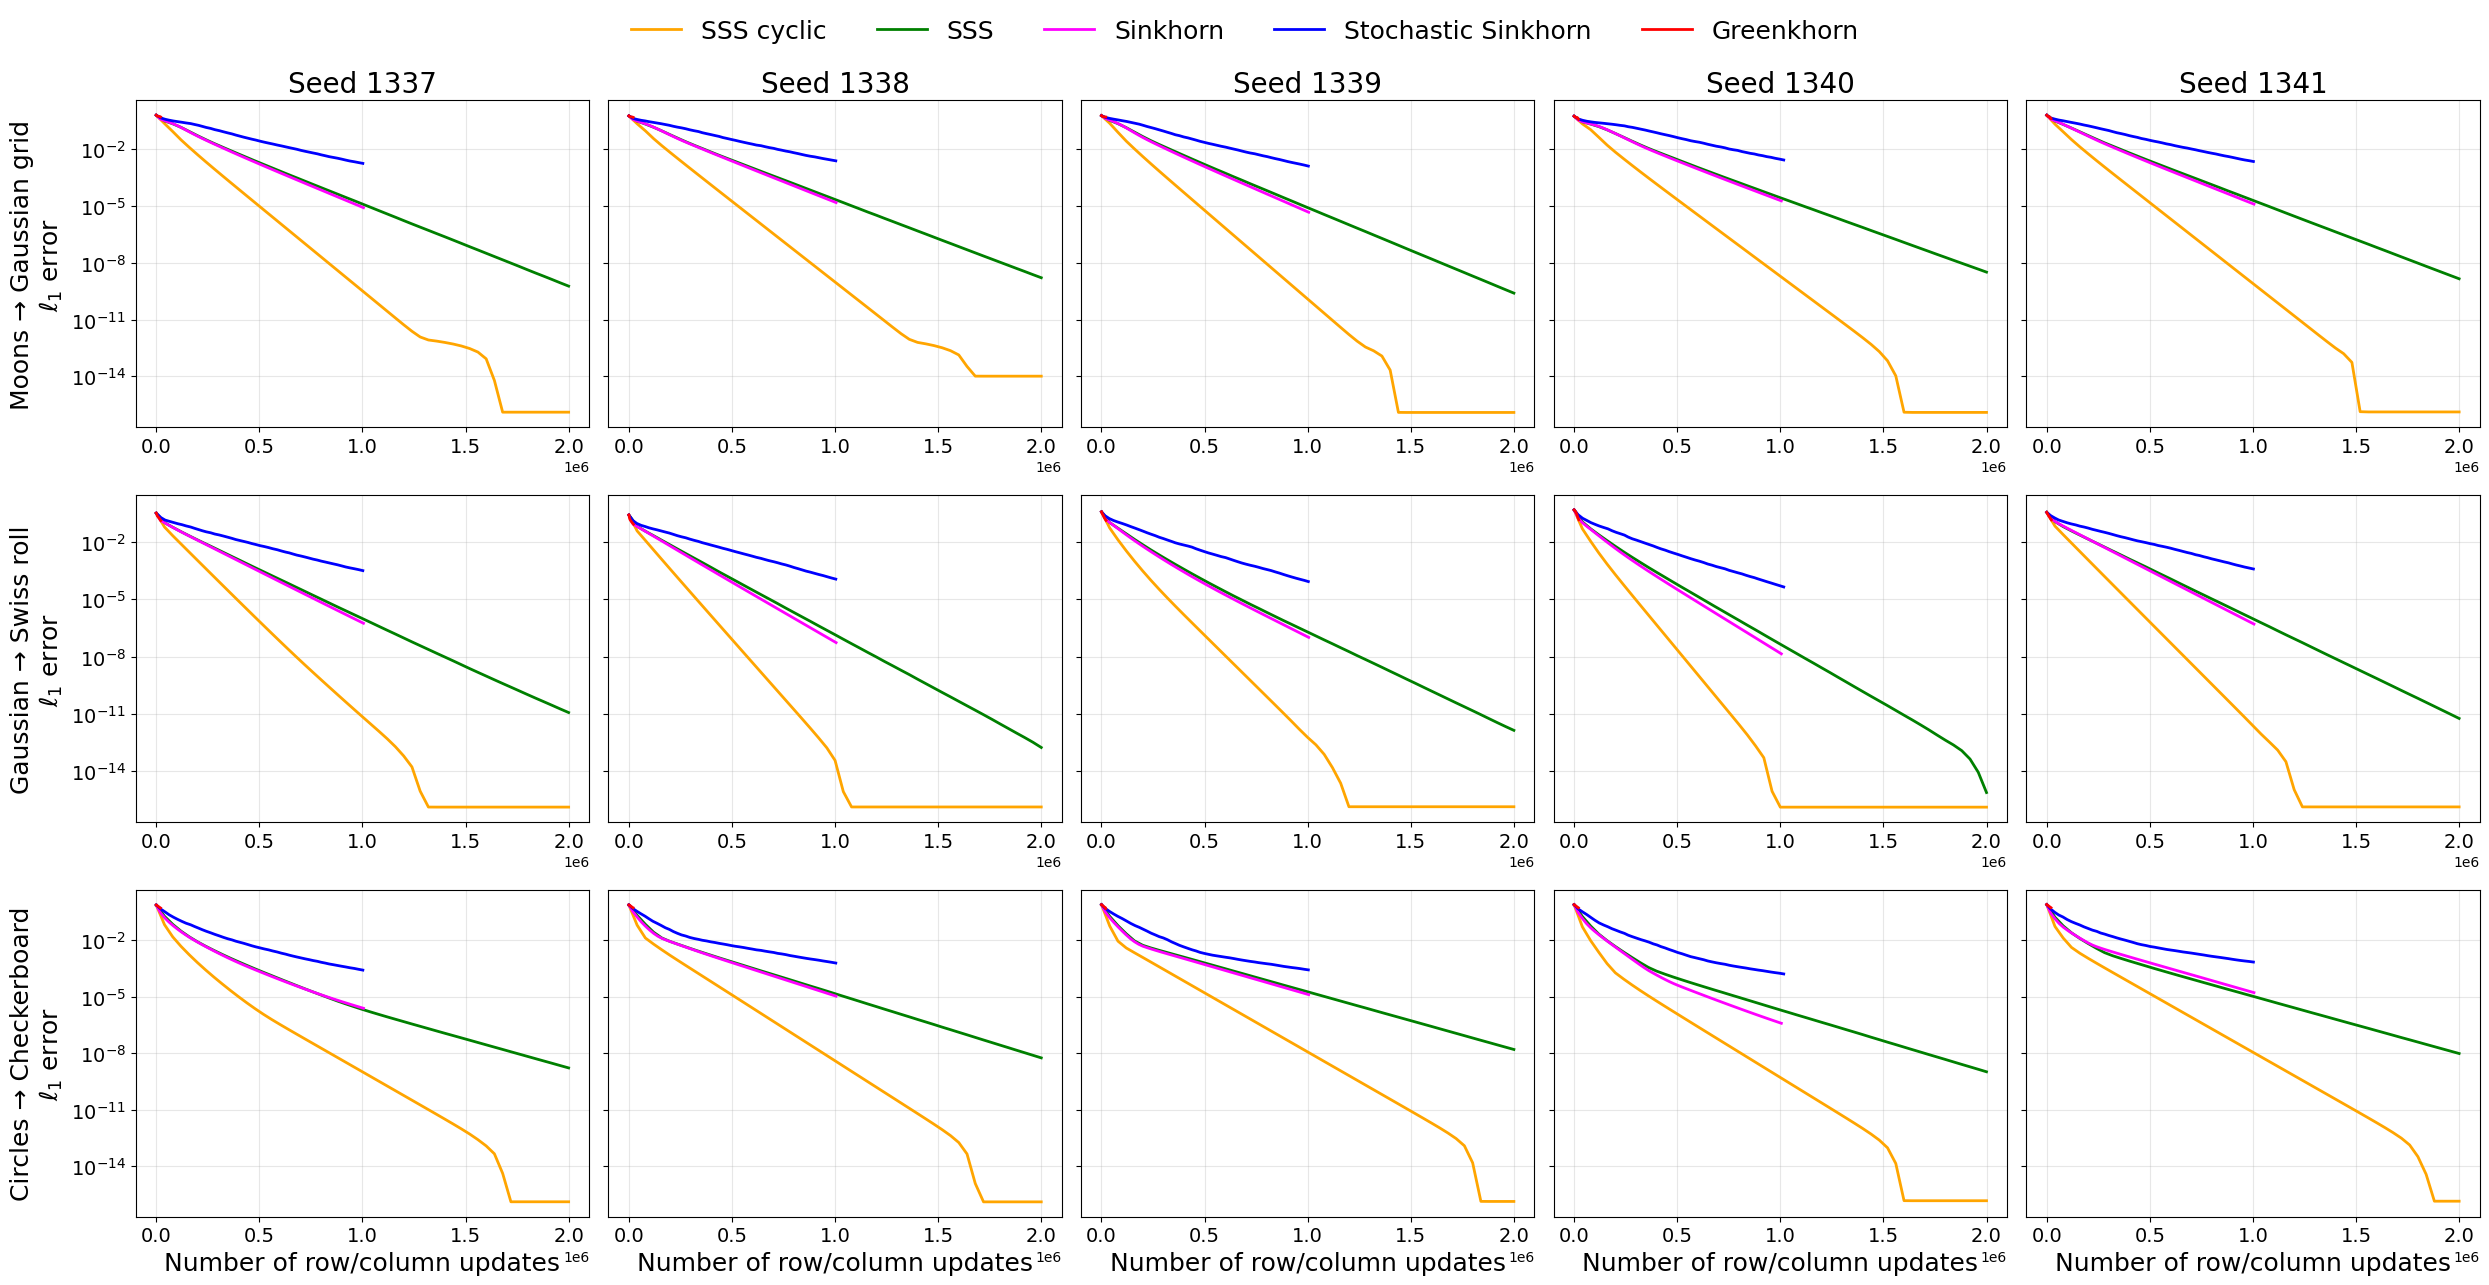

In [ ]:
fig_updates, axes_updates = plot_error_vs_updates(multiseed_results,datasets, seeds)
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

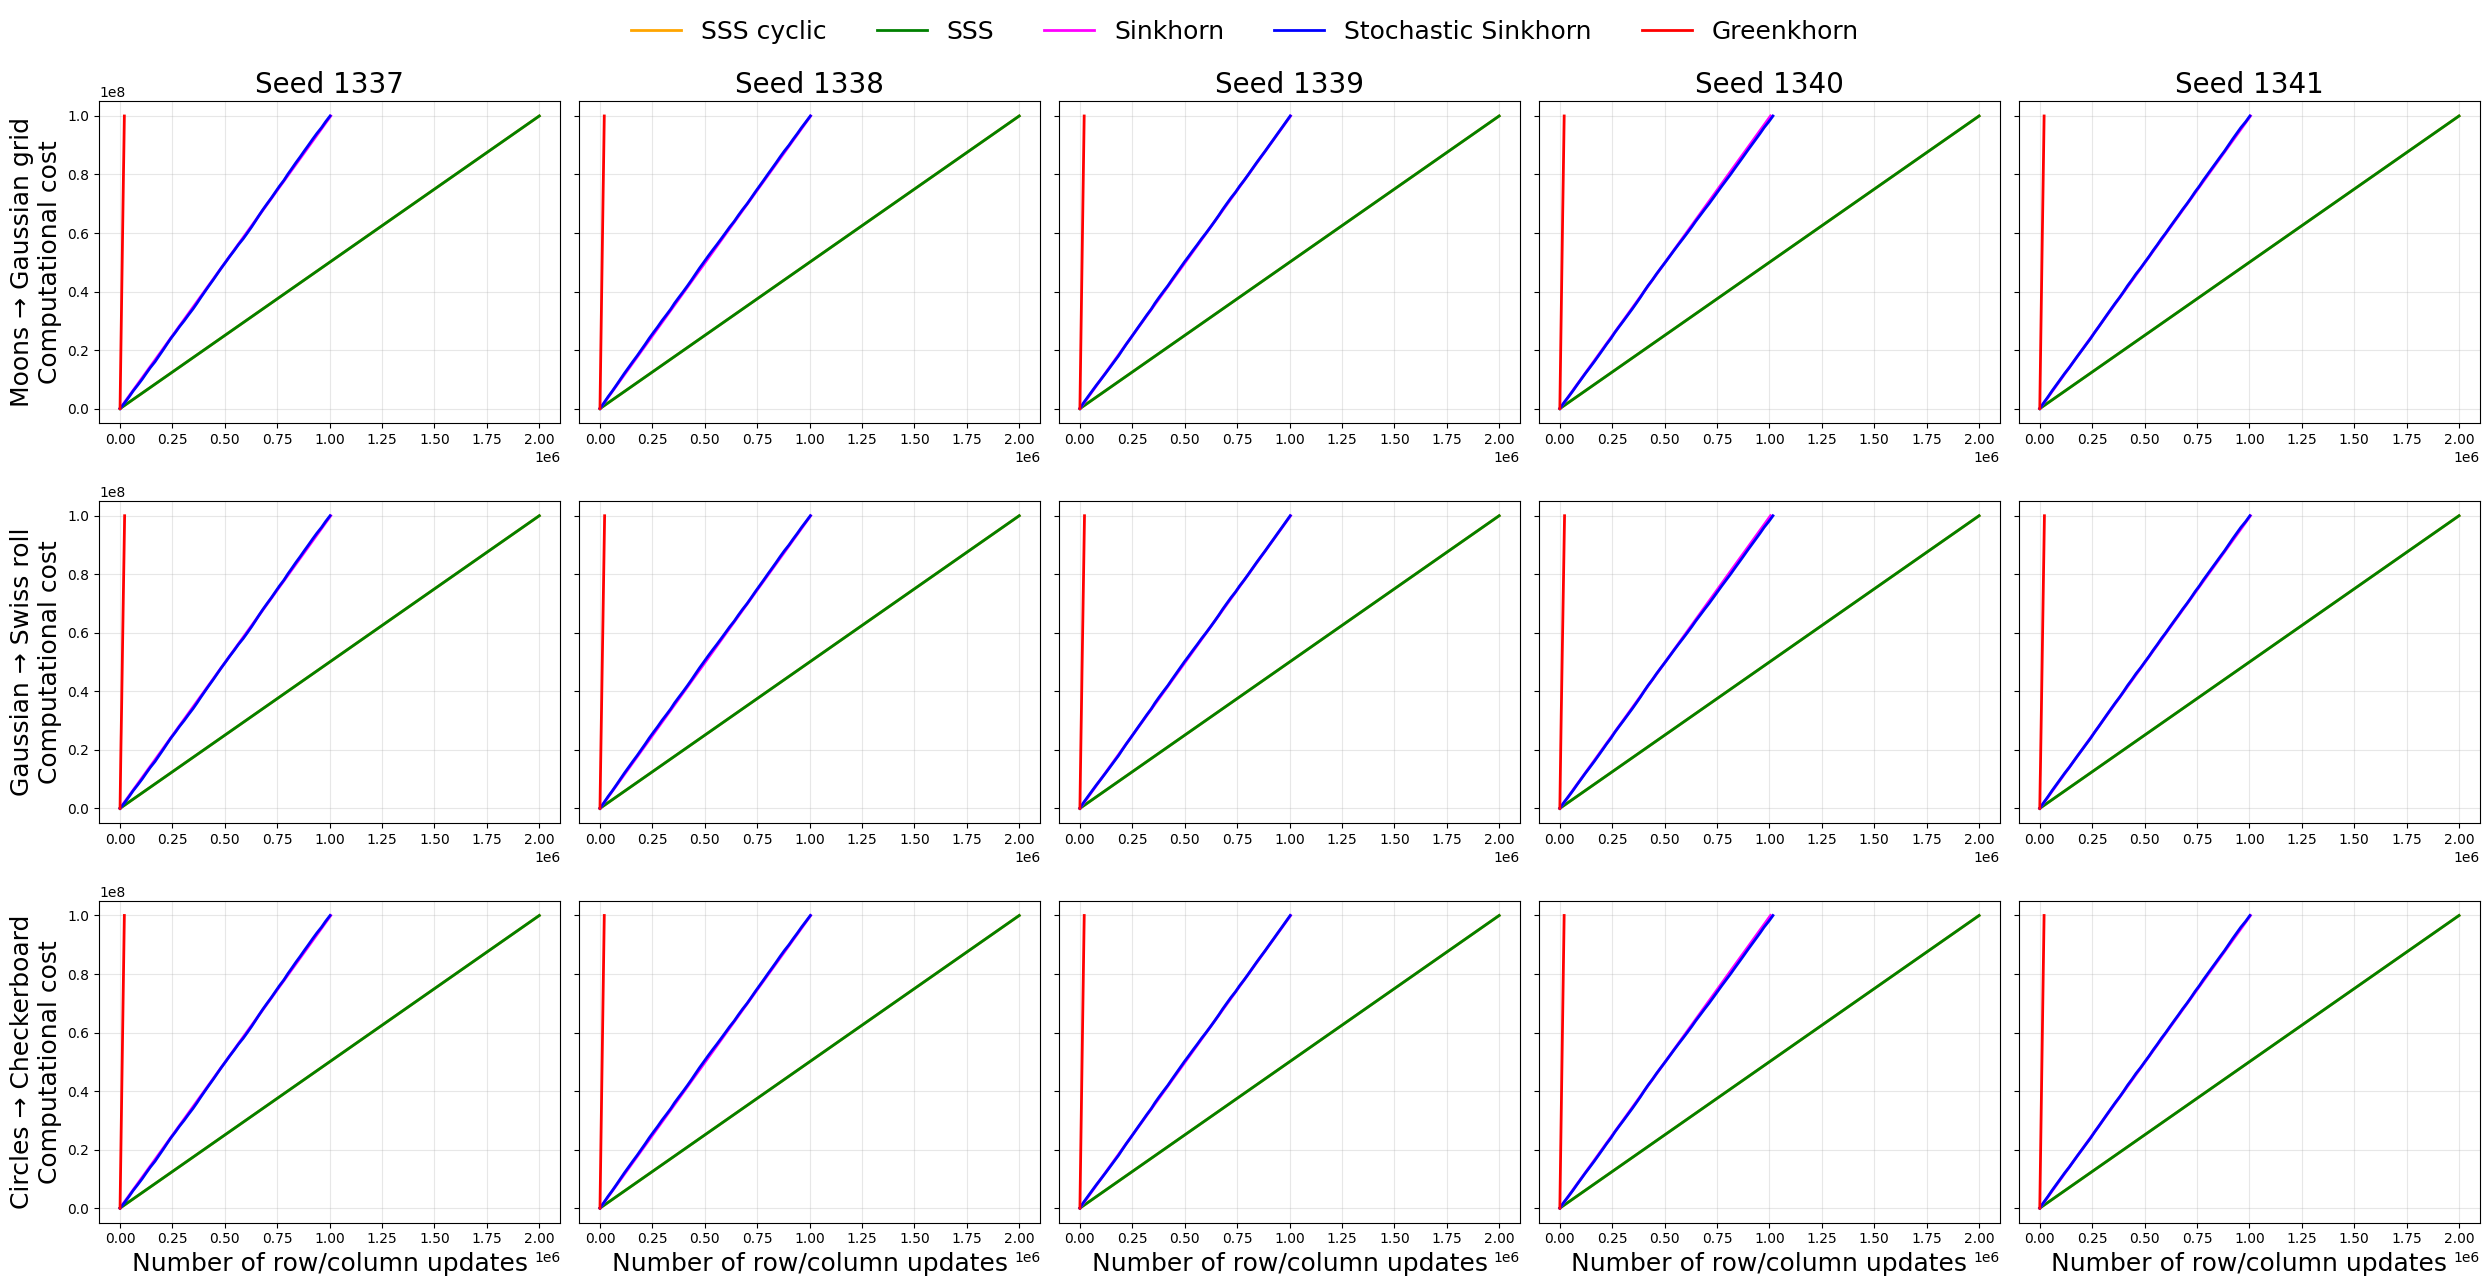

In [ ]:
fig_cost_updates, axes_cost_updates = plot_cost_vs_updates(multiseed_results, datasets, seeds)
plt.show()


In [ ]:
############################################
# SSS vs Sinkhorn update timing        #
############################################

def benchmark_sss_update(a, b, K, num_updates=5000,num_repeats=10, seed=1337):

    rng = np.random.default_rng(seed)

    m, n = K.shape
    tiny = np.finfo(np.float64).tiny
    gamma = 1.0 / n

    v = b.copy()
    Kv = K @ v
    u = a / np.maximum(Kv, tiny)

    #warm-up
    for _ in range(100):

        j = rng.integers(n)

        marginal_j = v[j] * np.dot(K[:, j], u)
        marginal_j = max(marginal_j, tiny)

        old_v_j = v[j]

        v[j] = (old_v_j* (b[j] / marginal_j) ** (gamma * n))
        Kv += K[:, j] * (v[j] - old_v_j)
        u = a / np.maximum(Kv, tiny)

    repeat_times = []

    for repeat in range(num_repeats):

        start = time.perf_counter()

        for _ in range(num_updates):

            j = rng.integers(n)

            marginal_j = v[j] * np.dot(K[:, j], u)
            marginal_j = max(marginal_j, tiny)

            old_v_j = v[j]

            v[j] = (old_v_j* (b[j] / marginal_j) ** (gamma * n))
            Kv += K[:, j] * (v[j] - old_v_j)
            u = a / np.maximum(Kv, tiny)

        elapsed = time.perf_counter() - start

        repeat_times.append(elapsed / num_updates)

    return np.median(repeat_times)


def benchmark_sinkhorn_row_update(a, b, K, num_updates=5000,num_repeats=10):

    m, n = K.shape
    tiny = np.finfo(np.float64).tiny

    v = b.copy()
    u = a / np.maximum(K @ v, tiny)

    #warm-up
    for k in range(100):
        i = k % m
        denom = max(np.dot(K[i, :], v), tiny)
        u[i] = a[i] / denom

    repeat_times = []

    for repeat in range(num_repeats):

        start = time.perf_counter()

        for k in range(num_updates):
            i = k % m
            denom = max(np.dot(K[i, :], v), tiny)

            u[i] = a[i] / denom

        elapsed = time.perf_counter() - start

        repeat_times.append(elapsed / num_updates)

    return np.median(repeat_times)


############################################
# run scaling experiment                   #
############################################

def run_update_scaling_experiment(datasets, seeds, n_values, m=50,
                                  reg=1e-2, num_updates=5000,
                                  num_repeats=10):

    timing_results = {}

    for dataset, dataset_title in datasets.items():

        timing_results[dataset] = {'sss': {}, 'sinkhorn_row': {}}

        for n in n_values:

            sss_times = []
            sinkhorn_row_times = []

            for seed in seeds:

                sources, targets = generate_2d_pairs(dataset, 1, m, n, seed)

                source = sources[0]
                target = targets[0]

                a, b, C = prepare_ot_problem(source,target)

                K = np.exp(-C / reg)

                #SSS update time
                sss_time = benchmark_sss_update( a, b, K, num_updates=num_updates,
                                                num_repeats=num_repeats, seed=seed)

                #Sinkhorn update time
                row_time = benchmark_sinkhorn_row_update(a, b, K,num_updates=num_updates, num_repeats=num_repeats)

                sss_times.append(sss_time)
                sinkhorn_row_times.append(row_time)

            timing_results[dataset]['sss'][n] = np.array(sss_times)

            timing_results[dataset]['sinkhorn_row'][n] = np.array(sinkhorn_row_times)

    return timing_results


############################################
# plot SSS vs Sinkhorn row update          #
############################################

def plot_update_scaling(timing_results, datasets, n_values):

    fig, axes = plt.subplots(1,len(datasets),figsize=(18, 5),sharey=True)

    for ax, (dataset, dataset_title) in zip(axes,datasets.items()):

        sss_mean = []
        sss_std = []

        row_mean = []
        row_std = []

        for n in n_values:

            #convert seconds -> microseconds
            sss_values = (timing_results[dataset]['sss'][n]* 1e6)
            row_values = (timing_results[dataset]['sinkhorn_row'][n] * 1e6 )

            sss_mean.append(np.mean(sss_values))
            sss_std.append(np.std(sss_values, ddof=1))

            row_mean.append(np.mean(row_values))
            row_std.append(np.std(row_values, ddof=1))

        sss_mean = np.asarray(sss_mean)
        sss_std = np.asarray(sss_std)

        row_mean = np.asarray(row_mean)
        row_std = np.asarray(row_std)

        #SSS
        ax.plot(n_values, sss_mean, marker='o', linewidth=2, label='SSS update')
        ax.fill_between(n_values, sss_mean - sss_std, sss_mean + sss_std, alpha=0.2)

        #Sinkhorn row
        ax.plot(n_values,row_mean, marker='s', linewidth=2, label='Sinkhorn row update')
        ax.fill_between(n_values, row_mean - row_std, row_mean + row_std, alpha=0.2)

        ax.set_title(dataset_title,fontsize=18)

        ax.set_xlabel(r'Target support size $n$',fontsize=16)

        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel( r'Average update time ($\mu$s)', fontsize=16)
    handles, labels = (axes[0].get_legend_handles_labels())

    fig.legend(handles, labels, loc='upper center',ncol=2, bbox_to_anchor=(0.5, 1.12),
               frameon=False, fontsize=16)

    plt.tight_layout()

    filename = 'app_2d_extra_graphs_d.pdf'
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    files.download(filename)

    return fig, axes



In [ ]:
datasets = {'moons_gaussian_grid': 'Moons → Gaussian grid',
            'gaussian_swiss_roll': 'Gaussian → Swiss roll',
            'circles_checkerboard': 'Circles → Checkerboard'}
n_values = [30000, 30000, 40000,50000, 60000, 70000]

num_updates = 2000
num_repeats = 10

datasets = {'moons_gaussian_grid': 'Moons → Gaussian grid',
            'gaussian_swiss_roll': 'Gaussian → Swiss roll',
            'circles_checkerboard': 'Circles → Checkerboard'}

seeds = [1337, 1338, 1339, 1340, 1341]

timing_results = run_update_scaling_experiment(datasets, seeds, n_values, m=50,
                                               reg=1e-2, num_updates=5000,num_repeats=10)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

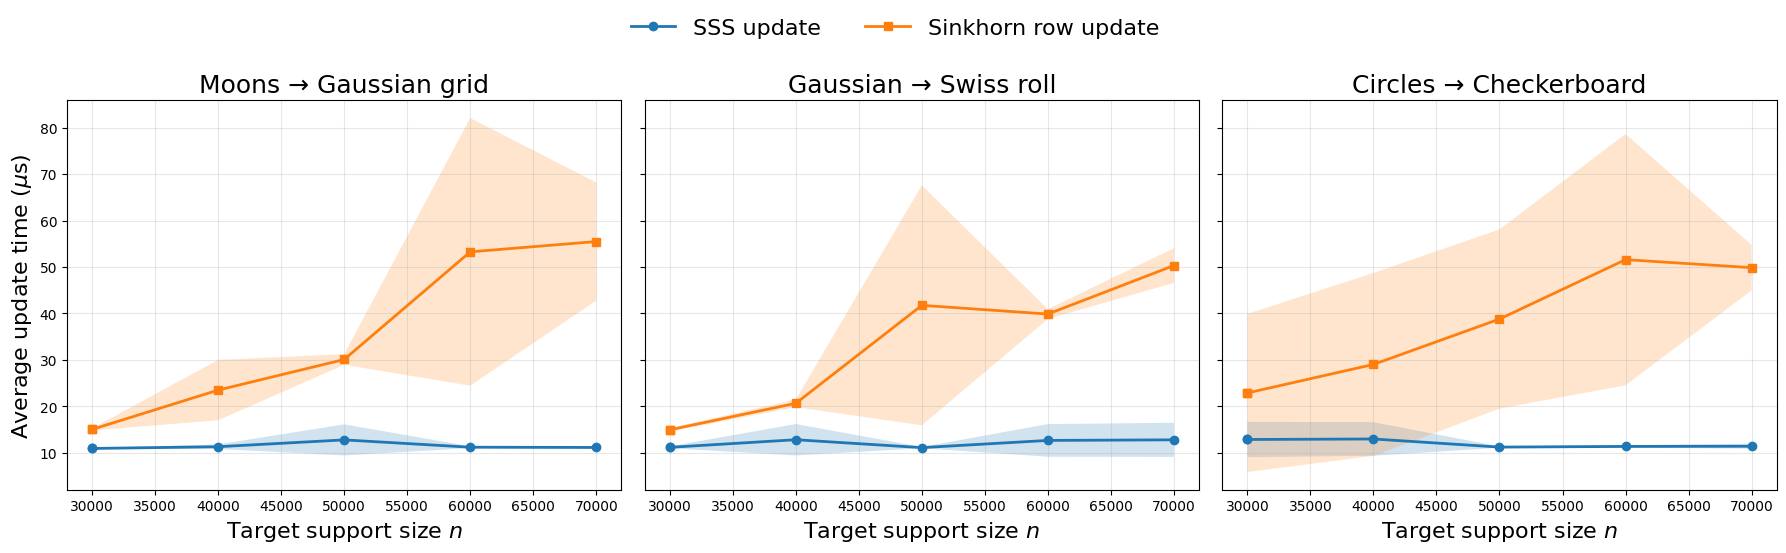

In [ ]:
fig_scaling, axes_scaling = plot_update_scaling(timing_results, datasets,n_values)

plt.show()

## (b) Color transfer

### Functions

#### Data

In [ ]:
#ONLY NEED TO RUN THIS ONCE TO DOWNLOAD IMAGES INTO GOOGLE DRIVE

'''
#download data
DATA_ROOT = "/content/data"

flowers = datasets.Flowers102(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=image_transform,
)

stl10 = datasets.STL10(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=image_transform,
)

#save 30 downloaded images into Google drive
from google.colab import drive
drive.mount('/content/drive')

rng = np.random.default_rng(1337)
num_images = 30

flower_indices = rng.choice(len(flowers), size=num_images, replace=False)
stl_indices = rng.choice(len(stl10), size=num_images, replace=False)
flower_images = torch.stack([flowers[i][0] for i in flower_indices])
stl_images = torch.stack([stl10[i][0] for i in stl_indices])

save_path = "/content/drive/MyDrive/color_transfer_images.pt"

torch.save(
    {'flower_images': flower_images, 'stl_images': stl_images,
     'flower_indices': flower_indices, 'stl_indices': stl_indices},
    save_path
    )
'''

'\n#download data\nDATA_ROOT = "/content/data"\n\nflowers = datasets.Flowers102(\n    root=DATA_ROOT,\n    split="train",\n    download=True,\n    transform=image_transform,\n)\n\nstl10 = datasets.STL10(\n    root=DATA_ROOT,\n    split="train",\n    download=True,\n    transform=image_transform,\n)\n\n#save 30 downloaded images into Google drive\nfrom google.colab import drive\ndrive.mount(\'/content/drive\')\n\nrng = np.random.default_rng(1337)\nnum_images = 30\n\nflower_indices = rng.choice(len(flowers), size=num_images, replace=False)\nstl_indices = rng.choice(len(stl10), size=num_images, replace=False)\nflower_images = torch.stack([flowers[i][0] for i in flower_indices])\nstl_images = torch.stack([stl10[i][0] for i in stl_indices])\n\nsave_path = "/content/drive/MyDrive/color_transfer_images.pt"\n\ntorch.save(\n    {\'flower_images\': flower_images, \'stl_images\': stl_images,\n     \'flower_indices\': flower_indices, \'stl_indices\': stl_indices},\n    save_path\n    )\n'

In [ ]:
#display images
def tensor_to_image(img):
    return img.permute(1, 2, 0).cpu().numpy()

#sample RGB pixels for OT plan later
def sample_image_colors(image, num_pixels, rng):

    full_image = tensor_to_image(image)
    pixels = full_image.reshape(-1, 3)

    if num_pixels > len(pixels):
        raise ValueError(
            f"Requested {num_pixels} pixels, "
            f"but image only contains {len(pixels)}."
        )

    indices = rng.choice(len(pixels), size=num_pixels, replace=False)
    sampled_colors = pixels[indices]

    return (sampled_colors.astype(np.float32), full_image.astype(np.float32))

#recovering color kernel without explicit construction
def squared_distance_block(X, Y):
    X2 = np.sum(X**2, axis=1)[:, None]
    Y2 = np.sum(Y**2, axis=1)[None, :]

    D = X2 + Y2 - 2.0 * (X @ Y.T)
    np.maximum(D, 0.0, out=D)
    return D

def build_color_kernel(source_colors, target_colors, reg=1e-2, block_size=128):
    X = np.asarray(source_colors, dtype=np.float64)
    Y = np.asarray(target_colors, dtype=np.float64)

    m = len(X)
    n = len(Y)

    #find max square distance in first pass
    C_max = 0.0

    for start in range(0, m, block_size):
        end = min(start + block_size, m)
        D = squared_distance_block(X[start:end], Y)
        C_max = max(C_max, float(D.max()))

    #construct K in second pass
    K = np.empty((m, n), dtype=np.float64)

    for start in range(0, m, block_size):
        end = min(start + block_size, m)
        D = squared_distance_block(X[start:end], Y)
        D /= C_max
        K[start:end] = np.exp(-D / reg)

    return K

#### Solvers

In [ ]:
#the implementation of the solvers here are identical to the ones used previously
#they are adjusted to merely compute violation once (at the end)

#SSS
def sss_final(a, b, K, gamma=1.0, sampling='random', budget=int(1e8), seed=None):
    m, n = K.shape
    rng = np.random.default_rng(seed)

    #initialization
    v = b.copy()
    Kv = K @ v
    u = a / Kv
    cost = 0
    iteration = 0

    #initialize permutation
    permutation = None
    if sampling == 'cyclic':
        permutation = rng.permutation(n)
    elif sampling not in ('random', 'shuffle'):
        raise ValueError("Sampling must be 'random', 'shuffle', or 'cyclic'")

    while cost + m <= budget:
        #handle coord selection
        if sampling == 'random':
            j = rng.integers(n)
        elif sampling == 'shuffle':
            if iteration % n == 0:
                permutation = rng.permutation(n)
            j = permutation[iteration % n]
        elif sampling == 'cyclic':
            j = permutation[iteration % n]

        #target marginal at coord j
        marginal_j = v[j] * np.dot(K[:, j], u)

        #SSS coordinate update
        old_v_j = v[j]
        v[j] = old_v_j * (b[j] / marginal_j) ** (gamma * n)
        Kv += K[:, j] * (v[j] - old_v_j)

        #source normalization
        u = a / Kv

        cost += m
        iteration += 1

    error = marginal_error(a, b, K, u, v)

    return u, v, float(error), cost


#Sinkhorn
def sinkhorn_final(a, b, K, budget=int(1e8)):

    m, n = K.shape

    v = b.copy()
    u = a / (K @ v)

    cost = 0
    iteration = 0

    while True:
        position = iteration % (n + m)
        if position < n:
            if cost + m > budget:
                break
            j = position
            v[j] = (b[j]/ np.dot(K[:, j], u))
            cost += m
        else:
            if cost + n > budget:
                break
            i = position - n
            u[i] = (a[i]/ np.dot(K[i, :], v))
            cost += n

        iteration += 1

    error = marginal_error(a, b, K, u, v)

    return u, v, float(error), cost



#stochastic-Sinkhorn
def stochastic_sinkhorn_final(a, b, K, budget=int(1e8), seed=None):
    rng = np.random.default_rng(seed)
    m, n = K.shape

    v = b.copy()
    u = a / (K @ v)
    cost = 0

    while True:
        i = rng.integers(m+n)
        if i < m:
          if cost + n > budget:
            break

          u[i] = a[i] / np.dot(K[i, :], v)
          cost += n

        else:
          if cost + m > budget:
            break
          j = i - m
          v[j] = b[j] / np.dot(K[:, j], u)
          cost += m

    error = marginal_error(a, b, K, u, v)

    return u, v, float(error), cost


#Greenkhorn
def greenkhorn_final(a, b, K, budget=int(1e8)):
    m, n = K.shape

    v = b.copy()
    u = a / (K @ v)

    row_violation = (u * (K @ v) - a)
    col_violation = (v * (K.T @ u) - b)

    cost = 0

    while True:
        i = np.argmax(np.abs(row_violation))
        j = np.argmax(np.abs(col_violation))

        #row update
        if (np.abs(row_violation[i]) > np.abs(col_violation[j])):
            if cost + n > budget:
                break

            old_u = u[i]
            new_u = (a[i]/ np.dot(K[i, :], v))
            delta = new_u - old_u
            col_violation += (delta * K[i, :] * v)
            u[i] = new_u
            row_violation[i] = 0.0
            cost += n

        #col update
        else:
            if cost + m > budget:
                break

            old_v = v[j]
            new_v = (b[j]/ np.dot(K[:, j], u))
            delta = new_v - old_v
            row_violation += (delta * K[:, j] * u)
            v[j] = new_v
            col_violation[j] = 0.0
            cost += m

    error = marginal_error(a, b, K, u, v)

    return u, v, float(error), cost

#### Helper functions

In [ ]:
def marginal_error(a, b, K, u, v):
    row_marginal = u * (K @ v)
    col_marginal = v * (K.T @ u)
    return (np.sum(np.abs(row_marginal - a)) + np.sum(np.abs(col_marginal - b)))

#trainer function
def run_color_solvers(K, gamma0=1.0, budget=int(1e8), seed=1337):
    m, n = K.shape
    dtype = K.dtype

    a = np.full(m, 1.0 / m, dtype=dtype)
    b = np.full(n, 1.0 / n, dtype=dtype)
    gamma = gamma0 / n

    results = {}

    #sinkhorn
    u, v, error, cost = sinkhorn_final(a, b, K, budget=budget)
    results['sinkhorn'] = {'u': u, 'v': v, 'error': error, 'cost': cost}

    #sss
    u, v, error, cost = sss_final(a, b, K, gamma=gamma, sampling='random',
                                 budget=budget, seed=seed)
    results['sss'] = {'u': u, 'v': v, 'error': error, 'cost': cost}

    #sss cyclic
    u, v, error, cost = sss_final(a, b, K, gamma=gamma, sampling='cyclic',
                                 budget=budget, seed=seed)
    results['sss_cyclic'] = {'u': u, 'v': v, 'error': error, 'cost': cost}

    #greenkhorn
    u, v, error, cost = greenkhorn_final(a, b, K, budget=budget)
    results['greenkhorn'] = {'u': u, 'v': v, 'error': error, 'cost': cost}

    #stochastic-Sinkhorn
    u, v, error, cost = stochastic_sinkhorn_final(a, b, K, budget=budget, seed=seed)
    results['stochastic_sinkhorn'] = {'u': u, 'v': v, 'error': error,
                                      'cost': cost}

    return results


#barycentric color mapping
def barycentric_colors(K, v, target_colors):
    weighted_target = (v[:, None] * target_colors)
    numerator = (K @ weighted_target)
    denominator = (K @ v)

    mapped_colors = (numerator/ denominator[:, None])

    return np.clip(mapped_colors,0.0, 1.0)

#visualize color transfer
def reconstruct_color_transfer(source_image, sampled_source_colors, mapped_colors):
    H, W, _ = source_image.shape

    full_colors = source_image.reshape(-1, 3)
    tree = cKDTree(sampled_source_colors)
    _, indices = tree.query(full_colors, k=1,)

    transferred = mapped_colors[indices].reshape(H, W, 3)

    return np.clip(transferred, 0.0, 1.0)


#run experiment function
def run_color_transfer_pair(source_image, target_image, m=500, n=50000, reg=1e-2,
                            gamma0=1.0, budget=int(1e8), seed=1337, make_images=True):

    rng = np.random.default_rng(seed)

    source_colors, source_full = sample_image_colors(source_image, m, rng)
    target_colors, target_full = sample_image_colors(target_image, n, rng)

    #build kernel only once
    K = build_color_kernel(source_colors, target_colors, reg=reg)

    #run all solvers
    solver_results = run_color_solvers(K, gamma0=gamma0, budget=budget, seed=seed)

    outputs = {}

    if make_images:
        for name, result in solver_results.items():
            mapped_colors = barycentric_colors(K, result['v'], target_colors)

            outputs[name] = reconstruct_color_transfer(source_full, source_colors,
                                                       mapped_colors)

    return {'source': source_full, 'target': target_full, 'outputs': outputs,
            'errors': {name: result['error'] for name, result in solver_results.items()},
            'costs': {name: result['cost'] for name, result in solver_results.items()}
            }

#plot images side by side
def plot_color_transfer(result):
    names = [('source', 'Source'), ('target', 'Target'),
             ('sss_cyclic', 'SSS cyclic'), ('sss', 'SSS'),
             ('sinkhorn', 'Sinkhorn'), ('stochastic_sinkhorn', 'Stochastic Sinkhorn'),
             ('greenkhorn', 'Greenkhorn')]

    fig, axes = plt.subplots(1, len(names), figsize=(21, 4))

    for ax, (name, title) in zip(axes, names):
        if name == "source":
            image = result["source"]
        elif name == "target":
            image = result["target"]
        else:
            image = result["outputs"][name]

        ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_color_transfer_less(result):
    names = [('source', 'Source'), ('target', 'Target'), ('sss', 'SSS'),
             ('sinkhorn', 'Sinkhorn'), ('greenkhorn', 'Greenkhorn')]

    fig, axes = plt.subplots(1, len(names), figsize=(14, 4))

    for ax, (name, title) in zip(axes, names):
        if name == "source":
            image = result["source"]
        elif name == "target":
            image = result["target"]
        else:
            image = result["outputs"][name]

        ax.imshow(image)
        ax.set_title(title, fontsize=30)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    #filename = 'color_transfer_less.pdf'
    #fig.savefig(filename, format='pdf', bbox_inches='tight')
    #files.download(filename)

### Experiment

In [ ]:
#run this to load data
from google.colab import drive
drive.mount('/content/drive')

data = torch.load("/content/drive/MyDrive/color_transfer_images.pt",
                  weights_only=False)

flower_images = data['flower_images']
stl_images = data['stl_images']

In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),
    transforms.ToTensor(),
])

#plot sample
source_img = stl_images[8]
target_img = flower_images[8]
print(source_img.shape)
print(target_img.shape)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(tensor_to_image(source_img))
axes[0].set_title('Source')
axes[0].axis('off')

axes[1].imshow(tensor_to_image(target_img))
axes[1].set_title('Target')
axes[1].axis("off")

plt.show()

In [ ]:
#sample RGB
rng = np.random.default_rng(1337)
num_source = 500
num_target = 50000

source_colors, source_full = sample_image_colors(source_img, num_source, rng)
target_colors, target_full = sample_image_colors(target_img, num_target, rng)

print(source_colors.shape)
print(target_colors.shape)

In [ ]:
#run one example
source_img = stl_images[1]
target_img = flower_images[1]

rng = np.random.default_rng(1337)
num_source = 500
num_target = 50000
gamma0=1.0

results = run_color_transfer_pair(source_img, target_img, m=num_source,
                                  n = num_target, reg=1e-2, gamma0=gamma0,
                                  budget=int(1e9), seed=1337, make_images=True)
results['errors']

In [ ]:
#run one example
source_img = stl_images[8]
target_img = flower_images[8]

rng = np.random.default_rng(1337)
num_source = 500
num_target = 50000
gamma0=1.0

results_1 = run_color_transfer_pair(source_img, target_img, m=num_source,
                                  n = num_target, reg=1e-2, gamma0=gamma0,
                                  budget=int(1e9), seed=1337, make_images=True)
results_1['errors']

In [ ]:
#plotting function for main paper figure
def plot_color_transfer(result):

    def _sci_notation(x):
      mantissa, exponent = f"{x:.2e}".split("e")
      exponent = int(exponent)
      return rf"{mantissa}\times 10^{{{exponent}}}"

    names = [
        ('source', 'Source'),
        ('target', 'Target'),
        ('sss_cyclic', 'SSS cyclic'),
        ('sss', 'SSS'),
        ('sinkhorn', 'Sinkhorn'),
        ('stochastic_sinkhorn', 'Stoc.-Sinkhorn'),
        ('greenkhorn', 'Greenkhorn')
    ]

    errors = result['errors']
    best_solver = min(errors, key=errors.get)

    fig, axes = plt.subplots(1, len(names), figsize=(21, 4.5))

    for ax, (name, title) in zip(axes, names):

        if name == 'source':
            image = result['source']
        elif name == 'target':
            image = result['target']
        else:
            image = result['outputs'][name]

        ax.imshow(image)

        if name == best_solver:
            ax.set_title(title, fontsize=24, fontweight='bold')
        else:
            ax.set_title(title, fontsize=24)

        ax.axis('off')

        if name not in ('source', 'target'):
            error_string = _sci_notation(errors[name])
            if name == best_solver:
                ax.text(0.5, -0.06, rf"$\mathbf{{{error_string}}}$", transform=ax.transAxes,
                        ha='center', va='top', fontsize=24, fontweight='bold')
            else:
                ax.text(0.5, -0.06, rf"${error_string}$", transform=ax.transAxes,
                        ha='center', va='top', fontsize=24)

    fig.text(0.60, 0.06, r"Final $\ell_1$ marginal error", ha='center', fontsize=24)


    plt.subplots_adjust(bottom=0.16,wspace=0.05)

    plt.show()

    filename = 'color_transfer_main.pdf'
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    files.download(filename)


def plot_color_transfer_two(result1, result2):

    def _sci_notation(x):
      mantissa, exponent = f"{x:.2e}".split("e")
      return rf"{mantissa}\times 10^{{{int(exponent)}}}"

    names = [
        ('source', 'Source'),
        ('target', 'Target'),
        ('sss_cyclic', 'SSS cyclic'),
        ('sss', 'SSS'),
        ('sinkhorn', 'Sinkhorn'),
        ('stochastic_sinkhorn', 'Stoc. Sinkhorn'),
        ('greenkhorn', 'Greenkhorn')
    ]

    results = [result1, result2]

    fig, axes = plt.subplots(2, len(names),figsize=(21, 8))

    for row, result in enumerate(results):
        errors = result['errors']
        best_solver = min(errors, key=errors.get)

        for col, (name, title) in enumerate(names):

            ax = axes[row, col]
            if name == 'source':
                image = result['source']
            elif name == 'target':
                image = result['target']
            else:
                image = result['outputs'][name]

            ax.imshow(image)
            ax.axis('off')

            if row == 0:

                if name == best_solver:
                    ax.set_title(title, fontsize=24, fontweight='bold')
                else:
                    ax.set_title(title, fontsize=24)

            if name not in ('source', 'target'):
                error_string = _sci_notation(errors[name])

                if name == best_solver:
                    ax.text(0.5, -0.055, rf"$\mathbf{{{error_string}}}$",
                            transform=ax.transAxes, ha='center', va='top',
                            fontsize=20)
                else:
                    ax.text(0.5, -0.055, rf"${error_string}$", transform=ax.transAxes,
                            ha='center', va='top', fontsize=20)

    plt.subplots_adjust(wspace=0.04, hspace=-0.3, bottom=0.05, top=0.92)

    plt.show()

    filename = 'color_transfer_main.pdf'
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    files.download(filename)

In [ ]:
plot_color_transfer_two(results, results_1)

### Additional experiments

In [ ]:
#run a few more times then plot

all_results = {}
for i in [7, 9, 11, 15]:
    source_img = stl_images[i]
    target_img = flower_images[i]

    rng = np.random.default_rng(1337)
    num_source = 500
    num_target = 50000
    gamma0=1.0

    results = run_color_transfer_pair(source_img, target_img, m=num_source,
                                      n = num_target, reg=1e-2, gamma0=gamma0,
                                      budget=int(1e9), seed=1337, make_images=True)
    all_results[i] = results

In [ ]:
def plot_color_transfer_all(all_results):

    def _sci_notation(x):
        mantissa, exponent = f'{x:.2e}'.split('e')
        return rf'{mantissa}\times 10^{{{int(exponent)}}}'

    names = [('source', 'Source'), ('target', 'Target'), ('sss_cyclic', 'SSS cyclic'),
             ('sss', 'SSS'), ('sinkhorn', 'Sinkhorn'), ('stochastic_sinkhorn', 'Stoc. Sinkhorn'),
             ('greenkhorn', 'Greenkhorn')]

    indices = [7, 9, 11, 15]

    fig, axes = plt.subplots(len(indices), len(names), figsize=(21, 17))

    for row, index in enumerate(indices):

        result = all_results[index]

        errors = result['errors']
        best_solver = min(errors, key=errors.get)

        for col, (name, title) in enumerate(names):

            ax = axes[row, col]

            if name == 'source':
                image = result['source']

            elif name == 'target':
                image = result['target']

            else:
                image = result['outputs'][name]

            ax.imshow(image)
            ax.axis('off')

            #titles only on first row
            if row == 0:

                if name == best_solver:
                    ax.set_title(title, fontsize=24, fontweight='bold')
                else:
                    ax.set_title(title, fontsize=24)

            #display error underneath solver outputs
            if name not in ('source', 'target'):
                error_string = _sci_notation(errors[name])
                if name == best_solver:

                    ax.text(0.5, -0.055, rf'$\mathbf{{{error_string}}}$',
                            transform=ax.transAxes, ha='center', va='top',
                            fontsize=20)
                else:
                    ax.text(0.5, -0.055, rf'${error_string}$', transform=ax.transAxes,
                            ha='center', va='top', fontsize=20)

    plt.subplots_adjust(wspace=0.04, hspace=-0.6, bottom=0.03, top=0.95)

    plt.show()

    filename = 'color_transfer_app.pdf'
    fig.savefig(filename,format='pdf',bbox_inches='tight')
    files.download(filename)

In [ ]:
plot_color_transfer_all(all_results)

## (c) Sinkhorn Bridge

### Functions

#### Data

In [ ]:
class ToyDataset:
    def __init__(self, dataset, seed=1337):
        self.dataset = dataset
        self.rng = np.random.RandomState(seed)

    def sample(self, N):

        if self.dataset == "circles":
            data = make_circles(n_samples=N, factor=0.5, noise=0.08,
                                random_state=self.rng)[0]
            data = data.astype(np.float64)
            data *= 3.0

        elif self.dataset == "rings":
            n4 = n3 = n2 = N // 4
            n1 = N - n4 - n3 - n2

            theta4 = np.linspace(0, 2*np.pi, n4, endpoint=False)
            theta3 = np.linspace(0, 2*np.pi, n3, endpoint=False)
            theta2 = np.linspace(0, 2*np.pi, n2, endpoint=False)
            theta1 = np.linspace(0, 2*np.pi, n1, endpoint=False)

            x = np.hstack([np.cos(theta4), 0.75*np.cos(theta3),
                           0.50*np.cos(theta2), 0.25*np.cos(theta1)])
            y = np.hstack([np.sin(theta4), 0.75*np.sin(theta3),
                           0.50*np.sin(theta2), 0.25*np.sin(theta1)])

            data = np.column_stack([x, y]) * 3.0
            self.rng.shuffle(data)
            data += self.rng.normal(scale=0.08, size=data.shape)

        elif self.dataset == "8gaussians":
            scale = 4.0
            centers = [(1, 0), (-1, 0), (0, 1), (0, -1),
                       (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
                       (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
                       (-1.0/np.sqrt(2), 1.0/np.sqrt(2)),
                       (-1.0/np.sqrt(2), -1.0/np.sqrt(2))
                       ]

            centers = np.array(centers) * scale

            indices = self.rng.randint(0, 8,size=N)
            data = (self.rng.randn(N, 2) * 0.5 + centers[indices])
            data /= 1.414

        elif self.dataset == "moons":
            data = make_moons(n_samples=N, noise=0.1, random_state=self.rng)[0]
            data = data.astype(np.float64)
            data = (data * 2  + np.array([-1.0, -0.2]))

        elif self.dataset == "swissroll":
            data = make_swiss_roll(n_samples=N, noise=1.0, random_state=self.rng)[0]
            data = data[:, [0, 2]]
            data = data.astype(np.float64)
            data /= 5.0

        elif self.dataset == "pinwheel":

            radial_std = 0.3
            tangential_std = 0.1
            num_classes = 5
            rate = 0.25

            num_per_class = N // num_classes

            rads = np.linspace(0, 2*np.pi, num_classes, endpoint=False)

            features = (self.rng.randn(num_classes * num_per_class, 2)
            * np.array([radial_std, tangential_std]))

            features[:, 0] += 1.0
            labels = np.repeat(np.arange(num_classes), num_per_class)
            angles = (rads[labels]+ rate*np.exp(features[:, 0]))

            rotations = np.stack([np.cos(angles), -np.sin(angles), np.sin(angles),
                                  np.cos(angles)])

            rotations = np.reshape(rotations.T, (-1, 2, 2))

            data = 2 * self.rng.permutation(np.einsum("ti,tij->tj", features,
                                                      rotations))

        else:
            raise ValueError( f"Unknown dataset: {self.dataset}")

        return np.asarray(data, dtype=np.float64)

#### Helper functions

In [ ]:
#marginal errors
def marginal_error(a, b, K, u, v):
    row_marginal = u * (K @ v)
    col_marginal = v * (K.T @ u)
    return (np.sum(np.abs(row_marginal - a)) + np.sum(np.abs(col_marginal - b)))

#code taken from Pooladian and Weed
class EntropicDrift:

    def __init__(self, target_data, potential,reg):
        self.target_data = np.asarray(target_data, dtype=np.float64)
        self.potential = np.asarray(potential, dtype=np.float64)
        self.reg = reg


    def __call__(self, x, t):
        x = np.asarray(x, dtype=np.float64)

        M = ot.dist(x, self.target_data, metric='sqeuclidean') / (2.0 * t)

        logits = (-M / self.reg+ self.potential[None, :])
        logits -= np.max(logits, axis=1, keepdims=True)

        weights = np.exp(logits)
        '''
        weighted_target = (weights @ self.target_data)

        normalizer = weights.sum(axis=1, keepdims=True)

        conditional_mean = (weighted_target / normalizer)
        drift = (conditional_mean - x) / t

        return drift
        '''
        conditional_mean = (weights @ self.target_data) / weights.sum(axis=1, keepdims=True)

        return (conditional_mean - x) / t


#solve EOT problem using SSS (qualitative experiment)
def fit_sss_bridge(source_data, target_data, reg=1e-1, gamma0=1.0, budget=int(1e7),
                   sampling='random', seed=1337):

    m = len(source_data)
    n = len(target_data)

    a = np.full(m, 1.0 / m, dtype=np.float64)
    b = np.full(n, 1.0 / n,dtype=np.float64)

    C = 0.5 * ot.dist(source_data, target_datametric='sqeuclidean')
    K = np.exp(-C / reg)

    gamma = gamma0 / n

    u, v, error, cost = sss_final(a, b, K, gamma=gamma, sampling=sampling,
                                  budget=budget, seed=seed)

    return {'u': u, 'v': v, 'error': error, 'cost': cost, 'K': K}


#Euler-Maruyama simulation
def simulate_sinkhorn_bridge(source_dataset, target_data, v, reg=1e-1, tau=0.9,
                             num_steps=50, num_test=5000, seed=1337):

    rng = np.random.default_rng(seed)

    x = source_dataset.sample(num_test).copy()
    d = x.shape[1]
    dt = tau / num_steps

    trajectories = np.empty((num_steps + 1, num_test, d), dtype=np.float64)

    trajectories[0] = x
    potential = np.log(v)

    drift = EntropicDrift(target_data, potential, reg)

    for k in range(num_steps):
        t = k * dt
        bridge_drift = drift(x, 1.0 - t)
        noise = rng.standard_normal(size=x.shape)
        x = (x + dt * bridge_drift + np.sqrt(dt * reg) * noise)
        trajectories[k + 1] = x

    return trajectories


#run experiment function
def run_sb_qualitative( source_name, target_name, m=200, n=2000, reg=1e-1,
                        gamma0=1.0, budget=int(1e7), tau=0.9, num_steps=50,
                        num_test=5000, sampling='random', seed=1337):

    source = ToyDataset(source_name, seed=seed)
    target = ToyDataset(target_name, seed=seed + 1)

    #training samples for EOT
    source_data = source.sample(m)
    target_data = target.sample(n)

    #solve EOT with SSS
    solver_result = fit_sss_bridge(source_data, target_data, reg=reg,
                                   gamma0=gamma0, budget=budget, sampling=sampling,
                                   seed=seed)

    print(f"{source_name} → {target_name}")
    print("Final marginal error: ", solver_result["error"])
    print("Cost: ", solver_result["cost"])

    #new source test particles
    source_test = ToyDataset(source_name, seed=seed + 2)

    trajectories = simulate_sinkhorn_bridge(source_dataset=source_test, target_data=target_data,
                                            v=solver_result["v"], reg=reg,
                                            tau=tau, num_steps=num_steps,
                                            num_test=num_test, seed=seed + 3)

    return {'source_data':source_data, 'target_data':target_data,
            'trajectories':trajectories, 'solver':solver_result,
            'tau':tau}

#plot qualitative SB bridge
def plot_sb_qualitative(result, source_name='Source', target_name='Target',
                        num_snapshots=5):

    trajectories = result['trajectories']
    target_data = result['target_data']
    tau = result['tau']

    num_steps = (trajectories.shape[0] - 1)

    indices = np.linspace(0,num_steps, num_snapshots, dtype=int)

    fig, axes = plt.subplots(1, num_snapshots, figsize=(16, 3.2))

    for ax, step in zip(axes, indices):

        x = trajectories[step]

        ax.scatter(x[:, 0], x[:, 1], s=3, alpha=0.6)

        t = (step / num_steps) * tau

        ax.set_title(rf"$t={t:.2f}$",fontsize=14)

        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_aspect('equal',adjustable='box')

    fig.suptitle(f"{source_name} → {target_name}", fontsize=15)

    plt.subplots_adjust( wspace=0.05, top=0.82)

    plt.show()


#=====================================================================
def gen_gaussian_samples(mean, cov, num_samples, rng):
    return rng.multivariate_normal(mean, cov, size=num_samples)

def D_epsilon(A, B, eps):
    d = A.shape[0]
    A_sqrt = sqrtm(A)
    D_eps = sqrtm(A_sqrt @ B @ A_sqrt + (eps**2 / 4.0) * np.eye(d))
    return np.real_if_close(D_eps)

def C_epsilon(A, B, eps):
    d = A.shape[0]
    D_eps = D_epsilon(A, B, eps)

    A_sqrt = sqrtm(A)
    A_sqrt_inv = inv(A_sqrt)

    C_eps = (A_sqrt @ D_eps @ A_sqrt_inv - (eps / 2.0) * np.eye(d))

    return np.real_if_close(C_eps)

def Sigma_t(A, B, eps, C_eps, t):
    d = A.shape[0]
    return ((1 - t)**2 * A + t**2 * B + (1 - t) * t * (C_eps + C_eps.T) + eps * t * (1 - t) * np.eye(d))

def closed_form_drift_matrix(A, B, eps, t):
    d = A.shape[0]
    C_eps = C_epsilon(A, B, eps)
    sigma_t = Sigma_t(A, B, eps, C_eps, t)
    P_t = (t * B + (1 - t) * C_eps)
    Q_t = ((1 - t) * A + t * C_eps)
    S_t = (P_t - Q_t.T - eps * t * np.eye(d))
    return (S_t.T @ inv(sigma_t))


#solve EOT using one of our solvers
def solve_sb_eot(xA, xB, solver, reg=1e-1, gamma0=1.0, budget=int(1e7),
                 sampling='random', seed=1337, normalize_cost=False):

    m = len(xA)
    n = len(xB)

    a = np.full(m, 1.0 / m, dtype=np.float64)
    b = np.full(n, 1.0 / n, dtype=np.float64)

    C = 0.5 * ot.dist(xA, xB, metric='sqeuclidean')
    K = np.exp(-C / reg)

    if solver == 'sinkhorn':
        u, v, error, cost = sinkhorn_final(a, b, K, budget=budget)
    elif solver == 'sss':
        gamma = gamma0 / n
        u,v, error, cost = sss_final(a, b, K, gamma=gamma, sampling=sampling,
                                     budget=budget, seed=seed)
    elif solver == 'sss_cyclic':
        gamma = gamma0 / n
        u, v, error, cost = sss_final(a, b, K, gamma=gamma, sampling="cyclic",
                                      budget=budget, seed=seed)
    elif solver == 'greenkhorn':
        u, v, error, cost = greenkhorn_final(a, b, K, budget=budget)

    elif solver == 'stochastic_sinkhorn':
        u, v, error, cost = stochastic_sinkhorn_final(a, b, K, budget=budget, seed=seed)

    else:
        raise ValueError(f"Unknown solver: {solver}")

    return u, v, error, cost


#compute MSE for one trial
def sb_drift_mse_trial(A, B, n, solver, m=50, reg=1e-3, tau=0.90,
                       num_mc=20000, gamma0=1.0, budget=int(1e7),
                       seed=1337, normalize_cost=True):

    d = A.shape[0]

    rng = np.random.default_rng(seed)
    C_eps = C_epsilon(A, B, reg)
    sigma_tau = Sigma_t(A, B, reg, C_eps, tau)
    X_tau = gen_gaussian_samples(np.zeros(d), sigma_tau, num_mc, rng)

    drift_matrix = closed_form_drift_matrix(A, B, reg, tau)
    exact_drift = (X_tau @ drift_matrix.T)

    xA = gen_gaussian_samples(np.zeros(d), A, m, rng)
    xB = gen_gaussian_samples(np.zeros(d), B, n, rng)

    u, v, marginal_error_value, cost = (solve_sb_eot(xA, xB, solver=solver,
                                                     reg=reg, gamma0=gamma0,
                                                     budget=budget, seed=seed,
                                                     normalize_cost=normalize_cost))

    potential = np.log(v)
    drift_estimator = EntropicDrift(xB, potential, reg)
    estimated_drift = drift_estimator(X_tau, 1.0 - tau)

    #Monte-Carlo MSE
    mse = np.mean(np.sum((estimated_drift - exact_drift)**2, axis=1))

    return mse


#run quantitative experiment function
def run_sb_quantitative(d=3, m=50, n_values=None, reg=1e-3, tau=0.90, num_mc=20000,
                n_trials=20, gamma0=1.0, budget=int(1e7), seed=1337, normalize_cost=True):

    if n_values is None:
        n_values = np.arange(5000, 10001, 1000)

    #solvers = ['sinkhorn', 'sss', 'sss_cyclic', 'greenkhorn', 'stochastic_sinkhorn']
    solvers = ['sinkhorn', 'sss', 'sss_cyclic', 'greenkhorn']

    #fixed Gaussian pair
    rng = np.random.default_rng(seed)

    A = np.eye(d)
    B_raw = rng.standard_normal((d, d))
    B = (B_raw@ B_raw.T)

    mse_results = np.zeros((len(n_values),len(solvers), n_trials),dtype=np.float64)

    #experiments
    for i, n in enumerate(n_values):

        print(f"\nn = {n}")

        for trial in tqdm(range(n_trials), desc=f"n={n}"):
            trial_seed = (seed + 1000 * i + trial)

            for j, solver in enumerate(solvers):
                mse = sb_drift_mse_trial(A=A, B=B, n=n, solver=solver, m=m,
                                         reg=reg, tau=tau, num_mc=num_mc,
                                         gamma0=gamma0, budget=budget,
                                         seed=trial_seed, normalize_cost=normalize_cost)

                mse_results[i, j, trial] = mse
                print(f"{solver} done")

    return {'n_values':np.asarray(n_values), 'solvers':solvers, 'mse':mse_results, 'A':A, 'B':B}

### Experiment

In [ ]:
#quantitative experiment
sb_results = run_sb_quantitative(
    d=3,
    m=50,
    n_values=np.arange(6000, 10001, 1000),
    reg=1,
    tau=0.90,
    num_mc=10000,
    n_trials=10,
    gamma0=1.0,
    budget=int(1e6),
    seed=1337
)


n = 6000


n=6000:   0%|          | 0/10 [00:00<?, ?it/s]

sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done

n = 7000


n=7000:   0%|          | 0/10 [00:00<?, ?it/s]

sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done

n = 8000


...

sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done

n = 9000


n=9000:   0%|          | 0/10 [00:00<?, ?it/s]

sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done

n = 10000


n=10000:   0%|          | 0/10 [00:00<?, ?it/s]

sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done
sinkhorn done
sss done
sss_cyclic done
greenkhorn done


In [ ]:
mse = sb_results['mse']
solvers = sb_results['solvers']
n_values = sb_results['n_values']

for i, n in enumerate(n_values):
    print(f"\nn = {n}")

    for j, solver in enumerate(solvers):
        values = mse[i, j, :]
        mean = np.mean(values)
        std = np.std(values)

        print(f"{solver:22s}: " f"{mean:.4e} ± {std:.4e}")


n = 6000
sinkhorn              : 9.5271e-01 ± 5.0159e-01
sss                   : 7.2239e-01 ± 1.5912e-01
sss_cyclic            : 6.3537e-01 ± 1.1531e-01
greenkhorn            : 1.2034e+01 ± 1.1787e-01

n = 7000
sinkhorn              : 1.1130e+00 ± 4.0872e-01
sss                   : 8.3708e-01 ± 2.2870e-01
sss_cyclic            : 7.0077e-01 ± 1.9111e-01
greenkhorn            : 1.2096e+01 ± 2.7627e-01

n = 8000
sinkhorn              : 9.4658e-01 ± 2.3124e-01
sss                   : 7.1751e-01 ± 1.3446e-01
sss_cyclic            : 5.8670e-01 ± 1.3025e-01
greenkhorn            : 1.1987e+01 ± 1.2763e-01

n = 9000
sinkhorn              : 1.0193e+00 ± 2.7252e-01
sss                   : 6.3604e-01 ± 7.7967e-02
sss_cyclic            : 4.9343e-01 ± 6.3358e-02
greenkhorn            : 1.1839e+01 ± 1.3180e-01

n = 10000
sinkhorn              : 1.0941e+00 ± 4.2887e-01
sss                   : 6.9101e-01 ± 1.6151e-01
sss_cyclic            : 4.9269e-01 ± 1.1967e-01
greenkhorn            : 1.1808e+01 ± 

# (3) SSS minibatch

## Preliminaries

In [ ]:
#check GPU
assert torch.cuda.is_available()

device = torch.device("cuda")

props = torch.cuda.get_device_properties(0)

print("GPU:", props.name)
print("Total GPU memory:", f"{props.total_memory / 2**30:.2f} GiB")

GPU: Tesla T4
Total GPU memory: 14.56 GiB


In [ ]:
#check memory requirements for the full kernel

DEBUG = False

if DEBUG:
    m = 1024
    n = 100_000
    batch_size = 8192
else:
    #actual
    m = 1024
    n = 4_500_000
    batch_size = 8192

reg = 0.1
dtype = torch.float32
seed = 1337

bytes_per_element = torch.tensor([], dtype=dtype).element_size()
full_kernel_gib = (m * n * bytes_per_element / 2**30)
block_kernel_gib = (m * batch_size * bytes_per_element / 2**30)

print(f"Full K:  {full_kernel_gib:.2f} GiB")
print(f"One block: {block_kernel_gib:.4f} GiB")

Full K:  17.17 GiB
One block: 0.0312 GiB


In [ ]:
#generate large OT problem: 8 Gaussians --> Noisy ring
def make_large_ot_problem(m, n, device='cuda', dtype=torch.float32, seed=1337):
    gen = torch.Generator(device=device)
    gen.manual_seed(seed)

    #source: 8 Gaussians
    angles = torch.linspace(0, 2 * torch.pi, 9, device=device, dtype=dtype)[:-1]
    centers = 0.65 * torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)
    labels = torch.randint(0,8, (m,), generator=gen,device=device)

    X = (centers[labels]+ 0.07 * torch.randn(m, 2, generator=gen, device=device,
                                             dtype=dtype))

    #target: rings
    theta = (2 * torch.pi * torch.rand(n, generator=gen, device=device,dtype=dtype))
    radius = (0.95 + 0.06 * torch.randn( n, generator=gen, device=device, dtype=dtype))

    Y = torch.stack([radius * torch.cos(theta), radius * torch.sin(theta)], dim=1)

    return X, Y

X, Y = make_large_ot_problem(m, n, device=device, dtype=dtype, seed=seed)

print(X.shape)
print(Y.shape)

torch.Size([1024, 2])
torch.Size([4500000, 2])


In [ ]:
#do not store the entire kernel at once! build one block at a time
@torch.no_grad()
def kernel_block(X, Y_block, reg):
    X2 = torch.sum(X * X, dim=1, keepdim=True)
    Y2 = torch.sum(Y_block * Y_block, dim=1, keepdim=True).T

    D = (X2 + Y2 - 2.0 * (X @ Y_block.T))
    D.clamp_min_(0.0)

    #reuse D memory for K
    D.mul_(-1.0 / reg)
    D.exp_()

    return D

In [ ]:
#initialization
@torch.no_grad()
def initialize_scalings_GPU(X, Y, reg,batch_size):
    m = X.shape[0]
    n = Y.shape[0]

    source_mass = 1.0 / m
    target_mass = 1.0 / n

    v = torch.full((n,), target_mass, device=X.device, dtype=X.dtype)
    Kv = torch.zeros(m, device=X.device, dtype=X.dtype)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        K = kernel_block(X, Y[start:end], reg)
        Kv += (K @ v[start:end])

    tiny = torch.finfo(X.dtype).tiny
    u = source_mass / Kv.clamp_min(tiny)

    return u, v, Kv

u0, v0, Kv0 = initialize_scalings_GPU(X, Y, reg=reg, batch_size=batch_size)

torch.cuda.synchronize()

print("Initialization complete")

Initialization complete


In [ ]:
#full Sinkhorn that should OOM

@torch.no_grad()
def sinkhorn_full_GPU(X, Y, reg, num_iterations=1):
    m = X.shape[0]
    n = Y.shape[0]

    a = 1.0 / m
    b = 1.0 / n

    #construct entire kernel --> OOM
    X2 = torch.sum(X * X, dim=1, keepdim=True)
    Y2 = torch.sum(Y * Y, dim=1,keepdim=True).T
    C = (X2 + Y2 - 2.0 * (X @ Y.T))
    C.clamp_min_(0.0)
    C.mul_(-1.0 / reg)
    C.exp_()
    K = C

    v = torch.full((n,), b, device=X.device, dtype=X.dtype)

    u = a / (K @ v)

    for _ in range(num_iterations):
        v = b / (K.T @ u)
        u = a / (K @ v)

    return u, v


#safe wrapper so that session does not crash
def try_full_sinkhorn(X, Y, reg):
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    try:
        torch.cuda.synchronize()
        start = time.perf_counter()

        u, v = sinkhorn_full_GPU(X, Y, reg, num_iterations=1)

        torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

        peak = (torch.cuda.max_memory_allocated()/ 2**30)

        return {'status': 'success', 'time': elapsed, 'peak_memory_gib': peak}

    except torch.OutOfMemoryError:

        print('Full Sinkhorn: GPU out of memory')

        gc.collect()
        torch.cuda.empty_cache()

        return {'status': 'OOM', 'time': np.nan, 'peak_memory_gib': np.nan}

full_result = try_full_sinkhorn(X, Y, reg)

full_result

Full Sinkhorn: GPU out of memory


{'status': 'OOM', 'time': nan, 'peak_memory_gib': nan}

In [ ]:
#implementations for Sinkhorn GPU and SSS minibatch (GPU)

#Sinkhorn
@torch.no_grad()
def sinkhorn_GPU(X, Y, u_init, v_init, reg, batch_size, num_iterations=1):
    m = X.shape[0]
    n = Y.shape[0]

    source_mass = 1.0 / m
    target_mass = 1.0 / n

    tiny = torch.finfo(X.dtype).tiny

    u = u_init.clone()
    v = v_init.clone()

    for iteration in range(num_iterations):

        #full target update
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)

            K = kernel_block(X, Y[start:end], reg)

            denom = (K.T @ u).clamp_min(tiny)

            v[start:end] = (target_mass / denom)

        #full source updaye
        Kv = torch.zeros(m, device=X.device, dtype=X.dtype)

        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)

            K = kernel_block(X, Y[start:end], reg)
            Kv += (K @ v[start:end])

        u = (source_mass/ Kv.clamp_min(tiny))

    return u, v


#SSS minibatch
@torch.no_grad()
def SSS_GPU(X, Y, u_init, v_init, Kv_init, reg, batch_size,num_epochs=1,
            seed=1337, sampling='shuffle'):
    m = X.shape[0]
    n = Y.shape[0]

    source_mass = 1.0 / m
    target_mass = 1.0 / n

    tiny = torch.finfo(X.dtype).tiny

    u = u_init.clone()
    v = v_init.clone()
    Kv = Kv_init.clone()

    num_blocks = math.ceil(n / batch_size)

    generator = torch.Generator(device='cpu')
    generator.manual_seed(seed)

    random_rng = np.random.default_rng(seed)

    if sampling not in ('random', 'shuffle', 'cyclic'):
        raise ValueError("sampling must be 'random', 'shuffle', or 'cyclic'")

    #cyclic
    if sampling == 'cyclic':
        fixed_order = torch.randperm(num_blocks, generator=generator).tolist()

    for epoch in range(num_epochs):
        if sampling == 'random':
            for block_id in range(num_blocks):
                q = min(batch_size, n - block_id * batch_size)

                idx_np = random_rng.choice(n, size=q, replace=False, shuffle=False)
                idx = torch.as_tensor(idx_np, device=Y.device, dtype=torch.long)

                K = kernel_block(X, Y[idx], reg)
                denom = (K.T @ u).clamp_min(tiny)
                old_v = v[idx].clone()
                new_v = target_mass / denom
                delta_v = new_v - old_v

                Kv += K @ delta_v
                v[idx] = new_v

                u = source_mass / Kv.clamp_min(tiny)

            continue

        elif sampling == 'cyclic':
            block_order = fixed_order

        else:
            block_order = torch.randint(low=0, high=num_blocks, size=(num_blocks,),generator=generator).tolist()

        for block_id in block_order:
            start = block_id * batch_size
            end = min(start + batch_size, n)

            K = kernel_block(X, Y[start:end], reg)

            denom = (K.T @ u).clamp_min(tiny)

            old_v = v[start:end].clone()
            new_v = (target_mass / denom)

            delta_v = new_v - old_v
            Kv += K @ delta_v
            v[start:end] = new_v
            u = (source_mass/ Kv.clamp_min(tiny))

    return u, v, Kv

In [ ]:
#compute exact marginal error without storing K
@torch.no_grad()
def marginal_error_GPU(X, Y, u, v, reg,batch_size):
    m = X.shape[0]
    n = Y.shape[0]

    source_mass = 1.0 / m
    target_mass = 1.0 / n

    row_sum = torch.zeros(m, device=X.device, dtype=X.dtype)
    col_error = torch.zeros((), device=X.device, dtype=X.dtype)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        K = kernel_block(X, Y[start:end],reg)

        v_block = v[start:end]

        #source
        row_sum += (K @ v_block)
        col_marginal = (v_block * (K.T @ u))
        col_error += torch.sum(torch.abs(col_marginal - target_mass))

    row_marginal = (u * row_sum)
    row_error = torch.sum(torch.abs(row_marginal- source_mass))

    return float((row_error + col_error).item())


#function to benchmark utilities
def benchmark_solver(solver_fn, error_fn,**solver_kwargs):
    gc.collect()
    torch.cuda.empty_cache()

    torch.cuda.synchronize()

    baseline_memory = (torch.cuda.memory_allocated())

    torch.cuda.reset_peak_memory_stats()

    start = time.perf_counter()

    result = solver_fn(**solver_kwargs)

    torch.cuda.synchronize()

    elapsed = (time.perf_counter() - start)

    peak_memory = (torch.cuda.max_memory_allocated())
    incremental_peak = (peak_memory - baseline_memory)

    #do not include metric computation in total solver time
    if solver_fn is SSS_GPU:
        u, v, _ = result
    else:
        u, v = result

    error = error_fn(u, v)

    return {'u': u, 'v': v, 'time': elapsed, 'error': error,
            'peak_memory_gib': peak_memory / 2**30,
            'working_memory_gib': incremental_peak / 2**30}


def compute_error(u, v):
    return marginal_error_GPU(X, Y, u, v, reg=reg, batch_size=batch_size)

In [ ]:
#add time threshold versions for Sinkhorn and SSS

#Sinkhorn
@torch.no_grad()
def sinkhorn_GPU_until_error(X, Y, u_init, v_init, reg, batch_size, error_fn,
                             threshold=1e-2, max_iterations=20):
    m = X.shape[0]
    n = Y.shape[0]

    source_mass = 1.0 / m
    target_mass = 1.0 / n

    tiny = torch.finfo(X.dtype).tiny

    u = u_init.clone()
    v = v_init.clone()

    num_blocks = math.ceil(n / batch_size)

    total_time = 0.0
    block_updates = 0
    history = []

    for iteration in range(1, max_iterations + 1):

        torch.cuda.synchronize()
        start = time.perf_counter()

        for start_idx in range(0, n, batch_size):

            end = min(start_idx + batch_size,n)

            K = kernel_block(X, Y[start_idx:end], reg)

            denom = (K.T @ u).clamp_min(tiny)

            v[start_idx:end] = (target_mass / denom)

            block_updates += 1

        #source update
        Kv = torch.zeros(m, device=X.device, dtype=X.dtype)

        for start_idx in range(0, n, batch_size):
            end = min(start_idx + batch_size, n)

            K = kernel_block(X, Y[start_idx:end], reg)
            Kv += (K @ v[start_idx:end])

            block_updates += 1

        u = (source_mass / Kv.clamp_min(tiny))

        torch.cuda.synchronize()
        total_time += (time.perf_counter() - start)

        #evaluate error
        error = error_fn(u, v)

        history.append({'iteration': iteration, 'kernel_passes': 2 * iteration,
                        'time': total_time, 'error': error})

        print(
            f'Sinkhorn | iter {iteration:2d} | '
            f'time {total_time:.2f}s | '
            f'error {error:.3e}'
        )

        if error <= threshold:
            break

    avg_block_time = (total_time / block_updates)

    reached = (history[-1]["error"] <= threshold)

    return {'u': u, 'v': v, 'reached_threshold': reached, 'time_to_threshold':
            total_time if reached else np.nan, 'final_error': history[-1]['error'],
            'total_time': total_time, 'block_updates': block_updates,
            'avg_block_time': avg_block_time, 'history': history}


@torch.no_grad()
def SSS_GPU_until_error(
    X, Y, u_init, v_init, Kv_init, reg, batch_size, error_fn,
    threshold=1e-2, max_epochs=20, seed=1337, sampling='shuffle'
):
    m = X.shape[0]
    n = Y.shape[0]

    source_mass = 1.0 / m
    target_mass = 1.0 / n

    tiny = torch.finfo(X.dtype).tiny

    u = u_init.clone()
    v = v_init.clone()
    Kv = Kv_init.clone()

    num_blocks = math.ceil(n / batch_size)

    generator = torch.Generator(device='cpu')
    generator.manual_seed(seed)

    # Used only by random SSS
    random_rng = np.random.default_rng(seed)

    if sampling not in ('random', 'shuffle', 'cyclic'):
        raise ValueError(
            "sampling must be 'random', 'shuffle', or 'cyclic'"
        )

    # Fixed ordering for cyclic SSS
    if sampling == 'cyclic':
        fixed_order = torch.randperm(
            num_blocks,
            generator=generator
        ).tolist()

    total_time = 0.0
    block_updates = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        torch.cuda.synchronize()
        start_time = time.perf_counter()

        # ======================================================
        # RANDOM SSS:
        # ======================================================
        if sampling == 'random':

            for block_id in range(num_blocks):
                q = min(batch_size, n - block_id * batch_size)

                idx_np = random_rng.choice(n, size=q, replace=False, shuffle=False)
                idx = torch.as_tensor(idx_np, device=Y.device, dtype=torch.long)

                K = kernel_block(X, Y[idx],reg)

                denom = (K.T @ u).clamp_min(tiny)
                old_v = v[idx].clone()
                new_v = target_mass / denom
                delta_v = new_v - old_v

                Kv += K @ delta_v
                v[idx] = new_v

                u = source_mass / Kv.clamp_min(tiny)

                block_updates += 1

        # ======================================================
        # SHUFFLE / CYCLIC:
        # ======================================================
        else:

            if sampling == 'shuffle':
                block_order = torch.randperm(
                    num_blocks,
                    generator=generator
                ).tolist()

            elif sampling == 'cyclic':
                block_order = fixed_order

            for block_id in block_order:

                start_idx = block_id * batch_size
                end = min(start_idx + batch_size, n)

                K = kernel_block(
                    X,
                    Y[start_idx:end],
                    reg
                )

                denom = (
                    K.T @ u
                ).clamp_min(tiny)

                old_v = v[start_idx:end].clone()

                new_v = target_mass / denom
                delta_v = new_v - old_v

                Kv += K @ delta_v
                v[start_idx:end] = new_v

                u = source_mass / Kv.clamp_min(tiny)

                block_updates += 1

        torch.cuda.synchronize()

        total_time += (
            time.perf_counter() - start_time
        )

        error = error_fn(u, v)

        history.append({
            'epoch': epoch,
            'equivalent_passes': epoch,
            'block_updates': block_updates,
            'time': total_time,
            'error': error
        })

        print(
            f'SSS {sampling:7s} | '
            f'epoch {epoch:2d} | '
            f'time {total_time:.2f}s | '
            f'error {error:.3e}'
        )

        if error <= threshold:
            break

    reached = history[-1]['error'] <= threshold

    avg_block_time = (
        total_time / block_updates
        if block_updates > 0
        else np.nan
    )

    return {
        'u': u,
        'v': v,
        'reached_threshold': reached,
        'time_to_threshold': (
            total_time if reached else np.nan
        ),
        'final_error': history[-1]['error'],
        'total_time': total_time,
        'block_updates': block_updates,
        'avg_block_time': avg_block_time,
        'history': history,
        'sampling': sampling
    }


## Experiments

### Sanity check

In [ ]:
#run experiments (single sweep test)
#note that 1 round of Sinkhorn = 2 rounds of SSS!

#run batch Sinkhorn
sinkhorn_result = benchmark_solver(solver_fn=sinkhorn_GPU, error_fn=compute_error,
                                   X=X, Y=Y, u_init=u0, v_init=v0, reg=reg,
                                   batch_size=batch_size, num_iterations=1)

print("Sinkhorn error: ",sinkhorn_result['error'])
print("Sinkhorn time: ",sinkhorn_result['time'])

#SSS minibatch
sss_result = benchmark_solver(solver_fn=SSS_GPU, error_fn=compute_error,
                              X=X, Y=Y, u_init=u0, v_init=v0, Kv_init=Kv0,
                              reg=reg, batch_size=batch_size,
                              num_epochs=2, seed=seed, sampling='random')

print("SSS error: ",sss_result['error'])
print("SSS time: ",sss_result['time'])

Sinkhorn error:  0.04258343577384949
Sinkhorn time:  2.272306226000069
SSS error:  0.062304433435201645
SSS time:  2.398927188000016


In [ ]:
full_result = try_full_sinkhorn(X, Y, reg)

results_table = pd.DataFrame([
    {
        "Method":
            "Full Sinkhorn",

        "Status":
            full_result["status"],

        "Solve time (s)":
            full_result["time"],

        "Peak working memory (GiB)":
            full_result["peak_memory_gib"],

        "Final L1 error":
            np.nan
    },

    {
        "Method":
            "Blocked Sinkhorn",

        "Status":
            "success",

        "Solve time (s)":
            sinkhorn_result["time"],

        "Peak working memory (GiB)":
            sinkhorn_result[
                "working_memory_gib"
            ],

        "Final L1 error":
            sinkhorn_result["error"]
    },

    {
        "Method":
            "Minibatch SSS",

        "Status":
            "success",

        "Solve time (s)":
            sss_result["time"],

        "Peak working memory (GiB)":
            sss_result[
                "working_memory_gib"
            ],

        "Final L1 error":
            sss_result["error"]
    }
])

results_table

Full Sinkhorn: GPU out of memory


,Method,Status,Solve time (s),Peak working memory (GiB),Final L1 error
0,Full Sinkhorn,OOM,NaN,NaN,NaN
1,Blocked Sinkhorn,success,2.280017,0.142647,0.042583
2,Minibatch SSS,success,2.398778,0.142712,0.030108


### Multiple sweeps (Appendix)

In [ ]:
kernel_passes = [2, 4, 6, 8, 10]

sweep_results = []

for passes in kernel_passes:
    sinkhorn_iterations = passes // 2
    sss_epochs = passes

    print(f"\n===== {passes} kernel passes =====")

    #Sinkhorn
    sinkhorn_result = benchmark_solver(solver_fn=sinkhorn_GPU, error_fn=compute_error,
                                       X=X, Y=Y, u_init=u0, v_init=v0, reg=reg,
                                       batch_size=batch_size, num_iterations=sinkhorn_iterations)

    print(f"Sinkhorn ({sinkhorn_iterations} iterations)")
    print("Error: ", sinkhorn_result['error'])
    print("Time : ", sinkhorn_result['time'])


    #SSS minibatch
    sss_result = benchmark_solver(solver_fn=SSS_GPU, error_fn=compute_error, X=X,
                                  Y=Y, u_init=u0, v_init=v0, Kv_init=Kv0, reg=reg,
                                  batch_size=batch_size, num_epochs=sss_epochs,
                                  seed=seed, sampling='random')

    print(f"SSS ({sss_epochs} epochs)")
    print("Error:", sss_result['error'])
    print("Time :", sss_result['time'])

    #SSS cyclic
    sss_cyclic_result = benchmark_solver(solver_fn=SSS_GPU, error_fn=compute_error, X=X,
                                         Y=Y, u_init=u0, v_init=v0, Kv_init=Kv0, reg=reg,
                                         batch_size=batch_size, num_epochs=sss_epochs,
                                         seed=seed, sampling='cyclic')

    print(f"SSS cyclic ({sss_epochs} passes)")
    print("Error:", sss_cyclic_result['error'])
    print("Time :", sss_cyclic_result['time'])

    #save results
    sweep_results.append({
        'kernel_passes': passes,
        'sinkhorn_iterations':sinkhorn_iterations,
        'sinkhorn_error':sinkhorn_result['error'],
        'sinkhorn_time':sinkhorn_result['time'],
        'sinkhorn_memory':sinkhorn_result['working_memory_gib'],
        'sss_epochs':sss_epochs,
        'sss_error':sss_result['error'],
        'sss_time':sss_result['time'],
        'sss_memory':sss_result['working_memory_gib'],
        'sss_cyclic_epochs': sss_epochs,
        'sss_cyclic_error': sss_cyclic_result['error'],
        'sss_cyclic_time': sss_cyclic_result['time'],
        'sss_cyclic_memory': sss_cyclic_result['working_memory_gib'],})


===== 2 kernel passes =====
Sinkhorn (1 iterations)
Error:  0.04258343577384949
Time :  2.2460868759999357
SSS (2 epochs)
Error: 0.062304433435201645
Time : 2.39179767600001
SSS cyclic (2 passes)
Error: 0.02940765954554081
Time : 2.3919429779999746

===== 4 kernel passes =====
Sinkhorn (2 iterations)
Error:  0.034907642751932144
Time :  4.474965834999921
SSS (4 epochs)
Error: 0.030421286821365356
Time : 4.788697074000083
SSS cyclic (4 passes)
Error: 0.020365653559565544
Time : 4.786750165999933

===== 6 kernel passes =====
Sinkhorn (3 iterations)
Error:  0.03111628070473671
Time :  6.712996626999939
SSS (6 epochs)
Error: 0.024239549413323402
Time : 7.177354821000108
SSS cyclic (6 passes)
Error: 0.014433156698942184
Time : 7.174676303000069

===== 8 kernel passes =====
Sinkhorn (4 iterations)
Error:  0.028101272881031036
Time :  8.939576787000078
SSS (8 epochs)
Error: 0.020038828253746033
Time : 9.574885584999947
SSS cyclic (8 passes)
Error: 0.010263645090162754
Time : 9.56831073700004

In [ ]:
sweep_df = pd.DataFrame(sweep_results)
sweep_df

,kernel_passes,sinkhorn_iterations,sinkhorn_error,sinkhorn_time,sinkhorn_memory,sss_epochs,sss_error,sss_time,sss_memory,sss_cyclic_epochs,sss_cyclic_error,sss_cyclic_time,sss_cyclic_memory
0,2,1,0.042583,2.246087,0.142647,2,0.062304,2.391798,0.142742,2,0.029408,2.391943,0.142742
1,4,2,0.034908,4.474966,0.142651,4,0.030421,4.788697,0.142742,4,0.020366,4.786750,0.142742
2,6,3,0.031116,6.712997,0.142651,6,0.024240,7.177355,0.142742,6,0.014433,7.174676,0.142742
3,8,4,0.028101,8.939577,0.142651,8,0.020039,9.574886,0.142742,8,0.010264,9.568311,0.142742
4,10,5,0.025556,11.179264,0.142651,10,0.016790,11.960810,0.142742,10,0.007305,11.956804,0.142742


### Time to achieve threshold error (for main paper)

In [ ]:
def compute_error(u, v):
    return marginal_error_GPU(X,Y, u, v, reg=reg, batch_size=batch_size)

In [ ]:
threshold = 1e-2

sinkhorn_thresh = sinkhorn_GPU_until_error(X=X, Y=Y, u_init=u0, v_init=v0,
                                           reg=reg, batch_size=batch_size,
                                           error_fn=compute_error, threshold=threshold,
                                           max_iterations=20)

sss_thresh = SSS_GPU_until_error(X=X, Y=Y, u_init=u0, v_init=v0, Kv_init=Kv0,
                                 reg=reg, batch_size=batch_size, error_fn=compute_error,
                                 threshold=threshold, max_epochs=20, seed=seed, sampling='random')

sss_cyclic_thresh = SSS_GPU_until_error(X=X, Y=Y, u_init=u0, v_init=v0, Kv_init=Kv0,
                                        reg=reg, batch_size=batch_size, error_fn=compute_error,
                                        threshold=threshold, max_epochs=20, seed=seed, sampling='cyclic')

Sinkhorn | iter  1 | time 2.24s | error 4.258e-02
Sinkhorn | iter  2 | time 4.47s | error 3.491e-02
Sinkhorn | iter  3 | time 6.70s | error 3.112e-02
Sinkhorn | iter  4 | time 8.94s | error 2.810e-02
Sinkhorn | iter  5 | time 11.17s | error 2.556e-02
Sinkhorn | iter  6 | time 13.40s | error 2.333e-02
Sinkhorn | iter  7 | time 15.63s | error 2.134e-02
Sinkhorn | iter  8 | time 17.87s | error 1.954e-02
Sinkhorn | iter  9 | time 20.10s | error 1.790e-02
Sinkhorn | iter 10 | time 22.33s | error 1.641e-02
Sinkhorn | iter 11 | time 24.56s | error 1.504e-02
Sinkhorn | iter 12 | time 26.80s | error 1.379e-02
Sinkhorn | iter 13 | time 29.03s | error 1.265e-02
Sinkhorn | iter 14 | time 31.26s | error 1.160e-02
Sinkhorn | iter 15 | time 33.50s | error 1.064e-02
Sinkhorn | iter 16 | time 35.73s | error 9.757e-03
SSS random  | epoch  1 | time 1.20s | error 1.239e-01
SSS random  | epoch  2 | time 2.39s | error 6.230e-02
SSS random  | epoch  3 | time 3.59s | error 3.636e-02
SSS random  | epoch  4 | t

In [ ]:
print('\nBlocked Sinkhorn')
print('Time to 1e-2:', sinkhorn_thresh['time_to_threshold'])
print('Avg time / block:', sinkhorn_thresh['avg_block_time'])
print('Block updates:', sinkhorn_thresh['block_updates'])

print('\nMinibatch SSS')
print('Time to 1e-2:', sss_thresh['time_to_threshold'])
print('Avg time / block:', sss_thresh['avg_block_time'])
print('Block updates:', sss_thresh['block_updates'])

print('\nMinibatch SSS cyclic')
print('Time to 1e-2:', sss_cyclic_thresh['time_to_threshold'])
print('Avg time / block:', sss_cyclic_thresh['avg_block_time'])
print('Block updates:', sss_cyclic_thresh['block_updates'])


Blocked Sinkhorn
Time to 1e-2: 35.72798499099997
Avg time / block: 0.0020299991472159076
Block updates: 17600

Minibatch SSS
Time to 1e-2: 20.31708684000023
Avg time / block: 0.0021729504641711476
Block updates: 9350

Minibatch SSS cyclic
Time to 1e-2: 10.753301115000113
Avg time / block: 0.0021723840636363864
Block updates: 4950


In [ ]:
timing_table = pd.DataFrame([
    {'Method': 'Blocked Sinkhorn',
     'Time to L1 <= 1e-2 (s)': sinkhorn_thresh['time_to_threshold'],
     'Avg block update (ms)': 1000 * sinkhorn_thresh['avg_block_time'],
     'Block updates': sinkhorn_thresh['block_updates'],
     'Final L1 error': sinkhorn_thresh['final_error']},
    {'Method': 'Minibatch SSS',
     'Time to L1 <= 1e-2 (s)': sss_thresh['time_to_threshold'],
     'Avg block update (ms)': 1000 * sss_thresh['avg_block_time'],
     'Block updates': sss_thresh['block_updates'],
     'Final L1 error': sss_thresh['final_error']},
    {'Method': 'Minibatch SSS cyclic',
     'Time to L1 <= 1e-2 (s)': sss_cyclic_thresh['time_to_threshold'],
     'Avg block update (ms)': 1000 * sss_cyclic_thresh['avg_block_time'],
     'Block updates': sss_cyclic_thresh['block_updates'],
     'Final L1 error': sss_cyclic_thresh['final_error']
    }
])

timing_table

,Method,Time to L1 <= 1e-2 (s),Avg block update (ms),Block updates,Final L1 error
0,Blocked Sinkhorn,35.727985,2.029999,17600,0.009757
1,Minibatch SSS,20.317087,2.172950,9350,0.009429
2,Minibatch SSS cyclic,10.753301,2.172384,4950,0.008658


## Additional Experiments

### Functions


In [ ]:
#functions to generate new datasets

#Gaussian clusters --> rotated Gaussian clusters
@torch.no_grad()
def make_gaussian_to_rotated_gaussian(m, n, device='cuda', dtype=torch.float32, seed=2026):
    gen = torch.Generator(device=device)
    gen.manual_seed(seed)

    #source
    angles_x = torch.tensor([0.0, 0.5 * torch.pi, torch.pi, 1.5 * torch.pi], device=device,
                            dtype=dtype)
    centers_x = 0.55 * torch.stack([torch.cos(angles_x), torch.sin(angles_x)], dim=1)
    labels_x = torch.randint(0, 4, (m,), generator=gen, device=device)

    X = (centers_x[labels_x] + 0.06 * torch.randn(m, 2, generator=gen, device=device,
                                                  dtype=dtype))

    #target
    angles_y = angles_x + torch.pi / 4
    centers_y = 0.90 * torch.stack([torch.cos(angles_y), torch.sin(angles_y)], dim=1)
    labels_y = torch.randint(0, 4, (n,), generator=gen, device=device)

    Y = (centers_y[labels_y] + 0.08 * torch.randn(n, 2, generator=gen, device=device,
                                                  dtype=dtype))

    return X, Y


#Uniform disk --> two rings
@torch.no_grad()
def make_disk_to_two_rings(m, n, device='cuda', dtype=torch.float32, seed=2027):
    gen = torch.Generator(device=device)
    gen.manual_seed(seed)

    #source
    theta_x = (2 * torch.pi * torch.rand(m, generator=gen, device=device, dtype=dtype))
    radius_x = (0.65 * torch.sqrt(torch.rand(m, generator=gen, device=device, dtype=dtype)))
    X = torch.stack([radius_x * torch.cos(theta_x), radius_x * torch.sin(theta_x)], dim=1)

    #target
    ring_labels = torch.randint(0, 2, (n,), generator=gen, device=device)
    ring_radii = torch.tensor([0.60, 1.00], device=device, dtype=dtype)
    radius_y = (ring_radii[ring_labels] + 0.04 * torch.randn(n, generator=gen, device=device, dtype=dtype))
    theta_y = (2 * torch.pi * torch.rand(n, generator=gen, device=device, dtype=dtype))
    Y = torch.stack([radius_y * torch.cos(theta_y), radius_y * torch.sin(theta_y)], dim=1)

    return X, Y

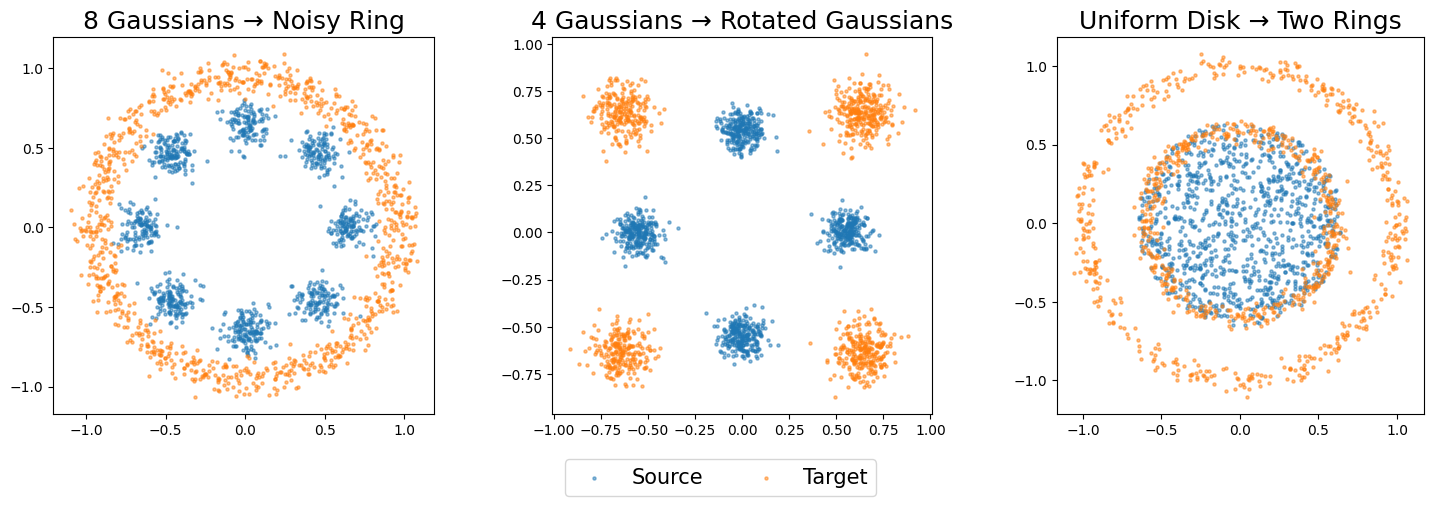

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#plot data visualization

m_plot = 1000
n_plot = 1000

#dataset 1
X1_plot, Y1_plot = make_large_ot_problem(m=m_plot, n=n_plot, device=device, dtype=dtype, seed=1337)

#dataset 2
X2_plot, Y2_plot = make_gaussian_to_rotated_gaussian(m=m_plot, n=n_plot, device=device, dtype=dtype, seed=1984)

#dataset 3
X3_plot, Y3_plot = make_disk_to_two_rings(m=m_plot, n=n_plot, device=device, dtype=dtype, seed=451)

#CPU
datasets_plot = [(X1_plot.cpu().numpy(), Y1_plot.cpu().numpy(),"8 Gaussians → Noisy Ring"),
 (X2_plot.cpu().numpy(), Y2_plot.cpu().numpy(), "4 Gaussians → Rotated Gaussians"),
 (X3_plot.cpu().numpy(),Y3_plot.cpu().numpy(), "Uniform Disk → Two Rings")]

#plot figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (X_plot, Y_plot, title) in zip(axes, datasets_plot):

    ax.scatter(X_plot[:, 0], X_plot[:, 1], s=5, alpha=0.5, label="Source")
    ax.scatter(Y_plot[:, 0], Y_plot[:, 1], s=5, alpha=0.5, label="Target")

    ax.set_title(title, fontsize=18)
    ax.set_aspect("equal", adjustable="box")

#shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles,labels, loc="lower center", ncol=2, fontsize=15,
           bbox_to_anchor=(0.5, 0.01),)

plt.tight_layout(rect=[0, 0.15, 1, 1])
plt.show()

filename = 'app_minibatch_data_visualization.pdf'
fig.savefig(filename, format='pdf', bbox_inches='tight')
files.download(filename)


### Experiment

In [ ]:
#repeat experiment 5 times for each dataset
n_runs = 5
threshold_additional = 1e-2
max_epochs_additional = 20

#different seeds for SSS shuffling
run_seeds = list(range(1337, 1342))

#hyperparameters
DEBUG = False

if DEBUG:
    m = 1024
    n = 100_000
    batch_size = 8192
else:
    #actual
    m = 1024
    n = 4_500_000
    batch_size = 8192
reg = 0.1
dtype = torch.float32

dataset_specs = [{"name": "8 Gaussians -> Noisy Ring",
                  "generator": make_large_ot_problem,
                  "data_seed": 1337},
                 {"name": "4 Gaussians -> Rotated 4 Gaussians",
                  "generator": make_gaussian_to_rotated_gaussian,
                  "data_seed": 1984},
                 {"name": "Uniform Disk -> Two Rings",
                  "generator": make_disk_to_two_rings,
                  "data_seed": 451}]

all_trial_results = []
summary_results = []

for dataset_spec in dataset_specs:

    dataset_name = dataset_spec["name"]

    print("\n" + "=" * 70)
    print("DATASET:", dataset_name)
    print("=" * 70)

    #generate dataset once!
    X_exp, Y_exp = dataset_spec["generator"](m=m, n=n, device=device, dtype=dtype,
                                             seed=dataset_spec["data_seed"])

    print("X shape:", X_exp.shape)
    print("Y shape:", Y_exp.shape)

    #initialize
    u_init, v_init, Kv_init = initialize_scalings_GPU(X_exp, Y_exp, reg=reg,
                                                      batch_size=batch_size)

    torch.cuda.synchronize()

    #error function for dataset
    def compute_error_exp(u, v):
        return marginal_error_GPU(X_exp, Y_exp, u, v, reg=reg, batch_size=batch_size)

    #warm up GPU
    K_warm = kernel_block(X_exp, Y_exp[:batch_size], reg)
    _ = K_warm.T @ u_init

    torch.cuda.synchronize()

    del K_warm
    torch.cuda.empty_cache()

    #run both methods 5 times
    method_times = {"Sinkhorn": [], "SSS": [], "SSS cyclic": []}

    for run_idx, run_seed in enumerate(run_seeds, start=1):

        print("\n" + "-" * 60)
        print(f"{dataset_name}: run {run_idx}/{n_runs}")
        print("-" * 60)

        #Sinkhorn
        gc.collect()
        torch.cuda.empty_cache()

        print("\nRunning Sinkhorn...")

        sinkhorn_result = sinkhorn_GPU_until_error(X=X_exp, Y=Y_exp, u_init=u_init,
                                                   v_init=v_init, reg=reg,
                                                   batch_size=batch_size,
                                                   error_fn=compute_error_exp,
                                                   threshold=threshold_additional,
                                                   max_iterations=max_epochs_additional)

        sinkhorn_time = sinkhorn_result["time_to_threshold"]
        method_times["Sinkhorn"].append(sinkhorn_time)

        all_trial_results.append({"Dataset": dataset_name,
                                  "Method": "Sinkhorn",
                                  "Run": run_idx,
                                  "Seed": None,
                                  "Reached threshold": sinkhorn_result["reached_threshold"],
                                  "Time to threshold (s)": sinkhorn_time,
                                  "Final L1 error": sinkhorn_result["final_error"],
                                  "Iterations/Epochs": len(sinkhorn_result["history"]),
                                  "Block updates": sinkhorn_result["block_updates"]})

        print("Sinkhorn time to threshold:", sinkhorn_time)

        del sinkhorn_result

        gc.collect()
        torch.cuda.empty_cache()

        #SSS
        print("\nRunning SSS...")

        sss_result = SSS_GPU_until_error(X=X_exp, Y=Y_exp, u_init=u_init,
                                         v_init=v_init, Kv_init=Kv_init, reg=reg,
                                         batch_size=batch_size, error_fn=compute_error_exp,
                                         threshold=threshold_additional,
                                         max_epochs=max_epochs_additional,
                                         seed=run_seed, sampling='random')

        sss_time = sss_result["time_to_threshold"]

        method_times["SSS"].append(sss_time)

        all_trial_results.append({"Dataset": dataset_name, "Method": "SSS",
                                  "Run": run_idx, "Seed": run_seed,
                                  "Reached threshold": sss_result["reached_threshold"],
                                  "Time to threshold (s)": sss_time,
                                  "Final L1 error": sss_result["final_error"],
                                  "Iterations/Epochs": len(sss_result["history"]),
                                  "Block updates": sss_result["block_updates"]})

        print("SSS time to threshold:", sss_time)

        del sss_result

        gc.collect()
        torch.cuda.empty_cache()

        #SSS cyclic
        print("\nRunning SSS cyclic...")

        sss_cyclic_result = SSS_GPU_until_error(X=X_exp, Y=Y_exp, u_init=u_init,
                                                v_init=v_init, Kv_init=Kv_init, reg=reg,
                                                batch_size=batch_size, error_fn=compute_error_exp,
                                                threshold=threshold_additional,
                                                max_epochs=max_epochs_additional,
                                                seed=run_seed, sampling='cyclic')

        sss_cyclic_time = sss_cyclic_result["time_to_threshold"]

        method_times["SSS cyclic"].append(sss_cyclic_time)

        all_trial_results.append({"Dataset": dataset_name, "Method": "SSS cyclic",
                                  "Run": run_idx, "Seed": run_seed,
                                  "Reached threshold": sss_cyclic_result["reached_threshold"],
                                  "Time to threshold (s)": sss_cyclic_time,
                                  "Final L1 error": sss_cyclic_result["final_error"],
                                  "Iterations/Epochs": len(sss_cyclic_result["history"]),
                                  "Block updates": sss_cyclic_result["block_updates"]})

        print("SSS cyclic time to threshold:", sss_cyclic_time)

        del sss_cyclic_result

        gc.collect()
        torch.cuda.empty_cache()


    #compute statistics
    for method_name, times in method_times.items():
        times = np.asarray(times, dtype=float)
        valid_times = times[np.isfinite(times)]
        num_successful = len(valid_times)

        if num_successful > 0:
            mean_time = np.mean(valid_times)
        else:
            mean_time = np.nan

        if num_successful > 1:
            std_time = np.std(valid_times, ddof=1)
        else:
            std_time = np.nan

        summary_results.append({"Dataset": dataset_name, "Method": method_name,
                                "Successful runs": f"{num_successful}/{n_runs}",
                                "Mean time to L1 <= 1e-2 (s)": mean_time,
                                "Std time (s)": std_time})

    del X_exp
    del Y_exp
    del u_init
    del v_init
    del Kv_init

    gc.collect()
    torch.cuda.empty_cache()


DATASET: 8 Gaussians -> Noisy Ring
X shape: torch.Size([1024, 2])
Y shape: torch.Size([4500000, 2])

------------------------------------------------------------
8 Gaussians -> Noisy Ring: run 1/5
------------------------------------------------------------

Running Sinkhorn...
Sinkhorn | iter  1 | time 2.24s | error 4.258e-02
Sinkhorn | iter  2 | time 4.48s | error 3.491e-02
Sinkhorn | iter  3 | time 6.72s | error 3.112e-02
Sinkhorn | iter  4 | time 8.95s | error 2.810e-02
Sinkhorn | iter  5 | time 11.19s | error 2.556e-02
Sinkhorn | iter  6 | time 13.43s | error 2.333e-02
Sinkhorn | iter  7 | time 15.66s | error 2.134e-02
Sinkhorn | iter  8 | time 17.90s | error 1.954e-02
Sinkhorn | iter  9 | time 20.14s | error 1.790e-02
Sinkhorn | iter 10 | time 22.37s | error 1.641e-02
Sinkhorn | iter 11 | time 24.61s | error 1.504e-02
Sinkhorn | iter 12 | time 26.84s | error 1.379e-02
Sinkhorn | iter 13 | time 29.07s | error 1.265e-02
Sinkhorn | iter 14 | time 31.31s | error 1.160e-02
Sinkhorn |

In [ ]:
#table for easy reference
additional_trials_df = pd.DataFrame(all_trial_results)
additional_summary_df = pd.DataFrame(summary_results)
additional_summary_df["Mean ± Std (s)"] = (additional_summary_df[
        "Mean time to L1 <= 1e-2 (s)"
    ].map(lambda x: f"{x:.3f}")
    + " ± "
    + additional_summary_df[
        "Std time (s)"
    ].map(lambda x: f"{x:.3f}"))

additional_summary_df

,Dataset,Method,Successful runs,Mean time to L1 <= 1e-2 (s),Std time (s),Mean ± Std (s)
0,8 Gaussians -> Noisy Ring,Sinkhorn,5/5,35.714910,0.033511,35.715 ± 0.034
1,8 Gaussians -> Noisy Ring,SSS,5/5,20.286486,0.005150,20.286 ± 0.005
2,8 Gaussians -> Noisy Ring,SSS cyclic,5/5,10.741973,0.000748,10.742 ± 0.001
3,4 Gaussians -> Rotated 4 Gaussians,Sinkhorn,5/5,4.466142,0.000334,4.466 ± 0.000
4,4 Gaussians -> Rotated 4 Gaussians,SSS,5/5,6.211364,0.533703,6.211 ± 0.534
5,4 Gaussians -> Rotated 4 Gaussians,SSS cyclic,5/5,2.389657,0.000329,2.390 ± 0.000
6,Uniform Disk -> Two Rings,Sinkhorn,5/5,13.392396,0.001317,13.392 ± 0.001
7,Uniform Disk -> Two Rings,SSS,5/5,8.597553,0.530251,8.598 ± 0.530
8,Uniform Disk -> Two Rings,SSS cyclic,5/5,3.583596,0.000225,3.584 ± 0.000


# Appendix Extra Experiments

## (1) Varying $n/m$

### CPU

In [ ]:
#if running this independently, run the following:
#Comparisons with Sinkhorn baselines > 2D EOT data > Functions

datasets = {'moons_gaussian_grid': 'Moons → Gaussian grid',
            'gaussian_swiss_roll': 'Gaussian → Swiss roll',
            'circles_checkerboard': 'Circles → Checkerboard'}

seeds = list(range(1337, 1342))

m = 10
n_values = [10, 100, 1000, 10000, 100000]
reg = 1e-2
gamma0 = 1.0

budget = int(1e7)
record_cost_every = int(2e6)

method_labels = {'sss': 'SSS', 'sss_cyclic': 'SSS cyclic', 'sinkhorn': 'Sinkhorn',
                 'stochastic_sinkhorn': 'Stochastic Sinkhorn', 'greenkhorn': 'Greenkhorn'}


#run experiment
raw_results = []

for dataset, dataset_title in datasets.items():

    print("\n" + "=" * 70)
    print(dataset_title)
    print("=" * 70)

    for n in n_values:

        print(f"\nm = {m}, n = {n}")

        for seed in tqdm(seeds, desc=f"{dataset_title}, n={n}"):
            sources, targets = generate_2d_pairs(dataset=dataset, num_pairs=1, m=m,
                                                 n=n, seed=seed)

            source = sources[0]
            target = targets[0]

            #run solvers
            solver_results = run_solvers_2d_timed(source=source, target=target,
                                                  reg=reg, gamma0=gamma0,
                                                  budget=budget,
                                                  record_cost_every=record_cost_every,
                                                  seed=seed)

            for method, result in solver_results.items():

                final_error = result['error'][-1]

                raw_results.append({'Dataset': dataset_title, 'm': m, 'n': n,
                                    'Method': method_labels[method],
                                    'Seed': seed, 'Final L1 error': final_error})


Moons → Gaussian grid

m = 10, n = 10


Moons → Gaussian grid, n=10:   0%|          | 0/5 [00:00<?, ?it/s]


m = 10, n = 100


Moons → Gaussian grid, n=100:   0%|          | 0/5 [00:00<?, ?it/s]


m = 10, n = 1000


...

Circles → Checkerboard, n=1000:   0%|          | 0/5 [00:00<?, ?it/s]


m = 10, n = 10000


Circles → Checkerboard, n=10000:   0%|          | 0/5 [00:00<?, ?it/s]


m = 10, n = 100000


Circles → Checkerboard, n=100000:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
raw_df = pd.DataFrame(raw_results)
summary_df = (
    raw_df
    .groupby(
        ['Dataset', 'm', 'n', 'Method'],
        as_index=False
    )
    .agg(
        mean_final_L1=('Final L1 error', 'mean'),
        std_final_L1=('Final L1 error', 'std')
    )
)

summary_df['Mean ± Std'] = summary_df.apply(
    lambda row:
        f"{row['mean_final_L1']:.3e} ± {row['std_final_L1']:.3e}",
    axis=1
)

summary_df[
    ['Dataset', 'm', 'n', 'Method', 'Mean ± Std']
]

,Dataset,m,n,Method,Mean ± Std
0,Circles → Checkerboard,10,10,Greenkhorn,1.329e-07 ± 2.972e-07
1,Circles → Checkerboard,10,10,SSS,6.963e-09 ± 1.551e-08
2,Circles → Checkerboard,10,10,SSS cyclic,2.643e-09 ± 5.891e-09
3,Circles → Checkerboard,10,10,Sinkhorn,2.390e-07 ± 5.345e-07
4,Circles → Checkerboard,10,10,Stochastic Sinkhorn,1.664e-06 ± 3.721e-06
...,...,...,...,...,...
70,Moons → Gaussian grid,10,100000,Greenkhorn,6.223e-01 ± 1.717e-02
71,Moons → Gaussian grid,10,100000,SSS,1.941e-01 ± 9.428e-03
72,Moons → Gaussian grid,10,100000,SSS cyclic,4.938e-02 ± 7.157e-03
73,Moons → Gaussian grid,10,100000,Sinkhorn,3.112e-01 ± 1.323e-02


## (2) Minibatch ablation

In [ ]:
#if running this independently, run the following:
#(3) SSS minibatch > Preliminaries; (3) SSS minibatch > Additional experiments > Functions

device = 'cuda'
dtype = torch.float32

m = 1024
n = 4_500_000
reg = 0.1

threshold = 1e-2

batch_sizes = [1024, 2048, 4096, 8192, 16384, 32768, 65536]
num_runs = 5
run_seeds = [1337, 1338, 1339, 1340, 1341, 1342]

#constant error evaluation across all b, so that computation of marginal error is consistent
error_batch_size = 8192

#constant fixed block for initialization
init_batch_size = 8192

max_epochs = 50

dataset_specs = {'8 Gaussians -> Noisy Ring': {'generator': make_large_ot_problem,
                                               'seed': 1337},
                 '4 Gaussians -> Rotated 4 Gaussians': {'generator': make_gaussian_to_rotated_gaussian,
                                                        'seed': 1984},
                 'Uniform Disk -> Two Rings': {'generator': make_disk_to_two_rings,
                                               'seed': 451}}

#run ablation for one dataset
def run_batch_ablation_for_dataset(dataset_name, generator_fn, data_seed,):
    print('\n' + '=' * 80)
    print(f'DATASET: {dataset_name}')
    print('=' * 80)

    #generate dataset
    X, Y = generator_fn(m=m, n=n, device=device, dtype=dtype, seed=data_seed,)

    u0, v0, Kv0 = initialize_scalings_GPU(X=X, Y=Y, reg=reg, batch_size=init_batch_size)

    def compute_error_fixed(u, v):
        return marginal_error_GPU(X=X, Y=Y, u=u, v=v, reg=reg, batch_size=error_batch_size)

    rows = []

    for batch_size in batch_sizes:

        print('\n' + '-' * 80)
        print(f'Batch size b = {batch_size}')
        print('-' * 80)

        for run_idx in range(num_runs):

            run_seed = run_seeds[run_idx]

            print(
                f'\nDataset: {dataset_name} | '
                f'b={batch_size} | '
                f'run={run_idx + 1}/{num_runs}'
            )

            #SSS
            sss_result = SSS_GPU_until_error(X=X, Y=Y, u_init=u0, v_init=v0, Kv_init=Kv0,
                                             reg=reg, batch_size=batch_size,
                                             error_fn=compute_error_fixed,
                                             threshold=threshold, max_epochs=max_epochs,
                                             seed=run_seed, sampling='random')

            rows.append({'Dataset': dataset_name, 'Batch size': batch_size,
                         'Run': run_idx, 'Seed': np.nan,'Reached threshold': sss_result['reached_threshold'],
                         'Time to threshold (s)': sss_result['time_to_threshold'],
                         'Final error': sss_result['final_error'],
                         'Block updates': sss_result['block_updates'],
                         'Avg block time (ms)': 1000.0 * sss_result['avg_block_time'],
                         'Epochs': len(sss_result['history']), 'Method': 'SSS'})

            del sss_result

            #SSS cyclic
            sss_cyclic_result = SSS_GPU_until_error(X=X, Y=Y, u_init=u0, v_init=v0, Kv_init=Kv0,
                                                    reg=reg, batch_size=batch_size,
                                                    error_fn=compute_error_fixed,
                                                    threshold=threshold, max_epochs=max_epochs,
                                                    seed=run_seed, sampling='cyclic')

            rows.append({'Dataset': dataset_name, 'Batch size': batch_size,
                         'Run': run_idx, 'Seed': np.nan,
                         'Reached threshold': sss_cyclic_result['reached_threshold'],
                         'Time to threshold (s)': sss_cyclic_result['time_to_threshold'],
                         'Final error': sss_cyclic_result['final_error'],
                         'Block updates': sss_cyclic_result['block_updates'],
                         'Avg block time (ms)': 1000.0 * sss_cyclic_result['avg_block_time'],
                         'Epochs': len(sss_cyclic_result['history']), 'Method': 'SSS cyclic'})

            del sss_cyclic_result

            #block Sinkhorn
            sinkhorn_result = sinkhorn_GPU_until_error(X=X, Y=Y, u_init=u0, v_init=v0,
                                                       reg=reg, batch_size=batch_size,
                                                       error_fn=compute_error_fixed,
                                                       threshold=threshold,
                                                       max_iterations=max_epochs)

            rows.append({'Dataset': dataset_name, 'Batch size': batch_size,
                          'Run': run_idx, 'Seed': run_seed,
                          'Reached threshold': sinkhorn_result['reached_threshold'],
                          'Time to threshold (s)': sinkhorn_result['time_to_threshold'],
                          'Final error': sinkhorn_result['final_error'],
                          'Block updates': sinkhorn_result['block_updates'],
                          'Avg block time (ms)': 1000.0 * sinkhorn_result['avg_block_time'],
                          'Epochs': len(sinkhorn_result['history']),})

            del sinkhorn_result

    del X, Y, u0, v0, Kv0

    gc.collect()
    torch.cuda.empty_cache()

    return rows


#run for all datasets
all_rows = []

for dataset_name, spec in dataset_specs.items():
    rows = run_batch_ablation_for_dataset(dataset_name=dataset_name, generator_fn=spec['generator'],
                                          data_seed=spec['seed'])
    all_rows.extend(rows)


batch_ablation_df = pd.DataFrame(all_rows)

batch_ablation_df


DATASET: 8 Gaussians -> Noisy Ring

--------------------------------------------------------------------------------
Batch size b = 1024
--------------------------------------------------------------------------------

Dataset: 8 Gaussians -> Noisy Ring | b=1024 | run=1/5
SSS random  | epoch  1 | time 2.66s | error 1.250e-01
SSS random  | epoch  2 | time 4.99s | error 6.366e-02
SSS random  | epoch  3 | time 6.71s | error 4.089e-02
SSS random  | epoch  4 | time 8.45s | error 3.188e-02
SSS random  | epoch  5 | time 10.21s | error 2.722e-02
SSS random  | epoch  6 | time 12.60s | error 2.422e-02
SSS random  | epoch  7 | time 14.37s | error 2.207e-02
SSS random  | epoch  8 | time 16.10s | error 2.014e-02
SSS random  | epoch  9 | time 17.85s | error 1.844e-02
SSS random  | epoch 10 | time 20.20s | error 1.694e-02
SSS random  | epoch 11 | time 21.94s | error 1.561e-02
SSS random  | epoch 12 | time 23.70s | error 1.437e-02
SSS random  | epoch 13 | time 25.42s | error 1.318e-02
SSS random  | e

,Dataset,Batch size,Run,Seed,Reached threshold,Time to threshold (s),Final error,Block updates,Avg block time (ms),Epochs,Method
0,8 Gaussians -> Noisy Ring,1024,0,NaN,True,33.023115,0.009476,74715,0.441988,17,SSS
1,8 Gaussians -> Noisy Ring,1024,0,NaN,True,17.502503,0.008639,39555,0.442485,9,SSS cyclic
2,8 Gaussians -> Noisy Ring,1024,0,1337.0,True,37.854333,0.009758,140640,0.269158,16,NaN
3,8 Gaussians -> Noisy Ring,1024,1,NaN,True,31.357654,0.009564,74715,0.419697,17,SSS
4,8 Gaussians -> Noisy Ring,1024,1,NaN,True,17.091678,0.008644,39555,0.432099,9,SSS cyclic
...,...,...,...,...,...,...,...,...,...,...,...
310,Uniform Disk -> Two Rings,65536,3,NaN,True,3.464121,0.009631,207,16.734883,3,SSS cyclic
311,Uniform Disk -> Two Rings,65536,3,1340.0,True,13.025763,0.008735,828,15.731598,6,NaN
312,Uniform Disk -> Two Rings,65536,4,NaN,True,8.103588,0.009483,483,16.777616,7,SSS
313,Uniform Disk -> Two Rings,65536,4,NaN,True,3.463954,0.009639,207,16.734079,3,SSS cyclic


In [ ]:
#summary table
summary_df = (batch_ablation_df.groupby(['Dataset', 'Method', 'Batch size'], as_index=False).agg(
    mean_time=('Time to threshold (s)', 'mean'),
    std_time=('Time to threshold (s)', 'std'),
    mean_error=('Final error', 'mean'),
    std_error=('Final error', 'std'),
    success_rate=('Reached threshold', 'mean'),
    mean_iterations=('Epochs', 'mean'),
    mean_block_time_ms=('Avg block time (ms)', 'mean')))

summary_df['success_rate'] *= 100
summary_df

,Dataset,Method,Batch size,mean_time,std_time,mean_error,std_error,success_rate,mean_iterations,mean_block_time_ms
0,4 Gaussians -> Rotated 4 Gaussians,SSS,1024,9.056276,0.139427,0.007615,7.478212e-04,100.0,5.0,0.412117
1,4 Gaussians -> Rotated 4 Gaussians,SSS,2048,6.425235,0.002877,0.007997,1.125102e-03,100.0,5.0,0.584644
2,4 Gaussians -> Rotated 4 Gaussians,SSS,4096,6.129244,0.001212,0.007578,1.245227e-03,100.0,5.0,1.115422
3,4 Gaussians -> Rotated 4 Gaussians,SSS,8192,6.203442,0.533623,0.007278,1.395030e-03,100.0,5.2,2.169033
4,4 Gaussians -> Rotated 4 Gaussians,SSS,16384,5.907878,0.002734,0.007604,1.652831e-03,100.0,5.0,4.296639
5,4 Gaussians -> Rotated 4 Gaussians,SSS,32768,5.338089,1.041654,0.006909,2.455082e-03,100.0,4.6,8.408232
6,4 Gaussians -> Rotated 4 Gaussians,SSS,65536,5.314019,0.630589,0.004752,7.678926e-04,100.0,4.6,16.743039
7,4 Gaussians -> Rotated 4 Gaussians,SSS cyclic,1024,3.712338,0.196524,0.005593,1.723955e-05,100.0,2.0,0.422337
8,4 Gaussians -> Rotated 4 Gaussians,SSS cyclic,2048,2.571090,0.001539,0.005617,1.697497e-05,100.0,2.0,0.584870
9,4 Gaussians -> Rotated 4 Gaussians,SSS cyclic,4096,2.451880,0.000749,0.005605,2.259341e-05,100.0,2.0,1.115505


"\nfilename = 'app_minibatch_ablation.pdf'\nfig.savefig(filename, format='pdf', bbox_inches='tight')\nfiles.download(filename)\n"

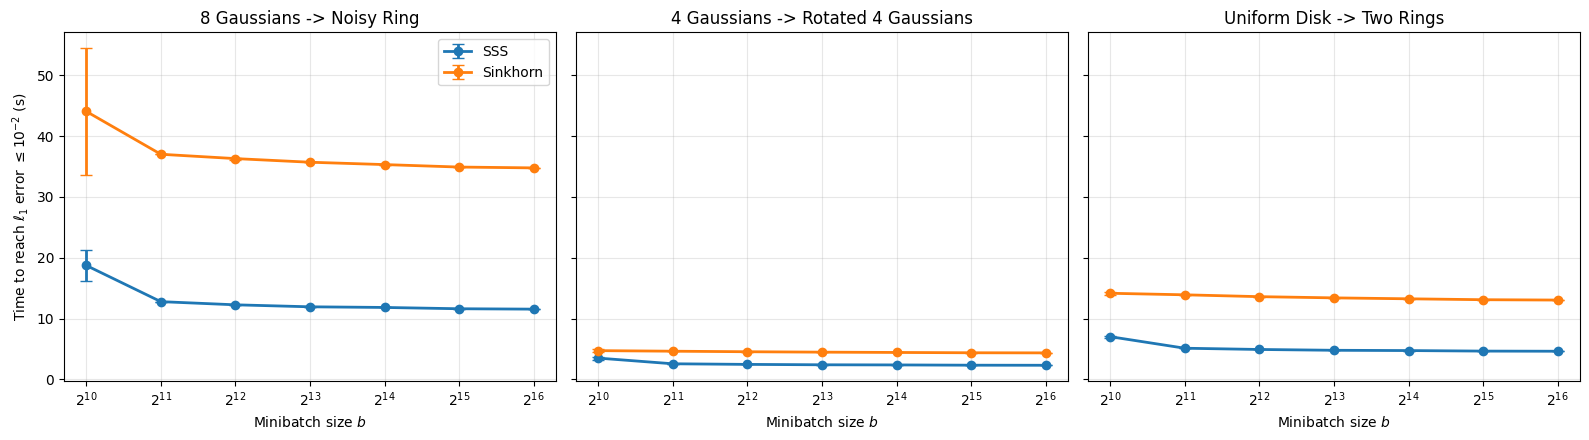

In [ ]:
#plot mean time to threshold
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, dataset_name in zip(axes, dataset_specs.keys()):
    for method in ['SSS', 'Sinkhorn']:
        sub = summary_df[(summary_df['Dataset'] == dataset_name)
        & (summary_df['Method'] == method)].sort_values('Batch size')

        ax.errorbar(sub['Batch size'], sub['mean_time'], yerr=sub['std_time'],
                    marker='o', capsize=4, linewidth=2, label=method)

    ax.set_xscale('log', base=2)
    ax.set_title(dataset_name)
    ax.set_xlabel('Minibatch size $b$')

    ax.grid(alpha=0.3)

axes[0].set_ylabel(r'Time to reach $\ell_1$ error $\leq 10^{-2}$ (s)')
axes[0].legend()

plt.tight_layout()

'''
filename = 'app_minibatch_ablation.pdf'
fig.savefig(filename, format='pdf', bbox_inches='tight')
files.download(filename)
'''

## (3) Comparisons with Semi-dual schemes

### CPU

#### Functions

In [ ]:
'''
Code for the semi-dual algorithms is obtained from POT library:
https://pythonot.github.io/

We adapt the code for SAG and ASGD to suit our experimental settings
'''

def coordinate_grad_semi_dual_stable(b, M, reg, beta, i):
    b = np.asarray(b, dtype=np.float64)
    beta = np.asarray(beta, dtype=np.float64)

    logits = np.log(b) + (beta - M[i, :]) / reg
    logits -= logsumexp(logits)

    chi = np.exp(logits)

    return b - chi

#recover alpha from beta using the entropic c-transform
def c_transform_entropic_stable(b, M, reg, beta):
    b = np.asarray(b, dtype=np.float64)
    beta = np.asarray(beta, dtype=np.float64)

    logits = (np.log(b)[None, :] + (beta[None, :] - M) / reg)

    alpha = -reg * logsumexp(logits, axis=1)

    return alpha

#error function
def semi_dual_marginal_error(a, b, M, reg, beta):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    alpha = c_transform_entropic_stable(b=b, M=M, reg=reg, beta=beta)

    log_pi = (np.log(a)[:, None] + np.log(b)[None, :] + (alpha[:, None] + beta[None, :] - M) / reg)

    row_marginal = np.exp(logsumexp(log_pi, axis=1))
    col_marginal = np.exp(logsumexp(log_pi, axis=0))

    error = (np.sum(np.abs(row_marginal - a)) + np.sum(np.abs(col_marginal - b)))

    return float(error), alpha


def _semi_dual_timing_result(beta, alpha, error_history, cost_history,
                             update_time_history, iteration_history,
                             update_time, num_iterations, lr):
    return {'alpha': alpha, 'beta': beta, 'error': error_history,
            'cost': cost_history, 'update_time_history': update_time_history,
            'iteration_history': iteration_history, 'update_time': update_time,
            'num_iterations': num_iterations, 'lr': lr}


#averaged SGD
def averaged_sgd_entropic_transport_timed(a, b, M, reg, budget, numItermax=int(1e8),
                                          lr=None, random_state=None, tol=None,
                                          record_cost_every=int(1e5)):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    M = np.asarray(M, dtype=np.float64)

    n_source, n_target = M.shape

    if lr is None:
        lr = 1.0 / np.max(a / reg)

    cur_beta = np.zeros(n_target, dtype=np.float64)
    ave_beta = np.zeros(n_target, dtype=np.float64)

    rng = np.random.RandomState(random_state)

    #one semi-dual gradient evaluates one row of M
    update_cost = n_target

    cost = 0
    num_iterations = 0

    error0, _ = semi_dual_marginal_error(a, b, M, reg, ave_beta)

    error_history = [error0]
    cost_history = [0]
    update_time_history = [0.0]
    iteration_history = [0]

    update_time = 0.0
    next_record_cost = record_cost_every

    chunk_start = time.perf_counter()

    for cur_iter in range(numItermax):

        if (budget is not None and cost + update_cost > budget):
            break

        k = cur_iter + 1

        i = rng.randint(n_source)

        cur_grad = coordinate_grad_semi_dual_stable(b=b, M=M, reg=reg, beta=cur_beta, i=i)

        #ASGD update
        cur_beta += (lr * (1.0 / n_source) / np.sqrt(k)) * cur_grad
        ave_beta += (cur_beta - ave_beta) / k

        cost += update_cost
        num_iterations += 1

        if cost >= next_record_cost:
            update_time += (time.perf_counter() - chunk_start)

            error, _ = semi_dual_marginal_error(a, b, M, reg, ave_beta)

            error_history.append(error)
            cost_history.append(cost)
            update_time_history.append(update_time)
            iteration_history.append(num_iterations)

            while next_record_cost <= cost:
                next_record_cost += record_cost_every

            if tol is not None and error <= tol:
                break

            chunk_start = time.perf_counter()

    #final checkpoint
    if cost_history[-1] != cost:

        update_time += (time.perf_counter() - chunk_start)

        error, _ = semi_dual_marginal_error(a, b, M, reg, ave_beta)

        error_history.append(error)
        cost_history.append(cost)
        update_time_history.append(update_time)
        iteration_history.append(num_iterations)

    final_error, final_alpha = (semi_dual_marginal_error(a, b, M, reg, ave_beta))

    error_history[-1] = final_error

    return _semi_dual_timing_result(beta=ave_beta, alpha=final_alpha, error_history=error_history,
                                    cost_history=cost_history, update_time_history=update_time_history,
                                    iteration_history=iteration_history, update_time=update_time,
                                    num_iterations=num_iterations, lr=lr)


#SAG
def sag_entropic_transport_timed(a, b, M, reg, budget, numItermax=int(1e8),
                                 lr=None, random_state=None, tol=None,
                                 record_cost_every=int(1e5)):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    M = np.asarray(M, dtype=np.float64)

    n_source, n_target = M.shape

    if lr is None:
        lr = 1.0 / np.max(a / reg)

    beta = np.zeros(n_target, dtype=np.float64)

    stored_gradient = np.zeros((n_source, n_target),dtype=np.float64)
    sum_stored_gradient = np.zeros(n_target, dtype=np.float64)

    rng = np.random.RandomState(random_state)

    update_cost = n_target

    cost = 0
    num_iterations = 0

    error0, _ = semi_dual_marginal_error(a, b, M, reg, beta)

    error_history = [error0]
    cost_history = [0]
    update_time_history = [0.0]
    iteration_history = [0]

    update_time = 0.0
    next_record_cost = record_cost_every

    chunk_start = time.perf_counter()

    for _ in range(numItermax):
        if (budget is not None and cost + update_cost > budget):
            break

        i = rng.randint(n_source)

        cur_grad = (a[i] * coordinate_grad_semi_dual_stable(b=b, M=M, reg=reg,
                                                            beta=beta, i=i))

        #replace stale gradient
        sum_stored_gradient += (cur_grad - stored_gradient[i])

        stored_gradient[i] = cur_grad

        #POT SAG update
        beta += (lr * (1.0 / n_source) * sum_stored_gradient)

        cost += update_cost
        num_iterations += 1

        if cost >= next_record_cost:
            update_time += (time.perf_counter() - chunk_start)

            error, _ = semi_dual_marginal_error(a, b, M, reg, beta)

            error_history.append(error)
            cost_history.append(cost)
            update_time_history.append(update_time)
            iteration_history.append(num_iterations)

            while next_record_cost <= cost:
                next_record_cost += record_cost_every

            if tol is not None and error <= tol:
                break

            chunk_start = time.perf_counter()

    #final checkpoint
    if cost_history[-1] != cost:
        update_time += ( time.perf_counter() - chunk_start)

        error, _ = semi_dual_marginal_error(a, b, M, reg, beta)

        error_history.append(error)
        cost_history.append(cost)
        update_time_history.append(update_time)
        iteration_history.append(num_iterations)

    final_error, final_alpha = (semi_dual_marginal_error(a, b, M, reg, beta))

    error_history[-1] = final_error

    return _semi_dual_timing_result(beta=beta, alpha=final_alpha, error_history=error_history,
                                    cost_history=cost_history, update_time_history=update_time_history,
                                    iteration_history=iteration_history, update_time=update_time,
                                    num_iterations=num_iterations, lr=lr)

    #trainer to run all 5 methods: SSS shuffling, SSS cyclic, SSS
def run_semidual_cpu_solvers(source, target, reg=1e-2, gamma0=1.0, budget=int(1e7),
                             tol=None, max_iter=10_000_000, record_cost_every=int(2e5),
                             seed=1337,):

    #common EOT problem
    a, b, C = prepare_ot_problem(source, target)

    m = len(a)
    n = len(b)

    K = np.exp(-C / reg)

    gamma = gamma0 / n

    results = {}

    #SSS with replacement
    results['sss'] = sss_timed(a, b, K, gamma=gamma, sampling='random', max_iter=max_iter,
                               tol=tol, budget=budget, seed=seed, record_cost_every=record_cost_every)

    #SSS random shuffling
    results['sss_shuffle'] = sss_timed(a, b, K, gamma=gamma, sampling='shuffle', max_iter=max_iter,
                                       tol=tol, budget=budget, seed=seed, record_cost_every=record_cost_every)

    #SSS cyclic
    results['sss_cyclic'] = sss_timed(a, b, K, gamma=gamma, sampling='cyclic', max_iter=max_iter,
                                     tol=tol, budget=budget, seed=seed, record_cost_every=record_cost_every)



    #transpose the original problem for semi-dual methods
    M_sd = C.T

    a_sd = b.copy()
    b_sd = a.copy()

    # SAG
    results['sag'] = sag_entropic_transport_timed(a=a_sd, b=b_sd, M=M_sd, reg=reg, budget=budget,
                                                  numItermax=max_iter, lr=None, random_state=seed,
                                                  tol=tol, record_cost_every=record_cost_every)

    #ASGD
    results['sgd'] = averaged_sgd_entropic_transport_timed(a=a_sd, b=b_sd, M=M_sd, reg=reg,
                                                           budget=budget, numItermax=max_iter,
                                                           lr=None, random_state=seed, tol=tol,
                                                           record_cost_every=record_cost_every)

    return results

#### Experiment

In [ ]:
#if running this independently, run the following cells
#timed solvers: Comparisons with baselines > 2D EOT> Additional experiments > Repeat experiment 5 more times > Solvers
#data functions: Comparisons with baselines > 2D EOT> Functions

#run experiment
datasets_semidual = {'moons_gaussian_grid': 'Moons → Gaussian grid',
                     'gaussian_swiss_roll': 'Gaussian → Swiss roll',
                     'circles_checkerboard': 'Circles → Checkerboard'}

# three independent runs
seeds_semidual = [1337, 1338, 1339,]

m_semidual = 50
n_semidual = 10000

reg_semidual = 1e-2
gamma0_semidual = 1.0

budget_semidual = int(1e7)

#approximately 50 diagnostic points
record_cost_every = int(2e5)

semidual_cpu_results = {}
semidual_rows = []

for dataset, dataset_title in datasets_semidual.items():

    semidual_cpu_results[dataset] = {}

    print('\n' + '=' * 70)
    print(dataset_title)
    print('=' * 70)

    for seed in tqdm(seeds_semidual, desc=dataset_title):

        #one data instance per seed
        sources, targets = generate_2d_pairs(dataset=dataset, num_pairs=1, m=m_semidual,
                                             n=n_semidual, seed=seed,)

        source = sources[0]
        target = targets[0]

        #run all methods
        solver_results = run_semidual_cpu_solvers(source=source, target=target,
                                                  reg=reg_semidual, gamma0=gamma0_semidual,
                                                  budget=budget_semidual, tol=None,
                                                  max_iter=10_000_000,
                                                  record_cost_every=record_cost_every,
                                                  seed=seed)

        semidual_cpu_results[dataset][seed] = {'source': source,'target': target,
                                               'solvers': solver_results}

        #summary statistics

        for method, result in solver_results.items():
            semidual_rows.append({'Dataset': dataset_title, 'Seed': seed,'Method': method,
                                  'Final L1 error': result['error'][-1],
                                  'Coordinate updates': result['num_iterations'],
                                  'Final computational cost': result['cost'][-1],
                                  'Update time (s)': result['update_time']})

semidual_raw_df = pd.DataFrame(semidual_rows)
semidual_raw_df


Moons → Gaussian grid


Moons → Gaussian grid:   0%|          | 0/3 [00:00<?, ?it/s]


Gaussian → Swiss roll


Gaussian → Swiss roll:   0%|          | 0/3 [00:00<?, ?it/s]


Circles → Checkerboard


Circles → Checkerboard:   0%|          | 0/3 [00:00<?, ?it/s]

,Dataset,Seed,Method,Final L1 error,Coordinate updates,Final computational cost,Update time (s)
0,Moons → Gaussian grid,1337,sss,0.052577,200000,10000000,3.777993
1,Moons → Gaussian grid,1337,sss_shuffle,0.009437,200000,10000000,2.828159
2,Moons → Gaussian grid,1337,sss_cyclic,0.005229,200000,10000000,4.589150
3,Moons → Gaussian grid,1337,sag,0.000540,200000,10000000,37.236204
4,Moons → Gaussian grid,1337,sgd,0.220496,200000,10000000,38.387318
5,Moons → Gaussian grid,1338,sss,0.059063,200000,10000000,4.778122
6,Moons → Gaussian grid,1338,sss_shuffle,0.011793,200000,10000000,5.157617
7,Moons → Gaussian grid,1338,sss_cyclic,0.006841,200000,10000000,4.963246
8,Moons → Gaussian grid,1338,sag,0.000435,200000,10000000,101.067905
9,Moons → Gaussian grid,1338,sgd,0.204263,200000,10000000,99.518058


In [ ]:
#print summary table
method_labels_semidual = {'sss': 'SSS', 'sss_shuffle': 'SSS shuffling', 'sss_cyclic': 'SSS cyclic','sag': 'SAG', 'sgd': 'SGD',}

semidual_raw_df['Method'] = (semidual_raw_df['Method'].map(method_labels_semidual))


semidual_summary_df = (
    semidual_raw_df.groupby(['Dataset', 'Method'],as_index=False)
    .agg(mean_final_error=('Final L1 error','mean'),
         std_final_error=('Final L1 error', 'std'),
         mean_update_time=('Update time (s)', 'mean'),
         std_update_time=('Update time (s)', 'std')))

semidual_summary_df['Mean ± Std final L1'] = (semidual_summary_df.apply(
    lambda row: f"{row['mean_final_error']:.3e} "
    f"± {row['std_final_error']:.3e}", axis=1))

semidual_summary_df[['Dataset', 'Method', 'Mean ± Std final L1', 'mean_update_time',
                     'std_update_time']]

,Dataset,Method,Mean ± Std final L1,mean_update_time,std_update_time
0,Circles → Checkerboard,SAG,6.259e-04 ± 1.006e-04,37.547543,0.287350
1,Circles → Checkerboard,SGD,4.414e-02 ± 3.687e-03,43.196934,5.598970
2,Circles → Checkerboard,SSS,7.456e-03 ± 1.760e-03,4.538124,0.675769
3,Circles → Checkerboard,SSS cyclic,1.151e-03 ± 4.689e-04,3.317825,0.881948
4,Circles → Checkerboard,SSS shuffling,1.828e-03 ± 5.943e-04,2.908271,0.158252
5,Gaussian → Swiss roll,SAG,4.990e-04 ± 8.129e-05,38.873101,1.525541
6,Gaussian → Swiss roll,SGD,2.867e-02 ± 8.637e-03,38.934314,0.933690
7,Gaussian → Swiss roll,SSS,9.092e-03 ± 3.341e-03,4.565933,0.287931
8,Gaussian → Swiss roll,SSS cyclic,5.958e-04 ± 4.365e-04,3.183409,0.609986
9,Gaussian → Swiss roll,SSS shuffling,1.226e-03 ± 7.976e-04,3.083331,0.227464


In [ ]:
time_per_update_rows = []

for dataset, dataset_title in datasets_semidual.items():
    for seed in seeds_semidual:
        for method, result in semidual_cpu_results[dataset][seed]['solvers'].items():

            #seconds per update -> microseconds per update
            time_per_update_us = (result['update_time'] / result['num_iterations']* 1e6)

            time_per_update_rows.append({'Dataset': dataset_title, 'Seed': seed,
                                         'Method': method,'time_per_update_us': time_per_update_us})

time_per_update_df = pd.DataFrame(time_per_update_rows)
time_per_update_summary = (time_per_update_df.groupby(['Dataset', 'Method'])['time_per_update_us']
                           .agg(mean_time_per_update_us='mean', std_time_per_update_us='std').reset_index())

time_per_update_summary

,Dataset,Method,mean_time_per_update_us,std_time_per_update_us
0,Circles → Checkerboard,sag,187.737715,1.436748
1,Circles → Checkerboard,sgd,215.984668,27.994849
2,Circles → Checkerboard,sss,22.690622,3.378844
3,Circles → Checkerboard,sss_cyclic,16.589124,4.409741
4,Circles → Checkerboard,sss_shuffle,14.541353,0.791261
5,Gaussian → Swiss roll,sag,194.365505,7.627706
6,Gaussian → Swiss roll,sgd,194.671569,4.668448
7,Gaussian → Swiss roll,sss,22.829664,1.439655
8,Gaussian → Swiss roll,sss_cyclic,15.917047,3.049928
9,Gaussian → Swiss roll,sss_shuffle,15.416655,1.137318


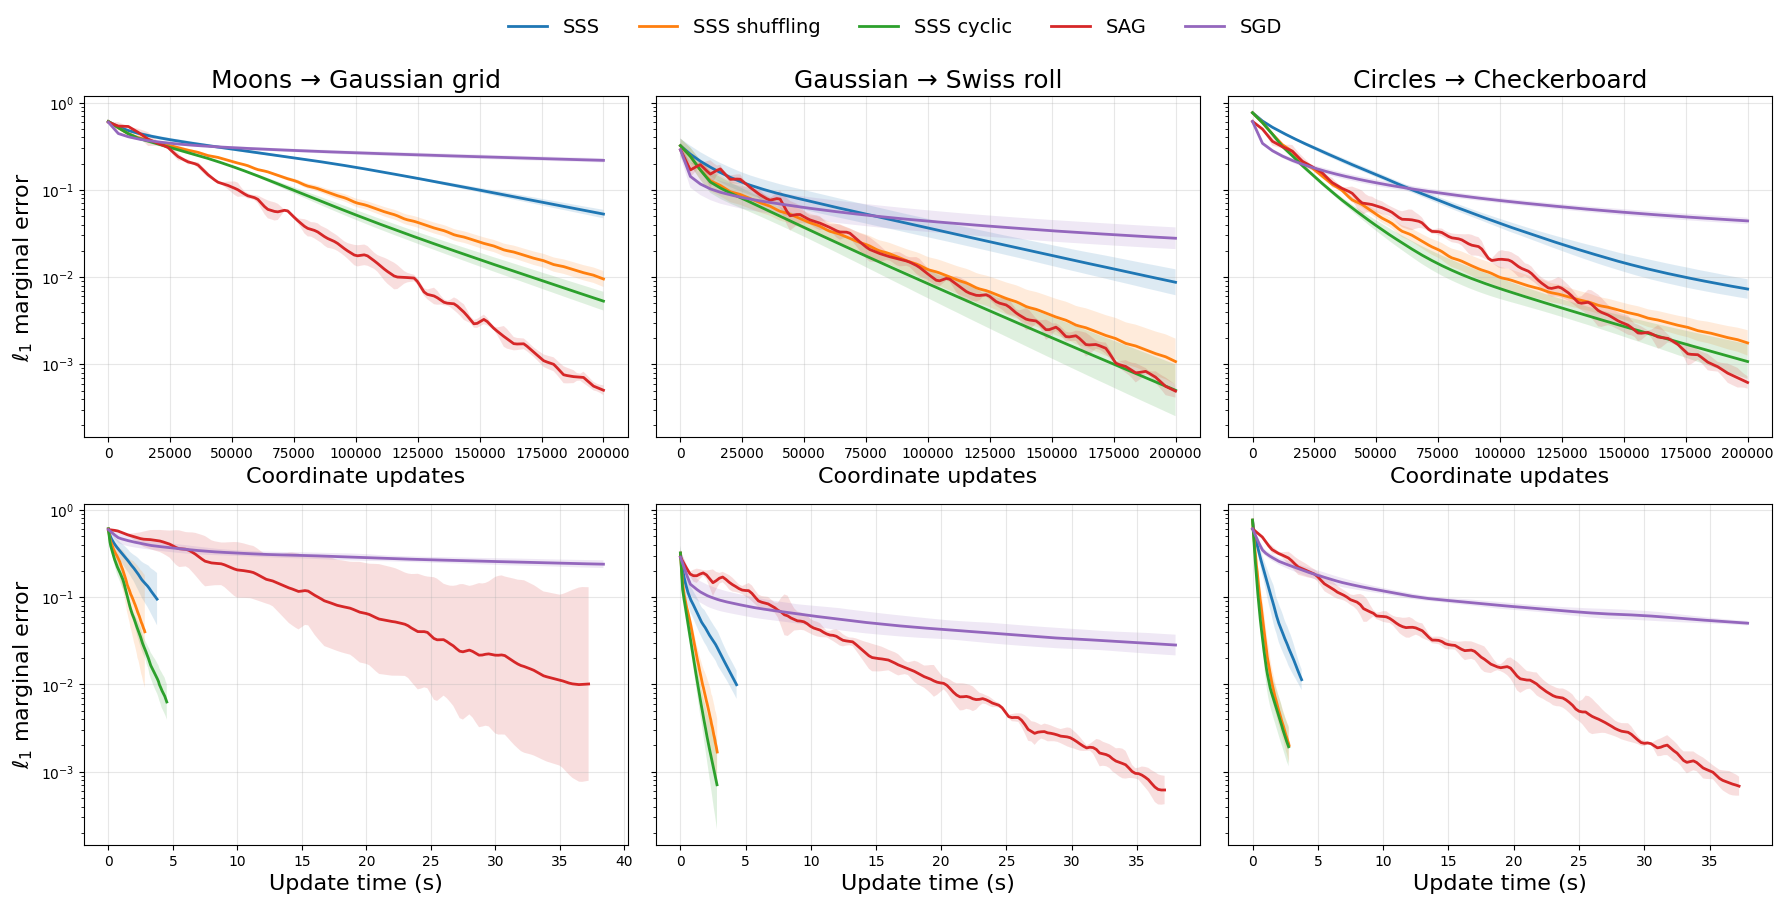

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# plot convergence
# top row: error vs coordinate updates
# bottom row: error vs update time

def plot_semidual_cpu_mean(semidual_cpu_results, datasets, seeds):
    method_labels = {'sss': 'SSS', 'sss_shuffle': 'SSS shuffling',
                     'sss_cyclic': 'SSS cyclic', 'sag': 'SAG', 'sgd': 'SGD'}

    fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
    tiny = np.finfo(float).tiny

    for col, (dataset, dataset_title) in enumerate(datasets.items()):
        ax_updates = axes[0, col]
        ax_time = axes[1, col]

        for method, label in method_labels.items():
            runs = [semidual_cpu_results[dataset][seed]['solvers'][method] for seed in seeds]

            #top row
            max_common_updates = min(np.asarray(run['iteration_history'], dtype=float)[-1]for run in runs)
            min_common_updates = max(np.asarray(run['iteration_history'], dtype=float)[0] for run in runs)

            update_grid = np.linspace(min_common_updates, max_common_updates, 150)

            log_errors_updates = []

            for run in runs:
                updates = np.asarray(run['iteration_history'], dtype=float)
                errors = np.asarray(run['error'], dtype=float)
                errors = np.maximum(errors, tiny)

                unique_updates, unique_idx = np.unique(updates, return_index=True)

                errors = errors[unique_idx]

                interp_log_error = np.interp(update_grid, unique_updates, np.log(errors))

                log_errors_updates.append(interp_log_error)

            log_errors_updates = np.stack(log_errors_updates)

            #geometric mean
            mean_log_error = log_errors_updates.mean(axis=0)

            #std in log space
            std_log_error = log_errors_updates.std(axis=0, ddof=1)

            mean_error = np.exp(mean_log_error)
            lower_error = np.exp(mean_log_error - std_log_error)
            upper_error = np.exp(mean_log_error + std_log_error)

            ax_updates.plot(update_grid,mean_error, linewidth=2, label=label)
            ax_updates.fill_between(update_grid, lower_error, upper_error, alpha=0.15)


            #bottom row
            max_common_time = min(np.asarray(run['update_time_history'],dtype=float)[-1] for run in runs)
            min_common_time = max(np.asarray(run['update_time_history'],dtype=float)[0]for run in runs)

            time_grid = np.linspace(min_common_time, max_common_time, 150)

            log_errors_time = []

            for run in runs:
                times = np.asarray(run['update_time_history'],dtype=float)

                errors = np.asarray(run['error'], dtype=float)
                errors = np.maximum(errors, tiny)
                unique_times, unique_idx = np.unique(times, return_index=True)
                errors = errors[unique_idx]

                interp_log_error = np.interp(time_grid, unique_times, np.log(errors))
                log_errors_time.append(interp_log_error)

            log_errors_time = np.stack(log_errors_time)

            mean_log_error = log_errors_time.mean(axis=0)
            std_log_error = log_errors_time.std( axis=0, ddof=1)

            mean_error_time = np.exp(mean_log_error)
            lower_time = np.exp(mean_log_error - std_log_error)
            upper_time = np.exp(mean_log_error + std_log_error)

            ax_time.plot(time_grid, mean_error_time, linewidth=2, label=label)
            ax_time.fill_between(time_grid, lower_time, upper_time, alpha=0.15)


        ax_updates.set_yscale('log')
        ax_time.set_yscale('log')

        ax_updates.set_title(dataset_title, fontsize=18)
        ax_updates.set_xlabel('Coordinate updates', fontsize=16)
        ax_time.set_xlabel('Update time (s)', fontsize=16)

        ax_updates.grid(True, alpha=0.3)
        ax_time.grid(True, alpha=0.3)

    axes[0, 0].set_ylabel(r'$\ell_1$ marginal error',fontsize=16)

    axes[1, 0].set_ylabel(r'$\ell_1$ marginal error',fontsize=16)

    handles, labels = (axes[0, 0].get_legend_handles_labels())

    fig.legend(handles, labels, loc='upper center', ncol=5,
               bbox_to_anchor=(0.5, 1.01), frameon=False, fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    return fig, axes


fig, axes = plot_semidual_cpu_mean(semidual_cpu_results, datasets_semidual, seeds_semidual)
plt.show()

filename = 'app_CPU_other_solvers_convergence.pdf'
fig.savefig(filename, format='pdf', bbox_inches='tight')
files.download(filename)


In [ ]:
#diagnostic test for SAG
def profile_sag_update(a, b, M, reg, n_test=100000, seed=1337):
    n_source, n_target = M.shape

    lr = 1.0 / np.max(a / reg)

    beta = np.zeros(n_target, dtype=np.float64)
    stored_gradient = np.zeros((n_source, n_target),dtype=np.float64)
    sum_stored_gradient = np.zeros(n_target, dtype=np.float64)

    log_b = np.log(b)
    inv_reg = 1.0 / reg

    rng = np.random.RandomState(seed)
    indices = rng.randint(0, n_source,size=n_test)
    t_gradient = 0.0
    t_stored = 0.0
    t_beta = 0.0

    for i in indices:
        #gradient
        t0 = time.perf_counter()
        logits = (log_b + (beta - M[i, :]) * inv_reg)
        logits -= np.max(logits)

        chi = np.exp(logits)
        chi /= np.sum(chi)

        cur_grad = a[i] * (b - chi)

        t_gradient += time.perf_counter() - t0


        #SAG gradient memory
        t0 = time.perf_counter()
        sum_stored_gradient += (cur_grad -stored_gradient[i])
        stored_gradient[i] = cur_grad
        t_stored += time.perf_counter() - t0

        #beta update
        t0 = time.perf_counter()
        beta += (lr * (1.0 / n_source) * sum_stored_gradient)
        t_beta += time.perf_counter() - t0

    total = t_gradient + t_stored + t_beta

    print(f"Test updates: {n_test:,}")
    print()
    print(
        f"Gradient computation : "
        f"{t_gradient:.3f} s "
        f"({1e6*t_gradient/n_test:.2f} us/update)"
    )
    print(
        f"Gradient storage     : "
        f"{t_stored:.3f} s "
        f"({1e6*t_stored/n_test:.2f} us/update)"
    )
    print(
        f"Beta update          : "
        f"{t_beta:.3f} s "
        f"({1e6*t_beta/n_test:.2f} us/update)"
    )
    print("-" * 50)
    print(
        f"Total                : "
        f"{total:.3f} s "
        f"({1e6*total/n_test:.2f} us/update)"
    )

#diagnostic test for SGD
def profile_sgd_update(a, b, M, reg, n_test=100000, seed=1337):
    n_source, n_target = M.shape
    lr = 1.0 / np.max(a / reg)
    beta = np.zeros(n_target, dtype=np.float64)
    ave_beta = np.zeros(n_target, dtype=np.float64)

    log_b = np.log(b)
    inv_reg = 1.0 / reg

    rng = np.random.RandomState(seed)
    indices = rng.randint(0, n_source, size=n_test)

    t_gradient = 0.0
    t_beta = 0.0
    t_average = 0.0

    for cur_iter, i in enumerate(indices):
        k = cur_iter + 1

        #gradient
        t0 = time.perf_counter()

        logits = (log_b + (beta - M[i, :]) * inv_reg)
        logits -= np.max(logits)

        chi = np.exp(logits)
        chi /= np.sum(chi)

        cur_grad = b - chi

        t_gradient += time.perf_counter() - t0


        #SGD update
        t0 = time.perf_counter()
        beta += (lr * (1.0 / n_source) / np.sqrt(k)) * cur_grad
        t_beta += time.perf_counter() - t0

        #averaging
        t0 = time.perf_counter()
        ave_beta += (beta - ave_beta) / k
        t_average += time.perf_counter() - t0

    total = (t_gradient + t_beta +t_average)

    print(f"Test updates: {n_test:,}")
    print()
    print(
        f"Gradient computation : "
        f"{1e6*t_gradient/n_test:.2f} us/update"
    )
    print(
        f"Beta update          : "
        f"{1e6*t_beta/n_test:.2f} us/update"
    )
    print(
        f"Averaging            : "
        f"{1e6*t_average/n_test:.2f} us/update"
    )
    print("-" * 50)
    print(
        f"Total                : "
        f"{1e6*total/n_test:.2f} us/update"
    )

dataset = 'moons_gaussian_grid'
seed = 1337

sources, targets = generate_2d_pairs(dataset=dataset, num_pairs=1, m=m_semidual,
                                     n=n_semidual, seed=seed)

source = sources[0]
target = targets[0]

C = ot.dist(source, target, metric='sqeuclidean')
C = C / C.max()

a = np.ones(len(source)) / len(source)
b = np.ones(len(target)) / len(target)

M_sd = C.T
a_sd = b.copy()
b_sd = a.copy()

profile_sag_update(a=a_sd, b=b_sd, M=M_sd, reg=reg_semidual, n_test=100000)
profile_sgd_update(a=a_sd, b=b_sd, M=M_sd, reg=reg_semidual, n_test=100000)

Test updates: 100,000

Gradient computation : 1.841 s (18.41 us/update)
Gradient storage     : 0.275 s (2.75 us/update)
Beta update          : 0.233 s (2.33 us/update)
--------------------------------------------------
Total                : 2.349 s (23.49 us/update)
Test updates: 100,000

Gradient computation : 19.44 us/update
Beta update          : 5.01 us/update
Averaging            : 3.69 us/update
--------------------------------------------------
Total                : 28.15 us/update


### GPU

#### Functions

In [ ]:
#run Minibatch SSS > Prelims > Functions to get SSS_GPU_until_error

@torch.no_grad()
def semidual_cost_block_GPU(X, Y_block):

    X2 = torch.sum(X * X, dim=1).unsqueeze(0)
    Y2 = torch.sum(Y_block * Y_block, dim=1, keepdim=True)

    C_block = Y2 + X2 - 2.0 * (Y_block @ X.T)
    C_block.clamp_min_(0.0)

    return C_block


#semi-dual helper for GPU implementations
@torch.no_grad()
def semi_dual_marginal_error_GPU(X, Y, beta, reg, batch_size):
    m, n = X.shape[0], Y.shape[0]
    target_mass = 1.0 / m

    marginal_X = torch.zeros(m, device=X.device, dtype=X.dtype)

    for start in range(0, n, batch_size):

        end = min(start + batch_size, n)
        C_block = semidual_cost_block_GPU(X, Y[start:end])

        logits = (beta.unsqueeze(0) - C_block) / reg
        chi = torch.softmax(logits, dim=1)

        marginal_X += chi.sum(dim=0) / n

    error = torch.sum(torch.abs(marginal_X - target_mass))

    return float(error.item())


#GPU SGD
@torch.no_grad()
def SGD_GPU_until_error(X, Y, reg, batch_size, threshold=1e-2, max_epochs=50,
                        seed=1337, step_size=None, average=True,
                        error_batch_size=8192, verbose=False):

    m, n = X.shape[0], Y.shape[0]
    num_blocks = math.ceil(n / batch_size)
    target_mass = 1.0 / m

    if step_size is None:
        step_size = reg

    beta = torch.zeros(m, device=X.device, dtype=X.dtype)
    ave_beta = beta.clone()

    generator = torch.Generator(device='cpu')
    generator.manual_seed(seed)

    total_time, block_updates = 0.0, 0
    history = []

    initial_error = semi_dual_marginal_error_GPU(X, Y, ave_beta, reg, error_batch_size)

    if initial_error <= threshold:
        return {'beta': ave_beta, 'raw_beta': beta, 'reached_threshold': True,
                'time_to_threshold': 0.0, 'final_error': initial_error,
                'total_time': 0.0, 'block_updates': 0,
                'avg_block_time': np.nan, 'history': []}

    for epoch in range(1, max_epochs + 1):
        block_order = torch.randint(0, num_blocks, (num_blocks,), generator=generator).tolist()

        torch.cuda.synchronize()
        t0 = time.perf_counter()

        for block_id in block_order:
            start = block_id * batch_size
            end = min(start + batch_size, n)
            q = end - start

            C_block = semidual_cost_block_GPU(X, Y[start:end])
            logits = (beta.unsqueeze(0) - C_block) / reg
            chi = torch.softmax(logits, dim=1)

            grad = target_mass - chi.mean(dim=0)
            correction = num_blocks * q / n
            grad.mul_(correction)

            block_updates += 1
            lr_t = step_size / math.sqrt(block_updates)

            beta.add_(grad, alpha=lr_t)

            if average:
                ave_beta.add_(beta - ave_beta, alpha=1.0 / block_updates)

        torch.cuda.synchronize()
        total_time += time.perf_counter() - t0

        beta_eval = ave_beta if average else beta

        #excluded from timing
        error = semi_dual_marginal_error_GPU(X, Y, beta_eval, reg, error_batch_size)

        history.append({'epoch': epoch, 'kernel_passes': epoch, 'time': total_time,
                        'error': error})

        if verbose:
            print(f"SGD | epoch {epoch:3d} | time {total_time:.3f}s | "
                  f"error {error:.3e}")

        if error <= threshold:
            break

    beta_eval = ave_beta if average else beta
    reached = history[-1]['error'] <= threshold

    return {'beta': beta_eval, 'raw_beta': beta, 'reached_threshold': reached,
            'time_to_threshold': total_time if reached else np.nan,
            'final_error': history[-1]['error'], 'total_time': total_time,
            'block_updates': block_updates, 'avg_block_time': total_time / block_updates,
            'history': history}


#GPU SAG
@torch.no_grad()
def SAG_GPU_until_error(X, Y, reg, batch_size, threshold=1e-2, max_epochs=50,
                        seed=1337, step_size=None, error_batch_size=8192,
                        verbose=False):

    m, n = X.shape[0], Y.shape[0]
    num_blocks = math.ceil(n / batch_size)
    target_mass = 1.0 / m

    if step_size is None:
        step_size = reg

    beta = torch.zeros(m, device=X.device, dtype=X.dtype)

    stored_gradient = torch.zeros((num_blocks, m), device=X.device, dtype=X.dtype)
    sum_stored_gradient = torch.zeros(m, device=X.device, dtype=X.dtype)

    generator = torch.Generator(device='cpu')
    generator.manual_seed(seed)

    total_time, block_updates = 0.0, 0
    history = []

    initial_error = semi_dual_marginal_error_GPU(X, Y, beta, reg, error_batch_size)

    if initial_error <= threshold:
        return {'beta': beta, 'reached_threshold': True, 'time_to_threshold': 0.0,
                'final_error': initial_error,'total_time': 0.0, 'block_updates': 0,
                'avg_block_time': np.nan, 'history': []}

    for epoch in range(1, max_epochs + 1):
        block_order = torch.randint(0, num_blocks, (num_blocks,), generator=generator).tolist()

        torch.cuda.synchronize()
        t0 = time.perf_counter()

        for block_id in block_order:

            start = block_id * batch_size
            end = min(start + batch_size, n)
            q = end - start

            C_block = semidual_cost_block_GPU(X, Y[start:end])
            logits = (beta.unsqueeze(0) - C_block) / reg
            chi = torch.softmax(logits, dim=1)

            block_grad = target_mass - chi.mean(dim=0)
            new_contribution = (q / n) * block_grad

            old_contribution = stored_gradient[block_id].clone()
            sum_stored_gradient += new_contribution - old_contribution
            stored_gradient[block_id].copy_(new_contribution)

            beta.add_(sum_stored_gradient, alpha=step_size)
            block_updates += 1

        torch.cuda.synchronize()
        total_time += time.perf_counter() - t0

        #excluded from timing
        error = semi_dual_marginal_error_GPU(X, Y, beta, reg, error_batch_size)

        history.append({'epoch': epoch, 'kernel_passes': epoch,'time': total_time, 'error': error})

        if verbose:
            print(f"SAG | epoch {epoch:3d} | time {total_time:.3f}s | "
                  f"error {error:.3e}")

        if error <= threshold:
            break

    reached = history[-1]['error'] <= threshold

    return {'beta': beta, 'reached_threshold': reached, 'time_to_threshold': total_time if reached else np.nan,
            'final_error': history[-1]['error'], 'total_time': total_time, 'block_updates': block_updates,
            'avg_block_time': total_time / block_updates,'history': history}

#wrapper function
def run_GPU_time_to_threshold_all_methods(
        dataset_specs, m, n, reg, batch_size, threshold=1e-2, num_runs=3,
        run_seeds=(1337, 1338, 1339), max_epochs=50, error_batch_size=8192,
        sgd_step_size=None, sag_step_size=None, verbose=False):

    all_rows = []

    for dataset_name, spec in dataset_specs.items():

        print('\n' + '=' * 80)
        print('DATASET:', dataset_name)
        print('=' * 80)

        #generate dataset once
        X, Y = spec['generator'](m=m, n=n, device=device, dtype=dtype, seed=spec['seed'])

        #common SSS / Sinkhorn initialization
        u0, v0, Kv0 = initialize_scalings_GPU(X, Y, reg=reg, batch_size=batch_size)

        def transport_error(u, v):
            return marginal_error_GPU(X, Y, u, v, reg=reg, batch_size=error_batch_size)

        #GPU warmup
        K_warm = kernel_block(X, Y[:batch_size], reg)
        _ = K_warm.T @ u0
        torch.cuda.synchronize()

        del K_warm
        gc.collect()
        torch.cuda.empty_cache()

        for run_idx in range(num_runs):
            run_seed = run_seeds[run_idx]
            print(f"\nRun {run_idx + 1}/{num_runs} | seed={run_seed}")

            #SSS variants
            sss_methods = {'SSS random': 'random', 'SSS shuffling': 'shuffle',
                           'SSS cyclic': 'cyclic'}

            for method_name, sampling in sss_methods.items():

                gc.collect()
                torch.cuda.empty_cache()

                result = SSS_GPU_until_error(X, Y, u0, v0, Kv0, reg, batch_size,
                                             transport_error, threshold=threshold,
                                             max_epochs=max_epochs, seed=run_seed,
                                             sampling=sampling, verbose=verbose)

                passes = (result['history'][-1]['kernel_passes'] if len(result['history']) > 0 else 0)

                all_rows.append({'Dataset': dataset_name, 'Method': method_name,
                                 'Run': run_idx + 1, 'Seed': run_seed,
                                 'Reached threshold': result['reached_threshold'],
                                 'Time to threshold (s)': result['time_to_threshold'],
                                 'Final error': result['final_error'],
                                 'Equivalent passes': passes,
                                 'Block updates': result['block_updates'],
                                 'Avg block time (ms)': 1000.0 * result['avg_block_time']})

                print(
                    f"{method_name:15s} | reached={result['reached_threshold']} | "
                    f"time={result['time_to_threshold']} | "
                    f"error={result['final_error']:.3e} | passes={passes}"
                )

                del result

            #Sinkhorn
            gc.collect()
            torch.cuda.empty_cache()

            result = sinkhorn_GPU_until_error(X=X, Y=Y, u_init=u0, v_init=v0, reg=reg,
                                              batch_size=batch_size, error_fn=transport_error,
                                              threshold=threshold, max_iterations=max_epochs)

            passes = (result['history'][-1]['kernel_passes'] if len(result['history']) > 0 else 0)

            all_rows.append({'Dataset': dataset_name, 'Method': 'Sinkhorn',
                             'Run': run_idx + 1, 'Seed': np.nan,
                             'Reached threshold': result['reached_threshold'],
                             'Time to threshold (s)': result['time_to_threshold'],
                             'Final error': result['final_error'],
                             'Equivalent passes': passes,
                             'Block updates': result['block_updates'],
                             'Avg block time (ms)': 1000.0 * result['avg_block_time']})

            print(
                f"{'Sinkhorn':15s} | reached={result['reached_threshold']} | "
                f"time={result['time_to_threshold']} | "
                f"error={result['final_error']:.3e} | passes={passes}"
            )

            del result

            #SAG
            gc.collect()
            torch.cuda.empty_cache()

            result = SAG_GPU_until_error(X, Y, reg, batch_size, threshold=threshold,
                                         max_epochs=max_epochs, seed=run_seed,
                                         step_size=sag_step_size, error_batch_size=error_batch_size,
                                         verbose=verbose)

            passes = (result['history'][-1]['kernel_passes'] if len(result['history']) > 0 else 0)

            all_rows.append({'Dataset': dataset_name, 'Method': 'SAG',
                             'Run': run_idx + 1, 'Seed': run_seed,
                             'Reached threshold': result['reached_threshold'],
                             'Time to threshold (s)': result['time_to_threshold'],
                             'Final error': result['final_error'],
                             'Equivalent passes': passes,
                             'Block updates': result['block_updates'],
                             'Avg block time (ms)': 1000.0 * result['avg_block_time']})

            print(
                f"{'SAG':15s} | reached={result['reached_threshold']} | "
                f"time={result['time_to_threshold']} | "
                f"error={result['final_error']:.3e} | passes={passes}"
            )

            del result


            # #SGD
            # gc.collect()
            # torch.cuda.empty_cache()

            # result = SGD_GPU_until_error(X, Y, reg, batch_size, threshold=threshold,
            #                              max_epochs=max_epochs, seed=run_seed,
            #                              step_size=sgd_step_size, average=False,
            #                              error_batch_size=error_batch_size, verbose=verbose)

            # passes = (result['history'][-1]['kernel_passes'] if len(result['history']) > 0 else 0)

            # all_rows.append({'Dataset': dataset_name, 'Method': 'SGD',
            #                  'Run': run_idx + 1, 'Seed': run_seed,
            #                  'Reached threshold': result['reached_threshold'],
            #                  'Time to threshold (s)': result['time_to_threshold'],
            #                  'Final error': result['final_error'],
            #                  'Equivalent passes': passes,
            #                  'Block updates': result['block_updates'],
            #                  'Avg block time (ms)': 1000.0 * result['avg_block_time']})

            # print(
            #     f"{'SGD':15s} | reached={result['reached_threshold']} | "
            #     f"time={result['time_to_threshold']} | "
            #     f"error={result['final_error']:.3e} | passes={passes}"
            # )

            # del result


            gc.collect()
            torch.cuda.empty_cache()

        del X, Y, u0, v0, Kv0

        gc.collect()
        torch.cuda.empty_cache()

    return pd.DataFrame(all_rows)


def benchmark_semidual_solver(solver_fn, X, Y, reg, batch_size, num_epochs,
                              seed=1337, step_size=None, average=None):

    device = X.device

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)

    baseline_memory = torch.cuda.memory_allocated(device)

    kwargs = {'X': X, 'Y': Y, 'reg': reg, 'batch_size': batch_size,
              'num_epochs': num_epochs, 'seed': seed, 'step_size': step_size,
              'record_error': False}

    if average is not None:
        kwargs['average'] = average

    result = solver_fn(**kwargs)

    beta = result['beta']

    # Error evaluation is outside solver timing
    error = semi_dual_marginal_error_GPU(X, Y, beta, reg, batch_size)

    peak_memory = torch.cuda.max_memory_allocated(device)
    working_memory_gib = (peak_memory - baseline_memory) / 1024**3

    return {'error': error, 'time': result['update_time'],
            'working_memory_gib': working_memory_gib, 'num_updates': result['num_updates'],
            'beta': beta}

#### Experiment

In [ ]:
device = 'cuda'
dtype = torch.float32

m = 1024
n = 4_500_000

reg = 0.1
batch_size = 8192
threshold = 1e-2

num_runs = 3
run_seeds = [1337, 1338, 1339]

max_epochs = 50
error_batch_size = 8192

dataset_specs = {'8 Gaussians -> Noisy Ring': {'generator': make_large_ot_problem,
                                               'seed': 1337},
                 '4 Gaussians -> Rotated 4 Gaussians': {'generator': make_gaussian_to_rotated_gaussian,
                                                        'seed': 1984},
                 'Uniform Disk -> Two Rings': {'generator': make_disk_to_two_rings, 'seed': 451}}

In [ ]:
gpu_threshold_df = run_GPU_time_to_threshold_all_methods(dataset_specs, m, n, reg, batch_size,
                                                         threshold=threshold, num_runs=3,
                                                         run_seeds=[1337, 1338, 1339],
                                                         max_epochs=50, error_batch_size=8192)

gpu_threshold_df


DATASET: 8 Gaussians -> Noisy Ring

Run 1/3 | seed=1337
SSS random      | reached=True | time=20.311394050000445 | error=9.429e-03 | passes=17
SSS shuffling   | reached=True | time=11.936948518000008 | error=9.046e-03 | passes=10
SSS cyclic      | reached=True | time=10.745459677999861 | error=8.658e-03 | passes=9
Sinkhorn | iter  1 | time 2.23s | error 4.258e-02
Sinkhorn | iter  2 | time 4.46s | error 3.491e-02
Sinkhorn | iter  3 | time 6.69s | error 3.112e-02
Sinkhorn | iter  4 | time 8.93s | error 2.810e-02
Sinkhorn | iter  5 | time 11.16s | error 2.556e-02
Sinkhorn | iter  6 | time 13.39s | error 2.333e-02
Sinkhorn | iter  7 | time 15.62s | error 2.134e-02
Sinkhorn | iter  8 | time 17.85s | error 1.954e-02
Sinkhorn | iter  9 | time 20.08s | error 1.790e-02
Sinkhorn | iter 10 | time 22.32s | error 1.641e-02
Sinkhorn | iter 11 | time 24.55s | error 1.504e-02
Sinkhorn | iter 12 | time 26.78s | error 1.379e-02
Sinkhorn | iter 13 | time 29.01s | error 1.265e-02
Sinkhorn | iter 14 | tim

,Dataset,Method,Run,Seed,Reached threshold,Time to threshold (s),Final error,Equivalent passes,Block updates,Avg block time (ms)
0,8 Gaussians -> Noisy Ring,SSS random,1,1337.0,True,20.311394,0.009429,17,9350,2.172342
1,8 Gaussians -> Noisy Ring,SSS shuffling,1,1337.0,True,11.936949,0.009046,10,5500,2.170354
2,8 Gaussians -> Noisy Ring,SSS cyclic,1,1337.0,True,10.745460,0.008658,9,4950,2.170800
3,8 Gaussians -> Noisy Ring,Sinkhorn,1,NaN,True,35.705057,0.009757,32,17600,2.028696
4,8 Gaussians -> Noisy Ring,SAG,1,1337.0,True,38.786187,0.009639,30,16500,2.350678
5,8 Gaussians -> Noisy Ring,SSS random,2,1338.0,True,20.304434,0.009640,17,9350,2.171597
6,8 Gaussians -> Noisy Ring,SSS shuffling,2,1338.0,True,11.966045,0.009062,10,5500,2.175645
7,8 Gaussians -> Noisy Ring,SSS cyclic,2,1338.0,True,10.758124,0.008658,9,4950,2.173358
8,8 Gaussians -> Noisy Ring,Sinkhorn,2,NaN,True,35.714082,0.009757,32,17600,2.029209
9,8 Gaussians -> Noisy Ring,SAG,2,1338.0,True,38.854947,0.009667,30,16500,2.354845


In [ ]:
def summarize_GPU_threshold_results(df):

    rows = []

    for (dataset, method), group in df.groupby(['Dataset', 'Method']):

        successful = group[group['Reached threshold']]
        n_success, n_total = len(successful), len(group)

        if n_success > 0:
            mean_time = successful['Time to threshold (s)'].mean()
            mean_error = successful['Final error'].mean()
            mean_passes = successful['Equivalent passes'].mean()
        else:
            mean_time = np.nan
            mean_error = group['Final error'].mean()
            mean_passes = np.nan

        if n_success > 1:
            std_time = successful['Time to threshold (s)'].std(ddof=1)
            std_error = successful['Final error'].std(ddof=1)
            std_passes = successful['Equivalent passes'].std(ddof=1)
        else:
            std_time = np.nan
            std_error = np.nan
            std_passes = np.nan

        rows.append({'Dataset': dataset, 'Method': method, 'Success': f'{n_success}/{n_total}',
                     'mean_time': mean_time, 'std_time': std_time, 'mean_error': mean_error,
                     'std_error': std_error, 'mean_passes': mean_passes, 'std_passes': std_passes})

    return pd.DataFrame(rows)

gpu_threshold_summary = summarize_GPU_threshold_results(gpu_threshold_df)
gpu_threshold_summary

,Dataset,Method,Success,mean_time,std_time,mean_error,std_error,mean_passes,std_passes
0,4 Gaussians -> Rotated 4 Gaussians,SAG,3/3,9.471155,0.747883,0.008057,1.364826e-03,7.333333,0.57735
1,4 Gaussians -> Rotated 4 Gaussians,SSS cyclic,3/3,2.387460,0.000215,0.005610,2.632773e-05,2.000000,0.00000
2,4 Gaussians -> Rotated 4 Gaussians,SSS random,3/3,6.365812,0.687729,0.006673,1.098681e-03,5.333333,0.57735
3,4 Gaussians -> Rotated 4 Gaussians,SSS shuffling,3/3,2.387308,0.000228,0.006119,9.520213e-06,2.000000,0.00000
4,4 Gaussians -> Rotated 4 Gaussians,Sinkhorn,3/3,4.460740,0.000456,0.009737,0.000000e+00,4.000000,0.00000
5,8 Gaussians -> Noisy Ring,SAG,3/3,38.803057,0.045845,0.009662,2.020018e-05,30.000000,0.00000
6,8 Gaussians -> Noisy Ring,SSS cyclic,3/3,10.791422,0.068933,0.008658,5.453085e-07,9.000000,0.00000
7,8 Gaussians -> Noisy Ring,SSS random,3/3,20.307828,0.003483,0.009529,1.059113e-04,17.000000,0.00000
8,8 Gaussians -> Noisy Ring,SSS shuffling,3/3,11.948507,0.015442,0.009053,8.123410e-06,10.000000,0.00000
9,8 Gaussians -> Noisy Ring,Sinkhorn,3/3,35.707881,0.005378,0.009757,0.000000e+00,32.000000,0.00000


In [ ]:
#get results from first 10 kernel passes

#wrapper for semi-dual methods
def benchmark_semidual_until_error(solver_fn, X, Y, reg, batch_size, num_epochs,
                                   seed=1337, step_size=None, average=None):

    device = X.device

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)

    baseline_memory = torch.cuda.memory_allocated(device)

    kwargs = {'X': X, 'Y': Y, 'reg': reg, 'batch_size': batch_size, 'threshold': -1.0,
              'max_epochs': num_epochs, 'seed': seed, 'step_size': step_size,
              'error_batch_size': batch_size, 'verbose': False}

    if average is not None:
        kwargs['average'] = average

    result = solver_fn(**kwargs)

    torch.cuda.synchronize()

    peak_memory = torch.cuda.max_memory_allocated(device)
    working_memory_gib = (peak_memory - baseline_memory) / 1024**3

    return {'error': result['final_error'], 'time': result['total_time'],
            'working_memory_gib': working_memory_gib, 'result': result}

#run sweep experiment (similar to what we did above)
kernel_passes = [2, 4, 6, 8, 10]

sweep_results = []

for passes in kernel_passes:

    sinkhorn_iterations = passes // 2
    sss_epochs = passes
    sgd_epochs = passes
    sag_epochs = passes

    print(f"\n{'=' * 20} {passes} kernel passes {'=' * 20}")


    #Sinkhorn
    sinkhorn_result = benchmark_solver(solver_fn=sinkhorn_GPU, error_fn=compute_error,
                                       X=X, Y=Y, u_init=u0, v_init=v0, reg=reg,
                                       batch_size=batch_size, num_iterations=sinkhorn_iterations)

    print(f"Sinkhorn ({sinkhorn_iterations} iterations)")
    print("Error:", sinkhorn_result['error'])
    print("Time :", sinkhorn_result['time'])


    #SSS
    sss_random_result = benchmark_solver(solver_fn=SSS_GPU, error_fn=compute_error,
                                         X=X, Y=Y, u_init=u0, v_init=v0, Kv_init=Kv0, reg=reg,
                                         batch_size=batch_size, num_epochs=sss_epochs,
                                         seed=seed, sampling='random')

    print(f"\nSSS random ({sss_epochs} equivalent passes)")
    print("Error:", sss_random_result['error'])
    print("Time :", sss_random_result['time'])

    #SSS shuffling
    sss_shuffle_result = benchmark_solver(solver_fn=SSS_GPU, error_fn=compute_error,
                                          X=X, Y=Y, u_init=u0, v_init=v0, Kv_init=Kv0, reg=reg,
                                          batch_size=batch_size, num_epochs=sss_epochs,
                                          seed=seed, sampling='shuffle')

    print(f"\nSSS shuffling ({sss_epochs} passes)")
    print("Error:", sss_shuffle_result['error'])
    print("Time :", sss_shuffle_result['time'])


    #SSS cyclic
    sss_cyclic_result = benchmark_solver(solver_fn=SSS_GPU, error_fn=compute_error,
                                         X=X, Y=Y, u_init=u0, v_init=v0, Kv_init=Kv0, reg=reg,
                                         batch_size=batch_size, num_epochs=sss_epochs,
                                         seed=seed, sampling='cyclic')

    print(f"\nSSS cyclic ({sss_epochs} passes)")
    print("Error:", sss_cyclic_result['error'])
    print("Time :", sss_cyclic_result['time'])

    #SGD
    sgd_result = benchmark_semidual_until_error(solver_fn=SGD_GPU_until_error,
                                                X=X, Y=Y, reg=reg,batch_size=batch_size,
                                                num_epochs=sgd_epochs, seed=seed,
                                                step_size=None, average=True)

    print("\nSGD")
    print("Error:", sgd_result['error'])
    print("Time :", sgd_result['time'])


    #SAG
    sag_result = benchmark_semidual_until_error(solver_fn=SAG_GPU_until_error, X=X,
                                                Y=Y, reg=reg, batch_size=batch_size,
                                                num_epochs=sag_epochs, seed=seed,
                                                step_size=None)

    print("\nSAG")
    print("Error:", sag_result['error'])
    print("Time :", sag_result['time'])

    sweep_results.append({'kernel_passes': passes,'sinkhorn_iterations': sinkhorn_iterations,
                          'sinkhorn_error': sinkhorn_result['error'],
                          'sinkhorn_time': sinkhorn_result['time'],
                          'sinkhorn_memory': sinkhorn_result['working_memory_gib'],
                          'sss_random_epochs': sss_epochs,
                          'sss_random_error': sss_random_result['error'],
                          'sss_random_time': sss_random_result['time'],
                          'sss_random_memory': sss_random_result['working_memory_gib'],
                          'sss_shuffle_epochs': sss_epochs,
                          'sss_shuffle_error': sss_shuffle_result['error'],
                          'sss_shuffle_time': sss_shuffle_result['time'],
                          'sss_shuffle_memory': sss_shuffle_result['working_memory_gib'],
                          'sss_cyclic_epochs': sss_epochs,
                          'sss_cyclic_error': sss_cyclic_result['error'],
                          'sss_cyclic_time': sss_cyclic_result['time'],
                          'sss_cyclic_memory': sss_cyclic_result['working_memory_gib'],
                          'sgd_epochs': sgd_epochs,
                          'sgd_error': sgd_result['error'],
                          'sgd_time': sgd_result['time'],
                          'sgd_memory': sgd_result['working_memory_gib'],
                          'sag_epochs': sag_epochs,
                          'sag_error': sag_result['error'],
                          'sag_time': sag_result['time'],
                          'sag_memory': sag_result['working_memory_gib'],
                          })


==================== 2 kernel passes ====================
Sinkhorn (1 iterations)
Error: 0.04258343577384949
Time : 2.283415077000001

SSS random (2 equivalent passes)
Error: 0.062304433435201645
Time : 2.401266820000018

SSS shuffling (2 passes)
Error: 0.03010772541165352
Time : 2.3964249429999995

SSS cyclic (2 passes)
Error: 0.02940765954554081
Time : 2.3972226420000027

SGD
Error: 0.2597384750843048
Time : 2.631668431999998

SAG
Error: 0.13995051383972168
Time : 2.5915334750000056

==================== 4 kernel passes ====================
Sinkhorn (2 iterations)
Error: 0.034907642751932144
Time : 4.470336913000011

SSS random (4 equivalent passes)
Error: 0.030421286821365356
Time : 4.776514466999998

SSS shuffling (4 passes)
Error: 0.02184220403432846
Time : 4.775802174000006

SSS cyclic (4 passes)
Error: 0.020365653559565544
Time : 4.77403249599999

SGD
Error: 0.25550761818885803
Time : 5.1549270239999885

SAG
Error: 0.042164146900177
Time : 5.187179175000011

===================

In [ ]:
sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_markdown(index=False))

|   kernel_passes |   sinkhorn_iterations |   sinkhorn_error |   sinkhorn_time |   sinkhorn_memory |   sss_random_epochs |   sss_random_error |   sss_random_time |   sss_random_memory |   sss_shuffle_epochs |   sss_shuffle_error |   sss_shuffle_time |   sss_shuffle_memory |   sss_cyclic_epochs |   sss_cyclic_error |   sss_cyclic_time |   sss_cyclic_memory |   sgd_epochs |   sgd_error |   sgd_time |   sgd_memory |   sag_epochs |   sag_error |   sag_time |   sag_memory |
|----------------:|----------------------:|-----------------:|----------------:|------------------:|--------------------:|-------------------:|------------------:|--------------------:|---------------------:|--------------------:|-------------------:|---------------------:|--------------------:|-------------------:|------------------:|--------------------:|-------------:|------------:|-----------:|-------------:|-------------:|------------:|-----------:|-------------:|
|               2 |                     1 |        0

In [ ]:
error_sweep_df = sweep_df[['kernel_passes', 'sinkhorn_error', 'sss_random_error',
                           'sss_shuffle_error','sss_cyclic_error','sgd_error',
                           'sag_error']]

error_sweep_df

,kernel_passes,sinkhorn_error,sss_random_error,sss_shuffle_error,sss_cyclic_error,sgd_error,sag_error
0,2,0.042583,0.062304,0.030108,0.029408,0.259738,0.139951
1,4,0.034908,0.030421,0.021842,0.020366,0.255508,0.042164
2,6,0.031116,0.024240,0.016215,0.014433,0.252317,0.033568
3,8,0.028101,0.020039,0.012090,0.010264,0.249664,0.028425
4,10,0.025556,0.016790,0.009046,0.007305,0.247356,0.024928


In [ ]:
time_sweep_df = sweep_df[['kernel_passes', 'sinkhorn_time', 'sss_random_time',
                          'sss_shuffle_time', 'sss_cyclic_time', 'sgd_time',
                          'sag_time']]

time_sweep_df

,kernel_passes,sinkhorn_time,sss_random_time,sss_shuffle_time,sss_cyclic_time,sgd_time,sag_time
0,2,2.239658,2.390037,2.391275,2.390378,2.582112,2.585499
1,4,4.466346,4.781150,4.781899,4.782534,5.173167,5.180701
2,6,6.705824,7.172670,7.298780,7.398626,7.741268,7.761685
3,8,8.941301,9.564938,9.560295,9.560615,10.333654,10.362052
4,10,11.177023,11.954795,11.952407,11.950833,12.905965,12.933149
